# Analisis Klaster dan Spasial Kesenjangan Akses Digital Antarprovinsi
### NSIC EPSILON 2026 — IRIS Tempu

**Unit analisis:** 38 provinsi · **Tahun acuan:** 2024 · **Keluaran peta:** SVG vektor

| Peran | Variabel | Satuan | Sumber |
|---|---|---|---|
| Y | `hp_seluler_2024` — kepemilikan/penguasaan telepon seluler | persen | BPS, Susenas |
| X1 | `rls_2024` — rata-rata lama sekolah | tahun | BPS |
| X2 | `ipm_2024` — Indeks Pembangunan Manusia | indeks | BPS |
| X3 | `pdrb_kapita_2024` — PDRB per kapita ADHB | ribu rupiah | BPS |
| X4 | `tpt_2024` — Tingkat Pengangguran Terbuka (Agustus) | persen | BPS, Sakernas |

Klasterisasi memperlakukan kelima variabel setara. Regresi spasial memakai Y dan empat X.

**Berkas pendamping:** `dataset_jala_38prov.csv`, folder `shp/` berisi `indonesia_38prov.geojson`
(38 provinsi termasuk pemekaran Papua, geometri divalidasi, CRS EPSG:4326, sumber:
Badan Informasi Geospasial via repositori GeoJSON 38-provinsi).

## 0. Persiapan

In [1]:
# Jalankan sekali bila belum terpasang
# !pip install geopandas mapclassify libpysal esda spreg mgwr statsmodels -q

In [2]:
import warnings, os, numpy as np, pandas as pd, geopandas as gpd
import matplotlib as mpl, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
import mapclassify
from scipy import stats
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   QuantileTransformer, PowerTransformer)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 300, 'font.size': 10, 'axes.titleweight': 'bold',
                     'svg.fonttype': 'none'})   # teks SVG tetap sebagai teks, bukan kurva
pd.set_option('display.width', 150, 'display.max_columns', 40)
os.makedirs('output_svg', exist_ok=True)
print('Siap.')

Siap.


## 1. Data dan Peta Dasar

**Kompatibilitas sumber peta.** Sel ini menerima beberapa sumber, dicoba berurutan:
GeoJSON 38-provinsi bawaan (resolusi penuh, direkomendasikan), shapefile 38-provinsi bawaan,
atau **GADM 4.1 level-1** (`gadm41_IDN_1.shp`) yang lazim dipakai untuk tugas kuliah spasial.

GADM 4.1 hanya memuat **34 provinsi** — empat provinsi hasil pemekaran Papua
(Papua Selatan, Papua Tengah, Papua Pegunungan, Papua Barat Daya) belum ada di batasnya.
Bila GADM terdeteksi, provinsi-provinsi itu otomatis digabungkan kembali ke batas lama
(Papua / Papua Barat) **khusus untuk keperluan pemetaan** — seluruh analisis statistik
(klaster, indeks, regresi spasial) tetap memakai resolusi penuh 38 provinsi tanpa penggabungan.

Untuk berkas ini dipakai `shp/indonesia_38prov.geojson` — 38 provinsi resolusi penuh,
sehingga jalur GADM di bawah ini murni sebagai jaring pengaman (tidak terpakai kecuali
berkas 38-provinsi tidak ditemukan).

In [3]:
df = pd.read_csv("C:/Uner/Lomba/Dataquest/2026/Penyisihan/Analisis Clustering dan Spasial/dataset_jala_38prov.csv")
if {'lat','lon'} <= set(df.columns):
    df = df.drop(columns=['lat','lon'])

# --------------------------------------------------------------------------
# Pemuatan peta yang fleksibel dan tahan banting.
# Urutan pencarian: GeoJSON 38-provinsi bawaan -> shapefile 38-provinsi bawaan
# -> GADM 4.1 level-1 (34 provinsi, dicari di folder kerja maupun folder shp/).
# GeoJSON diprioritaskan karena satu berkas tunggal — tidak bisa "kehilangan
# separuh dirinya" seperti shapefile (.shp/.dbf/.shx/.prj/.cpg lima berkas
# terpisah; bila .dbf hilang atau ter-karantina antivirus saat unzip, .shp
# tetap kebaca tapi tanpa kolom atribut sama sekali).
# --------------------------------------------------------------------------
KANDIDAT_PETA = [
    ("C:/Uner/Lomba/Dataquest/2026/Penyisihan/Analisis Clustering dan Spasial/shp/indonesia_38prov.geojson", 'PROVINSI'),
    ('shp/indonesia_38prov.shp',     'PROVINSI'),
    ('gadm41_IDN_1.shp',             'NAME_1'),
    ('shp/gadm41_IDN_1.shp',         'NAME_1'),
]

# Nama GADM yang berbeda dari penamaan BPS
RENAME_GADM = {
    'Jakarta Raya'    : 'DKI Jakarta',
    'Yogyakarta'      : 'DI Yogyakarta',
    'Bangka Belitung' : 'Kepulauan Bangka Belitung',
    'Bangka-Belitung' : 'Kepulauan Bangka Belitung',
}

# Provinsi pemekaran 2022/2023 yang belum ada di batas GADM 4.1 —
# dipetakan ke provinsi induknya (batas lama) khusus untuk keperluan peta.
GADM_MERGE = {
    'Papua Barat Daya' : 'Papua Barat',
    'Papua Tengah'      : 'Papua',
    'Papua Pegunungan'  : 'Papua',
    'Papua Selatan'     : 'Papua',
}

geo, KOLOM_NAMA, _dipakai = None, None, None
for _p, _kolom in KANDIDAT_PETA:
    if not os.path.exists(_p):
        continue
    try:
        _g = gpd.read_file(_p)
    except Exception as e:
        print(f'Gagal membaca {_p}: {type(e).__name__} - {e}')
        continue
    if _kolom not in _g.columns:
        print(f'Dicoba {_p} — kolom {_kolom} tidak ada '
              f'(kolom yang ada: {list(_g.columns)}). Kemungkinan .dbf tidak ikut ter-ekstrak.')
        continue
    geo, KOLOM_NAMA, _dipakai = _g, _kolom, _p
    break

if geo is None:
    isi_cwd = os.listdir('.')
    isi_shp = os.listdir('shp') if os.path.isdir('shp') else '(folder shp/ tidak ada)'
    _pesan = (
        'Tidak ada berkas peta yang bisa dibaca dengan benar.\n'
        f'Isi folder kerja saat ini : {isi_cwd}\n'
        f'Isi folder shp/           : {isi_shp}\n\n'
        'Letakkan salah satu dari berikut agar terbaca otomatis:\n'
        '  - shp/indonesia_38prov.geojson  (disarankan — 38 provinsi, resolusi penuh)\n'
        '  - gadm41_IDN_1.shp beserta EMPAT berkas pendampingnya '
        '(.dbf .shx .prj .cpg) dalam satu folder yang sama — boleh di folder kerja '
        'atau di dalam folder shp/'
    )
    raise FileNotFoundError(_pesan)

GADM_AKTIF = (KOLOM_NAMA == 'NAME_1')
geo['PROVINSI'] = geo[KOLOM_NAMA].replace(RENAME_GADM) if GADM_AKTIF else geo[KOLOM_NAMA]

print(f'Sumber peta : {_dipakai}')
print(f'Jumlah unit : {len(geo)} | CRS: {geo.crs} | geometri valid: {int(geo.geometry.is_valid.sum())}')
print(f'Jenis batas : {"GADM 4.1 (34 provinsi, sebelum pemekaran Papua)" if GADM_AKTIF else "38 provinsi, batas terkini"}')

if GADM_AKTIF:
    print('\nCatatan: Papua Selatan, Papua Tengah, Papua Pegunungan, dan Papua Barat Daya '
          'akan digabungkan ke batas lama (Papua / Papua Barat) khusus untuk peta. '
          'Tabel, klaster, indeks, dan model spasial tetap memakai 38 provinsi penuh.')

# Sentroid presisi dihitung dari geometri
c = geo.to_crs(3857).geometry.centroid.to_crs(4326)
sentroid = pd.DataFrame({'Provinsi': geo['PROVINSI'].values, 'lon': c.x.values, 'lat': c.y.values})

if GADM_AKTIF:
    # df tetap 38 baris untuk seluruh analisis; provinsi pemekaran memakai
    # sentroid batas lama induknya sebagai pendekatan.
    _lookup = sentroid.set_index('Provinsi')
    def _cari(p):
        induk = GADM_MERGE.get(p, p)
        return _lookup.loc[induk] if induk in _lookup.index else pd.Series({'lon': np.nan, 'lat': np.nan})
    _s = df['Provinsi'].apply(_cari)
    df['lon'], df['lat'] = _s['lon'].values, _s['lat'].values
else:
    df = df.merge(sentroid, on='Provinsi', how='left')

_selisih = set(df['Provinsi']) - set(geo['PROVINSI']) - (set(GADM_MERGE) if GADM_AKTIF else set())
print('\nNama tidak berpasangan:', _selisih if _selisih else
      ('tidak ada (38 provinsi tersesuaikan ke 34 batas GADM)' if GADM_AKTIF else 'tidak ada — 38/38 cocok'))

Y_COL   = 'hp_seluler_2024'
X_COLS  = ['rls_2024', 'ipm_2024', 'pdrb_kapita_2024', 'tpt_2024']
FEATURES = [Y_COL] + X_COLS
LABEL = {'hp_seluler_2024':'Kepemilikan Ponsel (%)', 'rls_2024':'Rata-rata Lama Sekolah (thn)',
         'ipm_2024':'IPM', 'pdrb_kapita_2024':'PDRB per Kapita (ribu Rp)', 'tpt_2024':'TPT (%)'}
df.head()

Sumber peta : C:/Uner/Lomba/Dataquest/2026/Penyisihan/Analisis Clustering dan Spasial/shp/indonesia_38prov.geojson
Jumlah unit : 38 | CRS: EPSG:4326 | geometri valid: 36
Jenis batas : 38 provinsi, batas terkini

Nama tidak berpasangan: tidak ada — 38/38 cocok


,Provinsi,ipm_2024,rls_2024,hp_seluler_2024,pdrb_kapita_2024,tpt_2024,lon,lat
0,Aceh,74.03,9.64,64.64,43782.0,5.75,96.905293,4.230875
1,Sumatera Utara,74.02,9.93,68.43,73575.0,5.60,99.062248,2.202601
2,Sumatera Barat,74.49,9.44,68.45,57083.0,5.75,100.460560,-0.834372
3,Riau,74.79,9.43,74.74,165350.0,3.70,101.797149,0.505836
4,Jambi,73.43,8.90,70.20,86775.0,4.48,102.716653,-1.693687


## 2. Analisis Data Eksploratif

In [4]:
ringkas = pd.DataFrame({'skewness': df[FEATURES].skew().round(3),
                        'kurtosis': df[FEATURES].kurtosis().round(3)})
ringkas['arah'] = np.where(ringkas.skewness > 0, 'menceng kanan', 'menceng kiri')
ringkas['kuat'] = ringkas.skewness.abs() > 1
display(df[FEATURES].describe().T.round(2))
display(ringkas)

,count,mean,std,min,25%,50%,75%,max
hp_seluler_2024,38.0,65.65,12.98,15.76,64.24,68.26,72.06,83.90
rls_2024,38.0,8.61,1.33,4.21,8.03,8.82,9.38,11.49
ipm_2024,38.0,71.64,5.67,53.42,70.26,73.03,74.04,83.08
pdrb_kapita_2024,38.0,82041.66,62175.50,18105.00,48385.00,64315.00,84681.25,344383.00
tpt_2024,38.0,4.32,1.34,1.32,3.12,4.19,5.32,6.75


,skewness,kurtosis,arah,kuat
hp_seluler_2024,-2.065,5.736,menceng kiri,True
rls_2024,-1.102,2.995,menceng kiri,True
ipm_2024,-1.156,2.580,menceng kiri,True
pdrb_kapita_2024,2.519,7.965,menceng kanan,True
tpt_2024,0.009,-0.634,menceng kanan,False


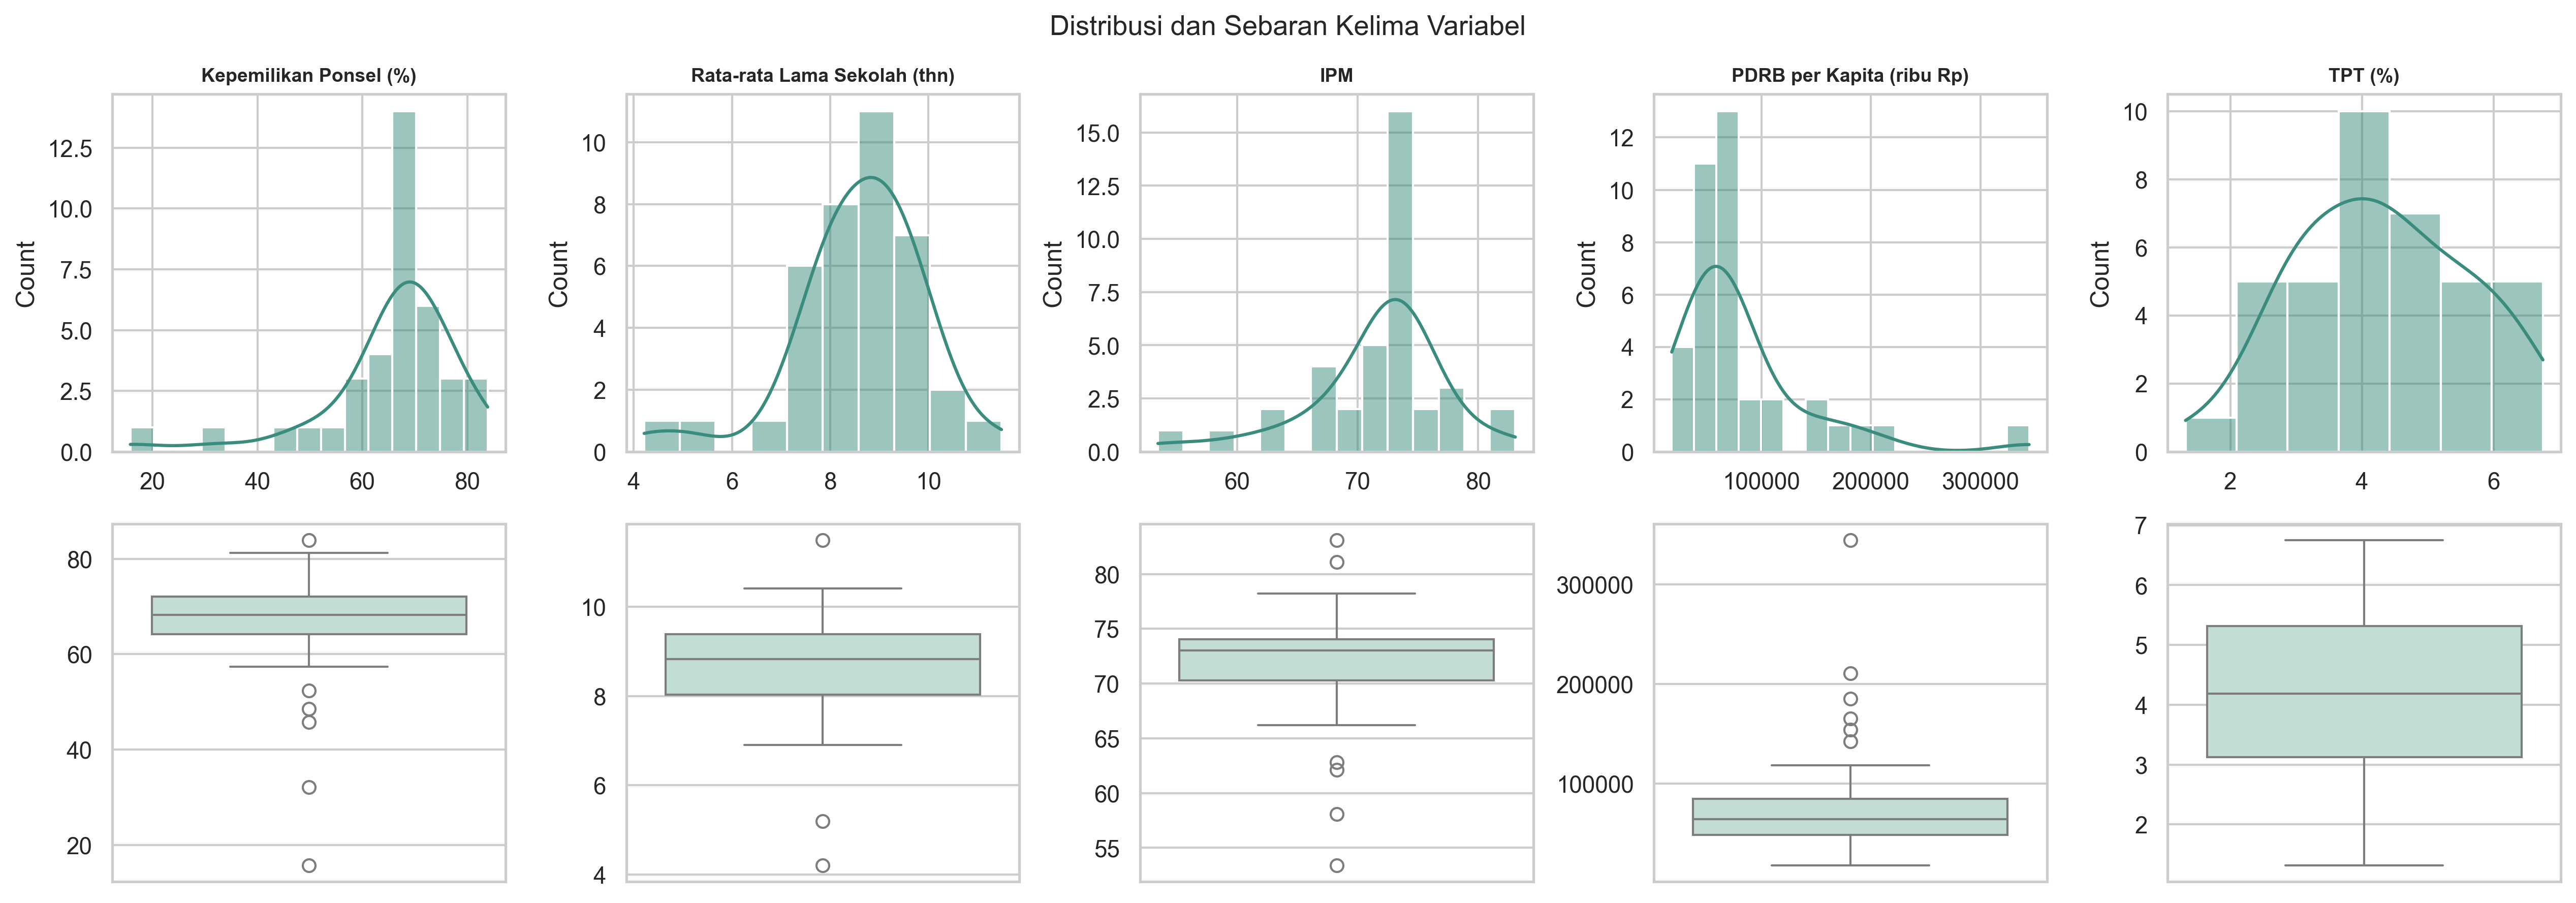

Kepemilikan Ponsel (%)           maks Kepulauan Riau            83.90   min Papua Pegunungan          15.76
Rata-rata Lama Sekolah (thn)     maks DKI Jakarta               11.49   min Papua Pegunungan           4.21
IPM                              maks DKI Jakarta               83.08   min Papua Pegunungan          53.42
PDRB per Kapita (ribu Rp)        maks DKI Jakarta          344,383.00   min Papua Pegunungan      18,105.00
TPT (%)                          maks Jawa Barat                 6.75   min Papua Pegunungan           1.32


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(17, 6))
for i, c in enumerate(FEATURES):
    sns.histplot(df[c], kde=True, ax=axes[0,i], color='#3A8C7E')
    axes[0,i].set_title(LABEL[c], fontsize=9); axes[0,i].set_xlabel('')
    sns.boxplot(y=df[c], ax=axes[1,i], color='#BFE0D8'); axes[1,i].set_ylabel('')
fig.suptitle('Distribusi dan Sebaran Kelima Variabel', fontsize=13)
plt.tight_layout(); plt.show()

for c in FEATURES:
    s = df.set_index('Provinsi')[c]
    print(f'{LABEL[c]:32s} maks {s.idxmax():<20s}{s.max():>11,.2f}   min {s.idxmin():<20s}{s.min():>11,.2f}')

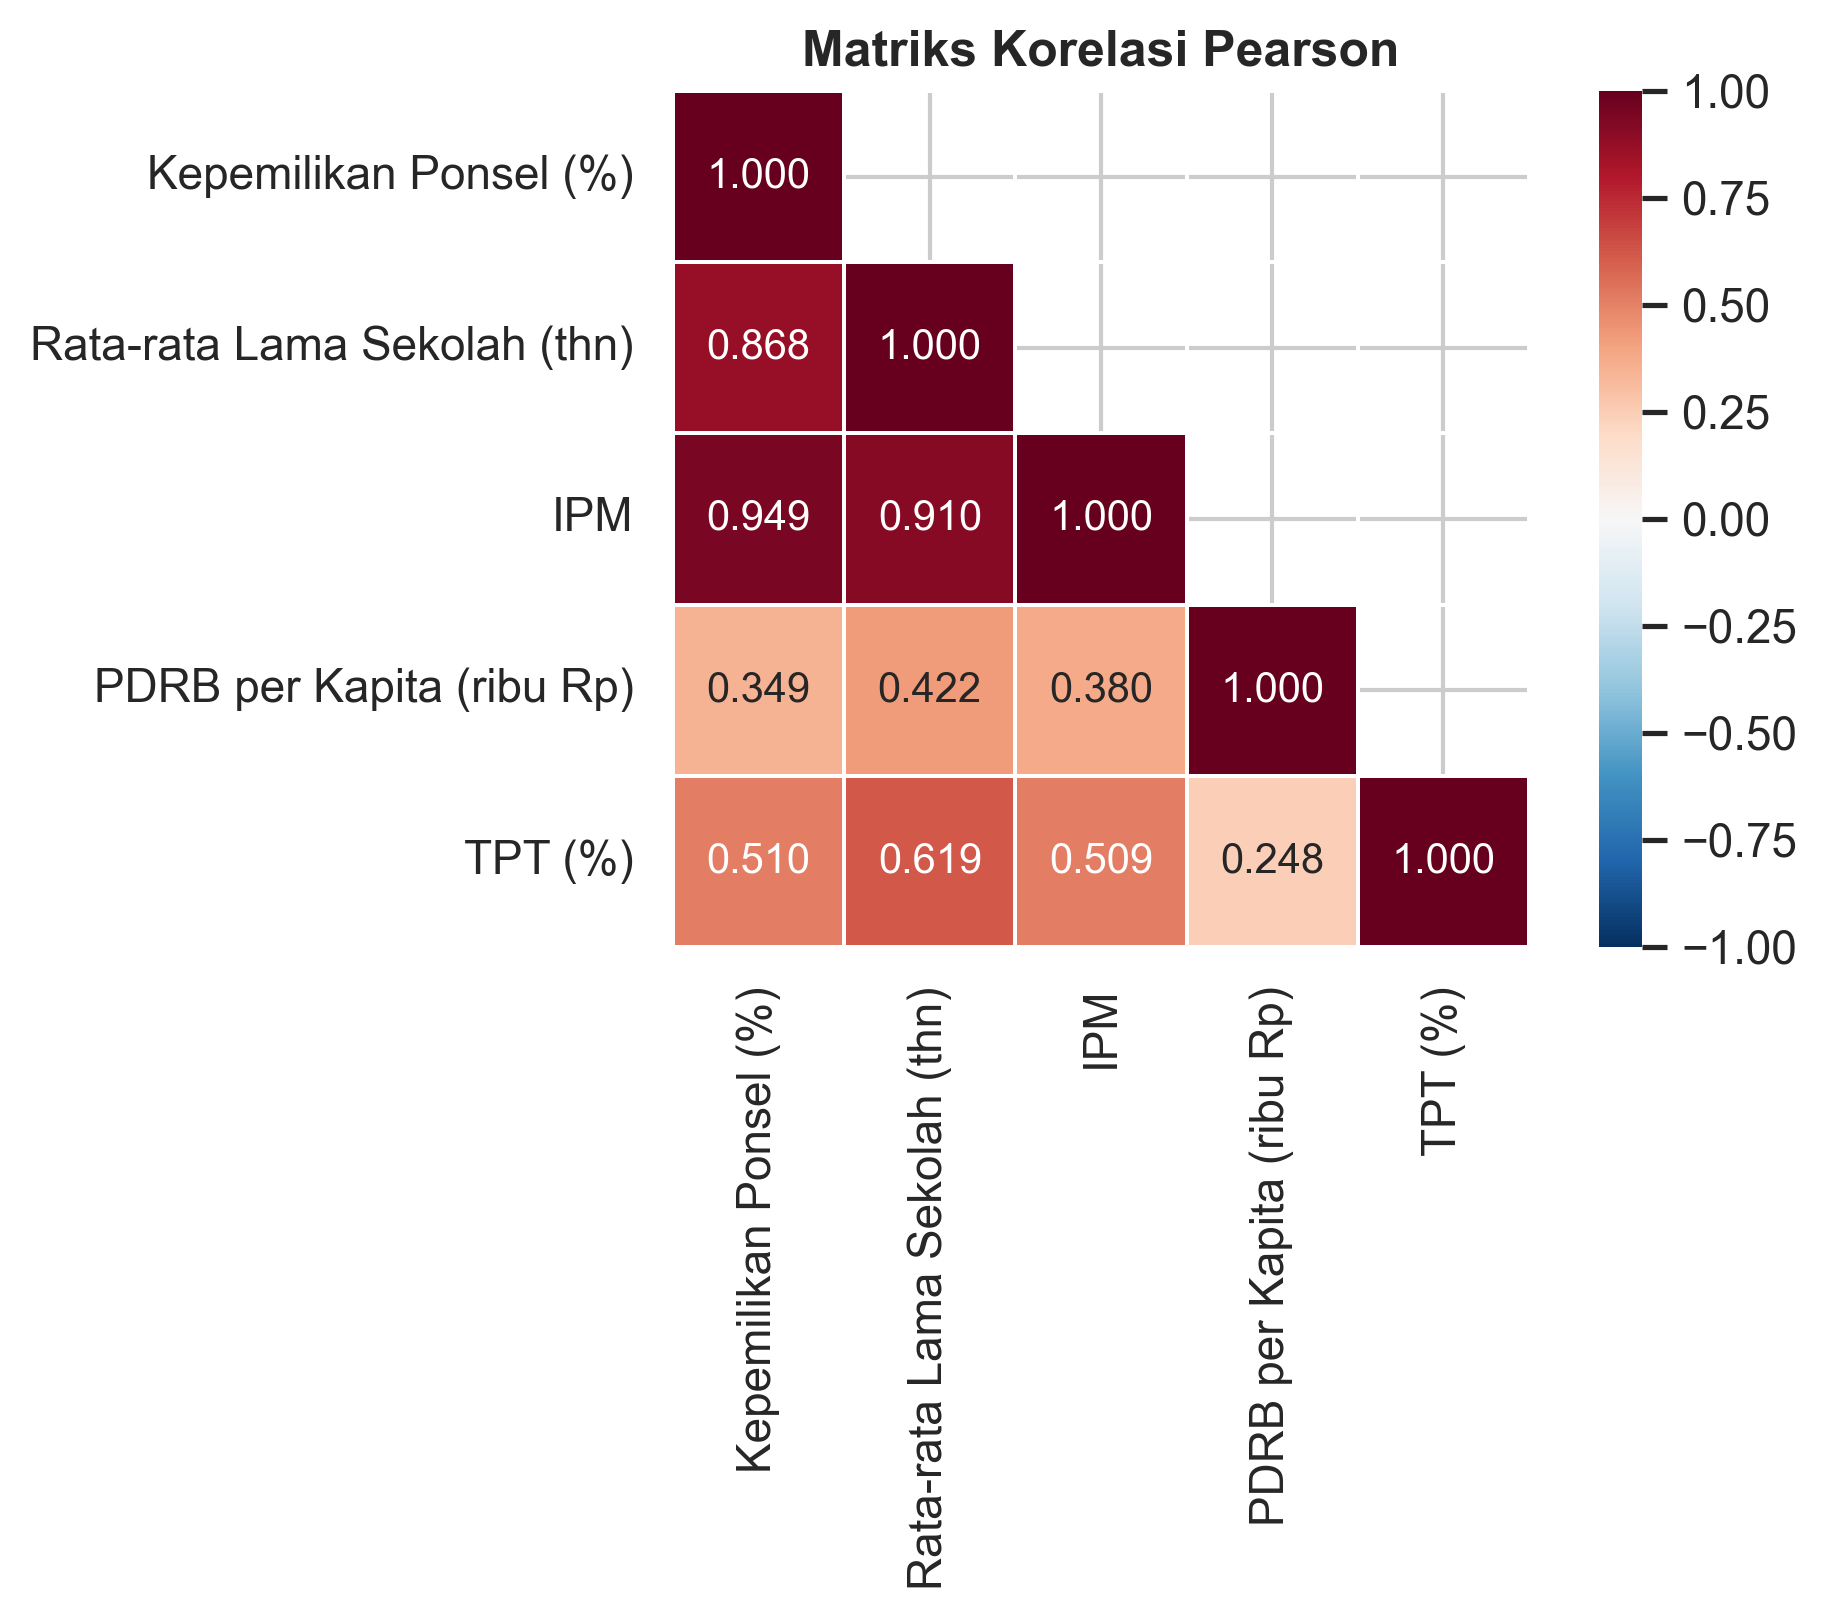

Model penuh:
        variabel  VIF
        rls_2024 7.33
        ipm_2024 6.01
pdrb_kapita_2024 1.24
        tpt_2024 1.67

Tanpa IPM:
        variabel  VIF
        rls_2024 1.83
pdrb_kapita_2024 1.24
        tpt_2024 1.62


In [6]:
corr = df[FEATURES].corr()
plt.figure(figsize=(7,5.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool),k=1), annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            xticklabels=[LABEL[c] for c in FEATURES], yticklabels=[LABEL[c] for c in FEATURES])
plt.title('Matriks Korelasi Pearson'); plt.tight_layout(); plt.show()

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
def vif_tabel(data, cols):
    Xc = add_constant(data[cols])
    return pd.DataFrame({'variabel': cols,
        'VIF': [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])]}).round(2)

tmp = df.copy(); tmp['pdrb_kapita_2024'] = np.log1p(tmp['pdrb_kapita_2024'])
print('Model penuh:');  print(vif_tabel(tmp, X_COLS).to_string(index=False))
print('\nTanpa IPM:');  print(vif_tabel(tmp, [c for c in X_COLS if c != 'ipm_2024']).to_string(index=False))

>**Catatan.** Rata-rata lama sekolah adalah komponen penyusun IPM, sehingga keduanya
> berkorelasi secara struktural. Konsekuensinya diuji lewat VIF di atas dan lewat model
> pembanding tanpa IPM pada Bagian 10.

## 3. Uji Banding Skema Praproses

Alih-alih memilih satu transformasi secara sepihak, lima skema diuji dan dinilai
berdasarkan perbaikan normalitas (statistik Shapiro-Wilk rata-rata) serta kinerja klaster yang dihasilkan.

In [7]:
raw  = df[FEATURES].copy()
logd = raw.copy(); logd['pdrb_kapita_2024'] = np.log1p(logd['pdrb_kapita_2024'])

SKEMA = {
    'log+Standard': ('log1p pada PDRB lalu Z-score', StandardScaler().fit_transform(logd)),
    'Standard'    : ('Z-score tanpa transformasi',   StandardScaler().fit_transform(raw)),
    'Robust'      : ('median dan IQR, tahan pencilan', RobustScaler().fit_transform(raw)),
    'YeoJohnson'  : ('Yeo-Johnson, menangani kedua arah kemencengan',
                     PowerTransformer('yeo-johnson', standardize=True).fit_transform(raw)),
    'Quantile'    : ('pemetaan kuantil ke normal',
                     QuantileTransformer(output_distribution='normal', n_quantiles=30,
                                         random_state=RANDOM_STATE).fit_transform(raw)),
}

baris = []
for nama, (ket, M) in SKEMA.items():
    W = np.mean([stats.shapiro(M[:, j]).statistic for j in range(M.shape[1])])
    sk = np.mean(np.abs(pd.DataFrame(M).skew()))
    baris.append({'skema': nama, 'keterangan': ket,
                  'Shapiro-W rata2': round(W, 4), '|skewness| rata2': round(sk, 3)})
display(pd.DataFrame(baris).set_index('skema'))

,keterangan,Shapiro-W rata2,|skewness| rata2
skema,,,
log+Standard,log1p pada PDRB lalu Z-score,0.9156,0.954
Standard,Z-score tanpa transformasi,0.8691,1.370
Robust,"median dan IQR, tahan pencilan",0.8691,1.370
YeoJohnson,"Yeo-Johnson, menangani kedua arah kemencengan",0.9697,0.094
Quantile,pemetaan kuantil ke normal,0.8768,0.005


## 4. Pencarian Konfigurasi Klaster Terbaik

Dijelajahi **5 skema praproses × 3 ruang fitur × 4 nilai k × 5 algoritma**.
Solusi disaring dua syarat kelayakan lebih dulu — klaster terbesar maksimal 70% unit
dan setiap klaster minimal 2 anggota — agar solusi yang rapi secara matematis tetapi
tidak berguna untuk penargetan kebijakan tersingkir. Pemenang dipilih dari skor
komposit peringkat silhouette, Davies-Bouldin, dan Calinski-Harabasz.

In [8]:
MAKS_PANGSA, MIN_ANGGOTA = 0.70, 2

def layak(lab, n):
    u = np.bincount(lab)
    return (u.max()/n <= MAKS_PANGSA) and (u.min() >= MIN_ANGGOTA)

def buat_ruang(M, ruang):
    if ruang == 'fitur': return M
    return PCA(n_components=int(ruang[-1]), random_state=RANDOM_STATE).fit_transform(M)

hasil = []
for nama, (_, M) in SKEMA.items():
    for ruang in ['fitur', 'PCA2', 'PCA3']:
        Z = buat_ruang(M, ruang)
        for k in range(3, 7):
            algo = {
                'KMeans'  : KMeans(k, n_init=100, random_state=RANDOM_STATE).fit_predict(Z),
                'GMM'     : GaussianMixture(k, covariance_type='full', n_init=20,
                                            random_state=RANDOM_STATE).fit_predict(Z),
                'Ward'    : AgglomerativeClustering(k, linkage='ward').fit_predict(Z),
                'Average' : AgglomerativeClustering(k, linkage='average').fit_predict(Z),
                'Spectral': SpectralClustering(k, random_state=RANDOM_STATE,
                                               affinity='nearest_neighbors',
                                               n_neighbors=6).fit_predict(Z),
            }
            for an, lab in algo.items():
                if len(set(lab)) < k or not layak(lab, len(Z)):
                    continue
                hasil.append({'skema': nama, 'ruang': ruang, 'algoritma': an, 'k': k,
                              'silhouette': silhouette_score(Z, lab),
                              'davies_bouldin': davies_bouldin_score(Z, lab),
                              'calinski': calinski_harabasz_score(Z, lab),
                              'ukuran': str(sorted(np.bincount(lab).tolist()))})

grid = pd.DataFrame(hasil)
grid['skor'] = (grid.silhouette.rank(pct=True)
                + (-grid.davies_bouldin).rank(pct=True)
                + grid.calinski.rank(pct=True)) / 3
grid = grid.sort_values('skor', ascending=False).reset_index(drop=True)
print(f'Konfigurasi lolos syarat: {len(grid)} dari seluruh kombinasi yang diuji\n')
display(grid.head(10).round(4))

Konfigurasi lolos syarat: 136 dari seluruh kombinasi yang diuji



,skema,ruang,algoritma,k,silhouette,davies_bouldin,calinski,ukuran,skor
0,Robust,PCA2,Ward,4,0.5299,0.6113,47.4699,"[2, 5, 6, 25]",0.9963
1,Robust,PCA2,KMeans,4,0.5299,0.6113,47.4699,"[2, 5, 6, 25]",0.9914
2,Standard,PCA2,Ward,4,0.4572,0.6440,45.9581,"[2, 5, 8, 23]",0.9657
3,Standard,PCA2,KMeans,4,0.4500,0.6494,46.1247,"[2, 5, 9, 22]",0.9608
4,Robust,PCA2,Ward,3,0.5468,0.6541,37.9239,"[5, 8, 25]",0.9608
5,YeoJohnson,PCA2,KMeans,6,0.4404,0.6192,41.5300,"[3, 3, 3, 8, 8, 13]",0.9510
6,YeoJohnson,PCA2,KMeans,5,0.4511,0.6650,41.9252,"[3, 3, 8, 10, 14]",0.9510
7,Robust,PCA3,KMeans,4,0.4776,0.6716,40.6028,"[2, 5, 6, 25]",0.9510
8,Robust,PCA3,Ward,4,0.4776,0.6603,38.9918,"[2, 5, 5, 26]",0.9485
9,Robust,PCA3,Ward,3,0.5191,0.7001,35.4533,"[5, 7, 26]",0.9167


In [9]:
juara = grid.iloc[0]
SKEMA_PILIH, RUANG_PILIH, ALGO_PILIH, K_OPT = (juara.skema, juara.ruang,
                                               juara.algoritma, int(juara.k))
print(f'Konfigurasi terpilih : {SKEMA_PILIH} | {RUANG_PILIH} | {ALGO_PILIH} | k={K_OPT}')
print(f'  silhouette      = {juara.silhouette:.4f}')
print(f'  davies_bouldin  = {juara.davies_bouldin:.4f}')
print(f'  calinski        = {juara.calinski:.2f}')

dasar = grid[(grid.skema=='log+Standard') & (grid.ruang=='PCA2') &
             (grid.algoritma=='KMeans') & (grid.k==4)]
if len(dasar):
    b = dasar.iloc[0]
    print(f'\nPembanding konfigurasi awam (log+Standard | PCA2 | KMeans | k=4):')
    print(f'  silhouette {b.silhouette:.4f} -> {juara.silhouette:.4f} '
          f'({(juara.silhouette/b.silhouette-1)*100:+.1f}%)')
    print(f'  davies_bouldin {b.davies_bouldin:.4f} -> {juara.davies_bouldin:.4f} '
          f'({(juara.davies_bouldin/b.davies_bouldin-1)*100:+.1f}%)')
    print(f'  calinski {b.calinski:.2f} -> {juara.calinski:.2f} '
          f'({(juara.calinski/b.calinski-1)*100:+.1f}%)')

Konfigurasi terpilih : Robust | PCA2 | Ward | k=4
  silhouette      = 0.5299
  davies_bouldin  = 0.6113
  calinski        = 47.47

Pembanding konfigurasi awam (log+Standard | PCA2 | KMeans | k=4):
  silhouette 0.4008 -> 0.5299 (+32.2%)
  davies_bouldin 0.7757 -> 0.6113 (-21.2%)
  calinski 37.68 -> 47.47 (+26.0%)


## 5. Klaster Final dan Profilnya

,hp_seluler_2024,rls_2024,ipm_2024,pdrb_kapita_2024,tpt_2024,n
klaster,,,,,,
0,79.13,10.09,77.21,211966.6,5.09,5
1,23.93,4.70,55.76,80302.5,1.71,2
2,69.12,8.88,73.28,61899.8,4.44,25
3,53.85,7.57,65.43,58275.0,4.05,6


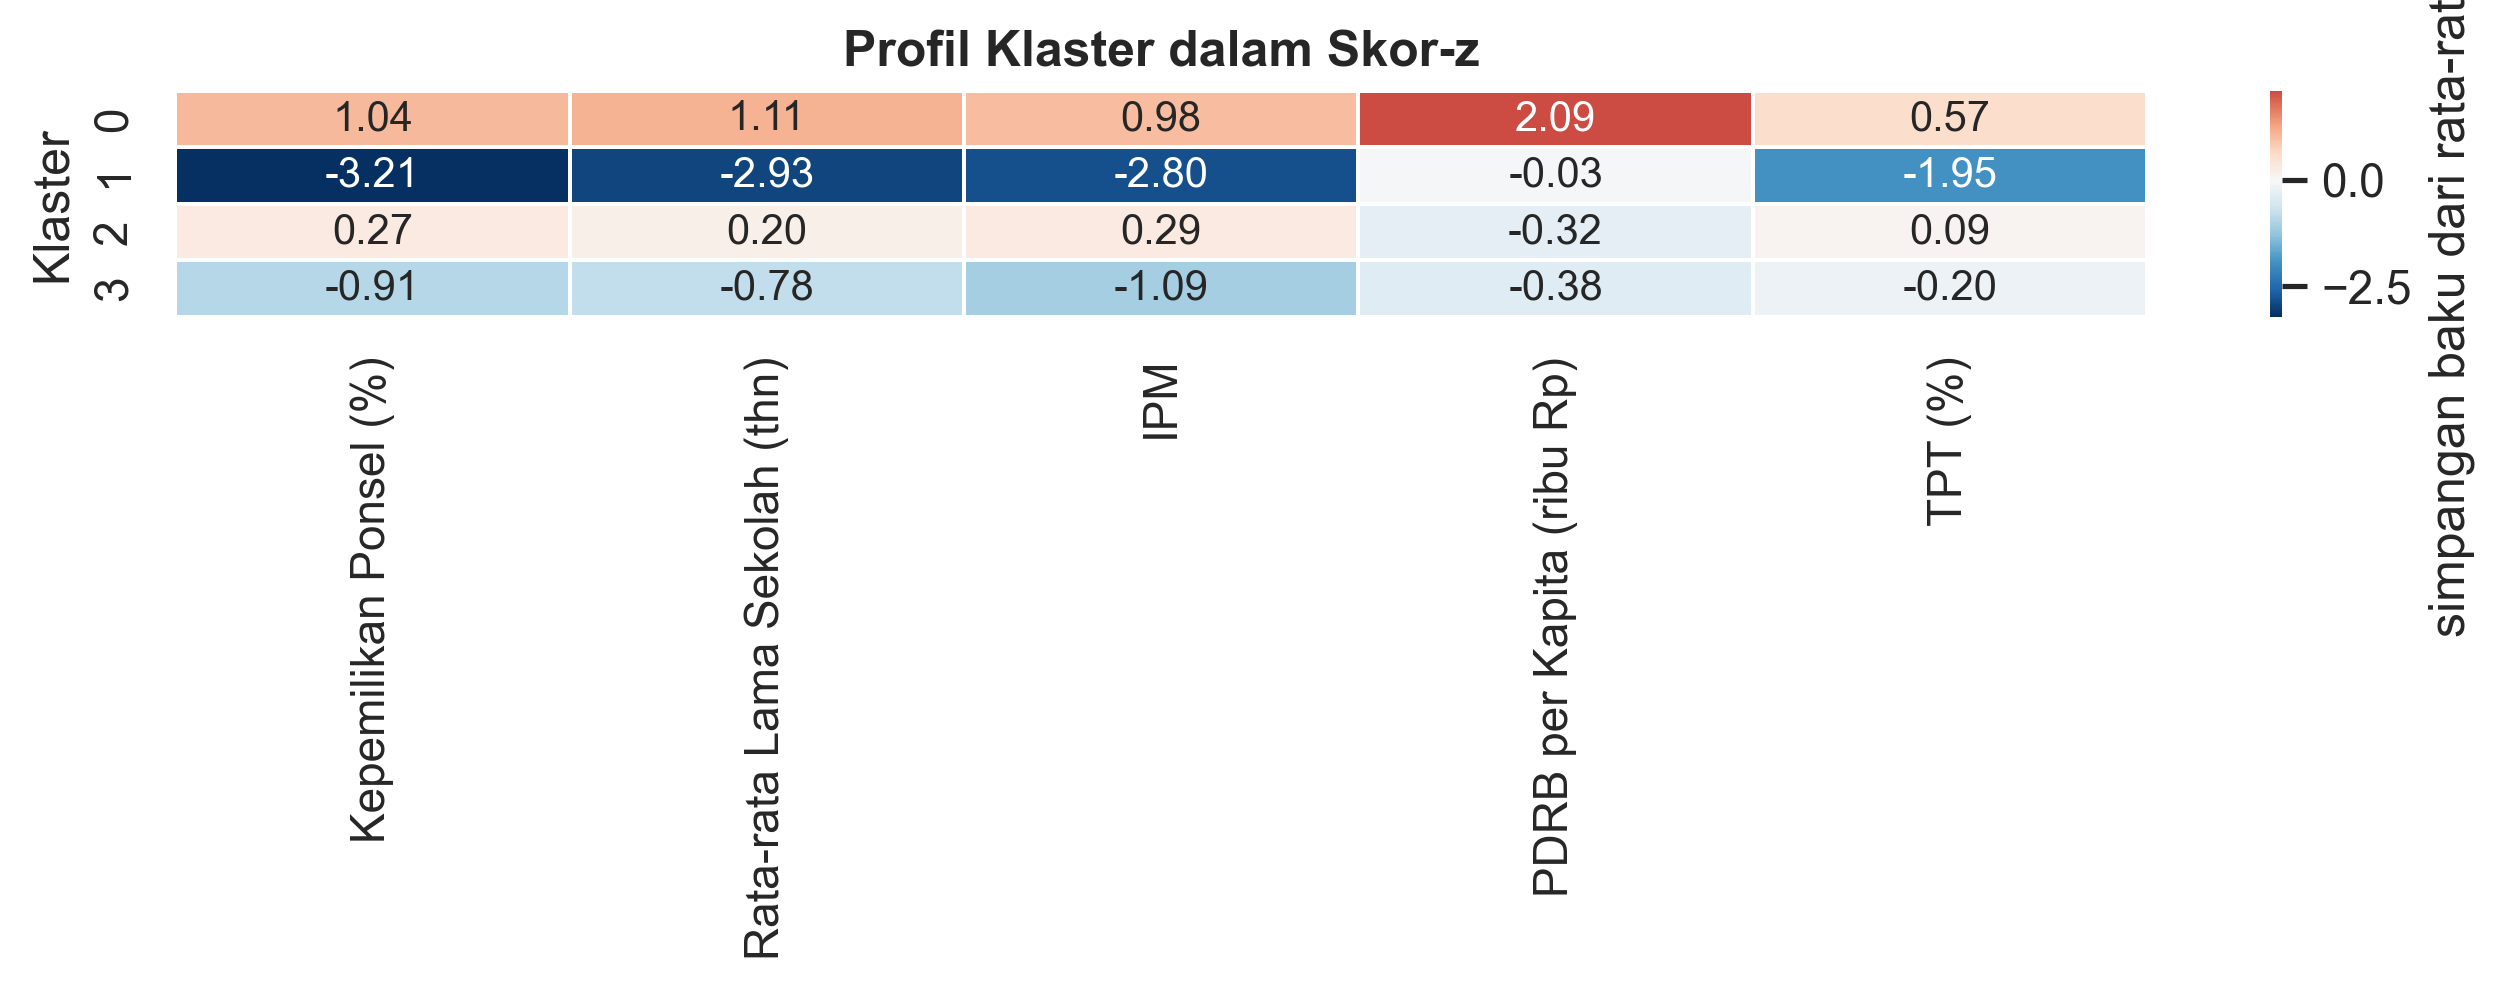

In [10]:
M_pilih = SKEMA[SKEMA_PILIH][1]
Z = buat_ruang(M_pilih, RUANG_PILIH)

def bangun(algo, k, Z):
    if algo == 'KMeans':   return KMeans(k, n_init=200, random_state=RANDOM_STATE).fit_predict(Z)
    if algo == 'GMM':      return GaussianMixture(k, covariance_type='full', n_init=30,
                                                  random_state=RANDOM_STATE).fit_predict(Z)
    if algo == 'Ward':     return AgglomerativeClustering(k, linkage='ward').fit_predict(Z)
    if algo == 'Average':  return AgglomerativeClustering(k, linkage='average').fit_predict(Z)
    return SpectralClustering(k, random_state=RANDOM_STATE, affinity='nearest_neighbors',
                              n_neighbors=6).fit_predict(Z)

label = bangun(ALGO_PILIH, K_OPT, Z)
df['klaster'] = label

profil = df.groupby('klaster')[FEATURES].mean().round(2)
profil['n'] = df['klaster'].value_counts().sort_index()
display(profil)

prof_z = (df.groupby('klaster')[FEATURES].mean() - df[FEATURES].mean()) / df[FEATURES].std()
plt.figure(figsize=(9,3.4))
sns.heatmap(prof_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=.5,
            xticklabels=[LABEL[c] for c in FEATURES],
            cbar_kws={'label':'simpangan baku dari rata-rata nasional'})
plt.title('Profil Klaster dalam Skor-z'); plt.ylabel('Klaster'); plt.tight_layout(); plt.show()

In [11]:
skor_maju = prof_z[[Y_COL,'rls_2024','ipm_2024','pdrb_kapita_2024']].mean(axis=1)
urut = skor_maju.sort_values(ascending=False).index.tolist()
NAMA = ['Maju dan Terhubung', 'Berkembang Menengah', 'Tertinggal Sedang',
        'Tertinggal Ekstrem', 'Klaster E', 'Klaster F']
PETA_NAMA = {k: NAMA[i] for i, k in enumerate(urut)}
df['nama_klaster'] = df['klaster'].map(PETA_NAMA)

for k in urut:
    a = df.loc[df.klaster==k, 'Provinsi'].tolist()
    print(f'\nKlaster {k} — {PETA_NAMA[k]} (n={len(a)})\n  ' + ', '.join(a))


Klaster 0 — Maju dan Terhubung (n=5)
  Riau, Kepulauan Riau, DKI Jakarta, Kalimantan Timur, Kalimantan Utara

Klaster 2 — Berkembang Menengah (n=25)
  Aceh, Sumatera Utara, Sumatera Barat, Jambi, Sumatera Selatan, Bengkulu, Lampung, Kepulauan Bangka Belitung, Jawa Barat, Jawa Tengah, DI Yogyakarta, Jawa Timur, Banten, Bali, Nusa Tenggara Barat, Kalimantan Barat, Kalimantan Tengah, Kalimantan Selatan, Sulawesi Utara, Sulawesi Tengah, Sulawesi Selatan, Sulawesi Tenggara, Gorontalo, Maluku, Maluku Utara

Klaster 3 — Tertinggal Sedang (n=6)
  Nusa Tenggara Timur, Sulawesi Barat, Papua Barat, Papua Barat Daya, Papua, Papua Selatan

Klaster 1 — Tertinggal Ekstrem (n=2)
  Papua Tengah, Papua Pegunungan


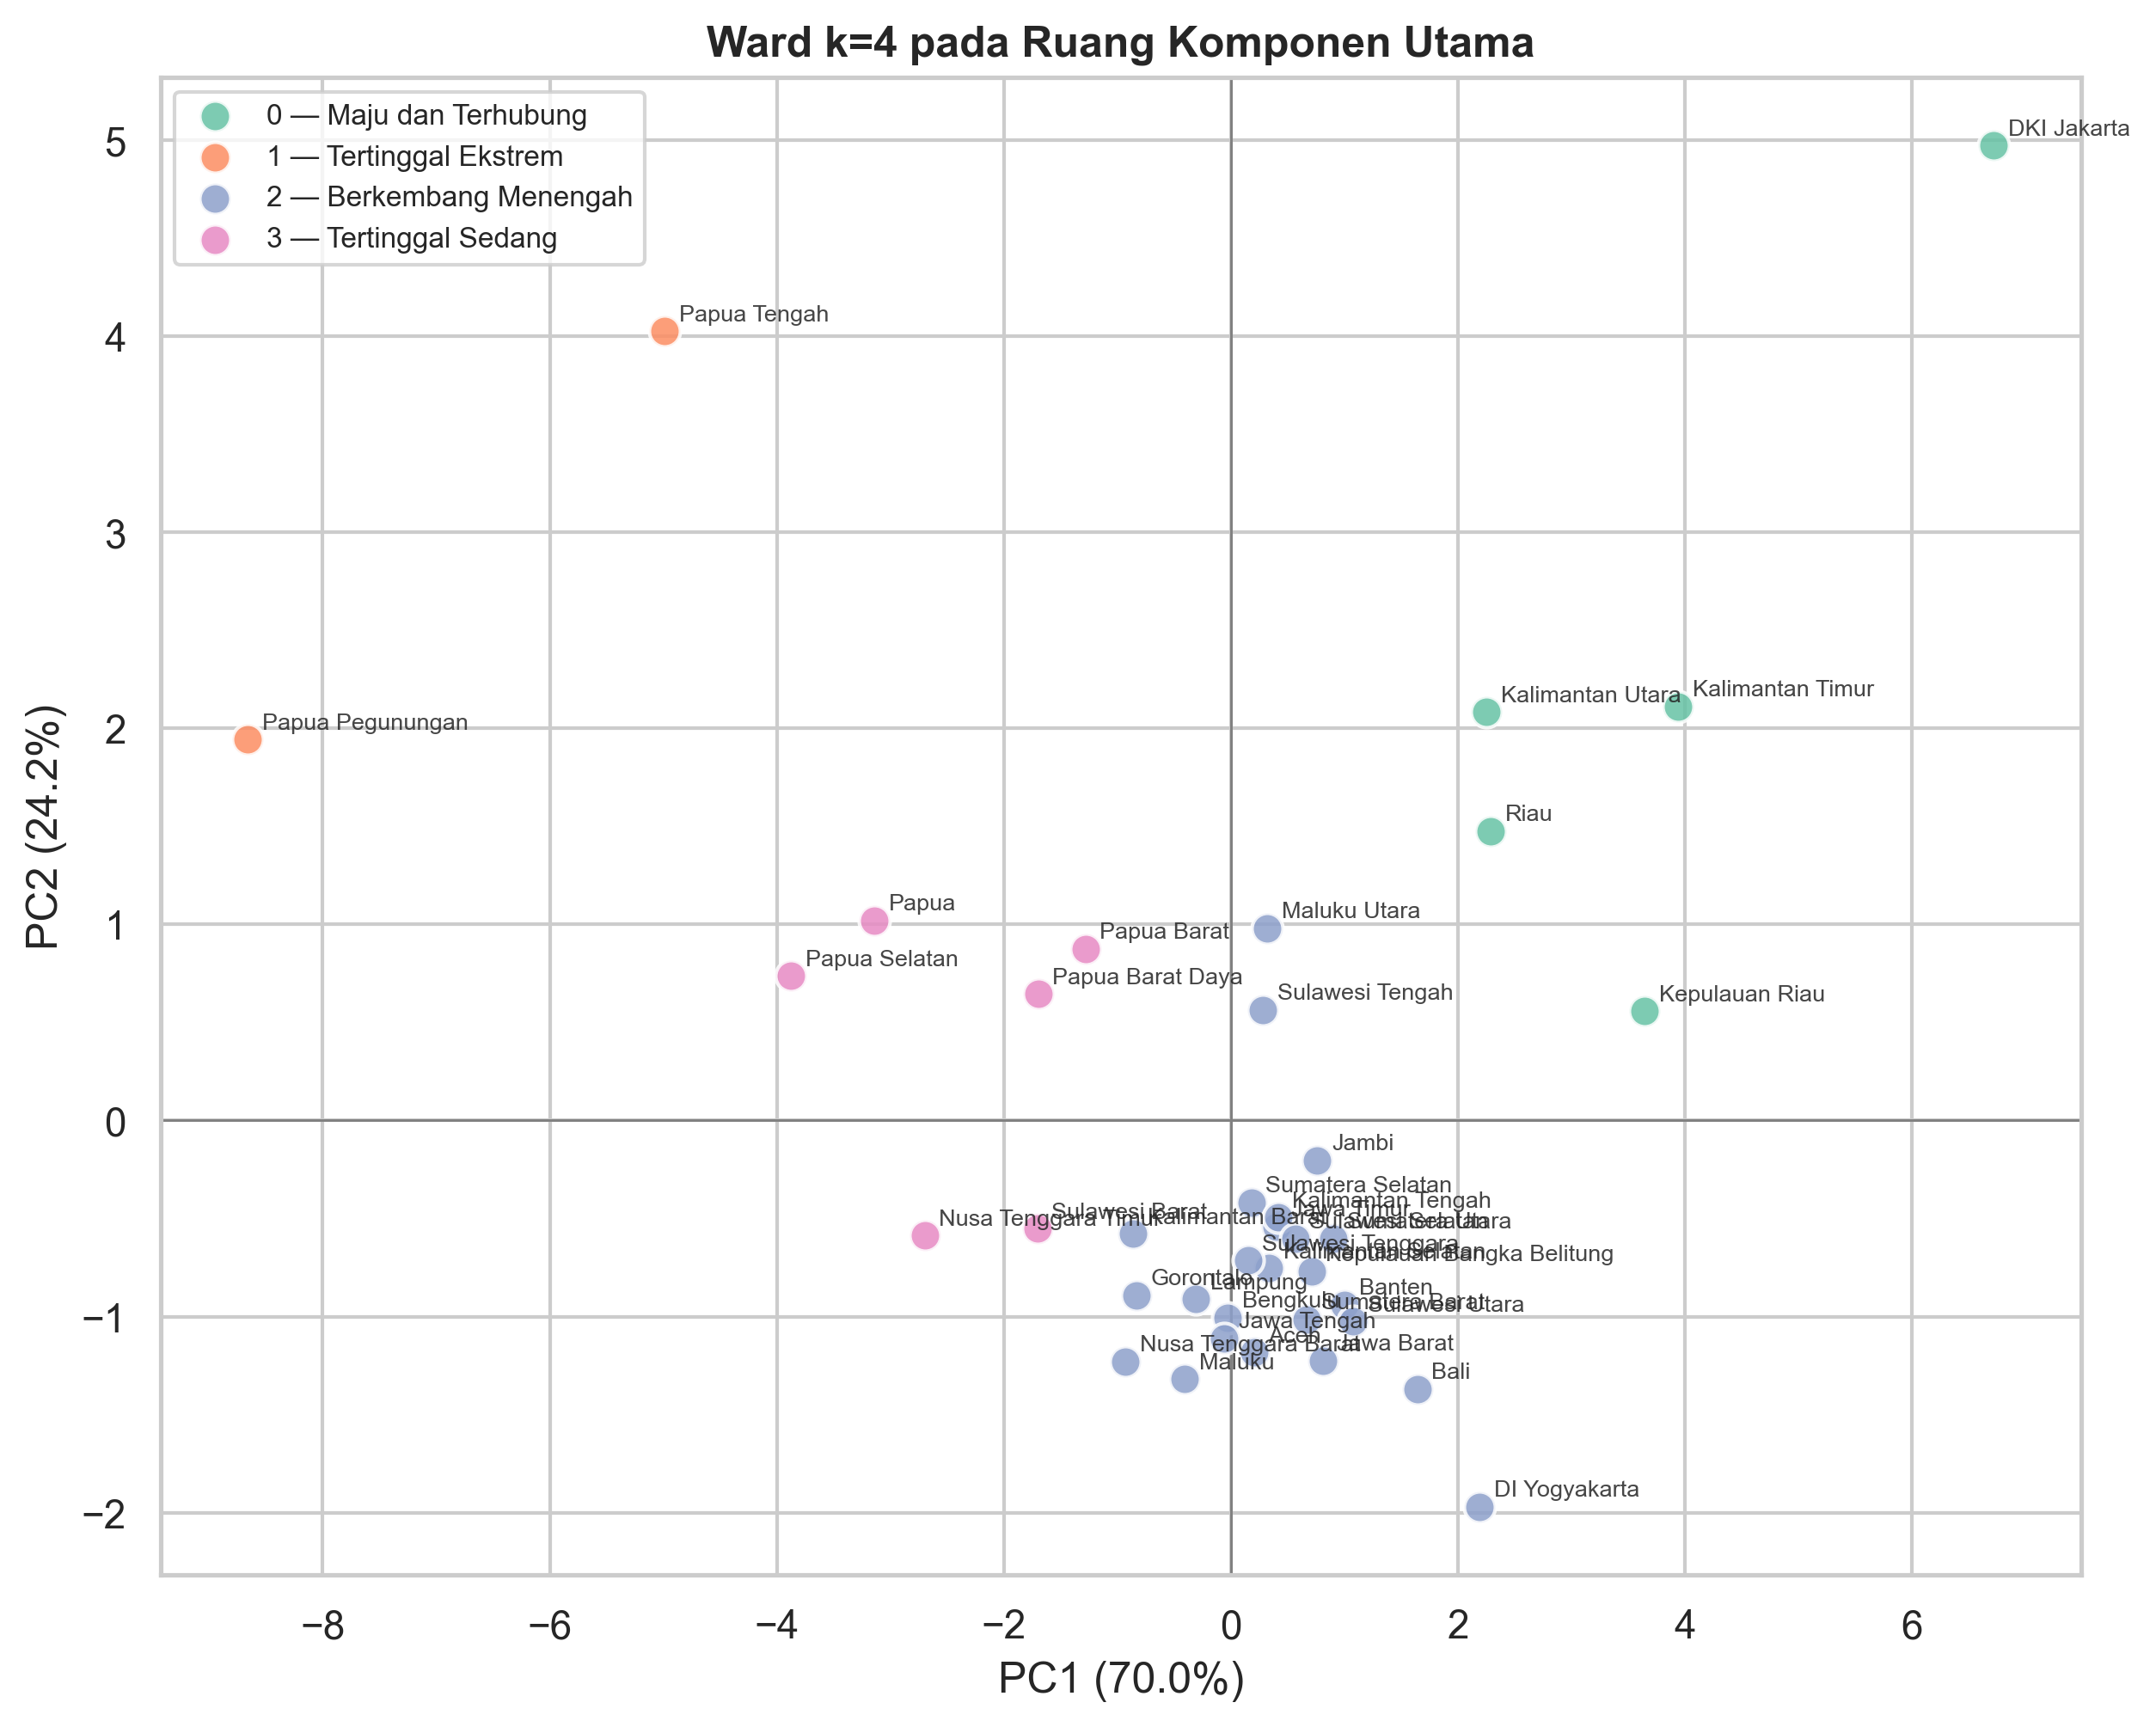

In [12]:
P2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(M_pilih)
S2 = P2.transform(M_pilih)
warna = sns.color_palette('Set2', K_OPT)
fig, ax = plt.subplots(figsize=(8.5,6.8))
for k in range(K_OPT):
    m = label == k
    ax.scatter(S2[m,0], S2[m,1], s=75, color=warna[k], alpha=.85,
               edgecolor='white', label=f'{k} — {PETA_NAMA[k]}', zorder=3)
for i, p in enumerate(df['Provinsi']):
    ax.annotate(p, (S2[i,0], S2[i,1]), fontsize=6.5, textcoords='offset points',
                xytext=(4,3), alpha=.85)
ax.axhline(0, color='grey', lw=.7); ax.axvline(0, color='grey', lw=.7)
ax.set(xlabel=f'PC1 ({P2.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({P2.explained_variance_ratio_[1]:.1%})',
       title=f'{ALGO_PILIH} k={K_OPT} pada Ruang Komponen Utama')
ax.legend(fontsize=8); plt.tight_layout()
fig.savefig('output_svg/01_sebaran_klaster.svg', format='svg', bbox_inches='tight')
plt.show()

## 6. Validasi Klaster

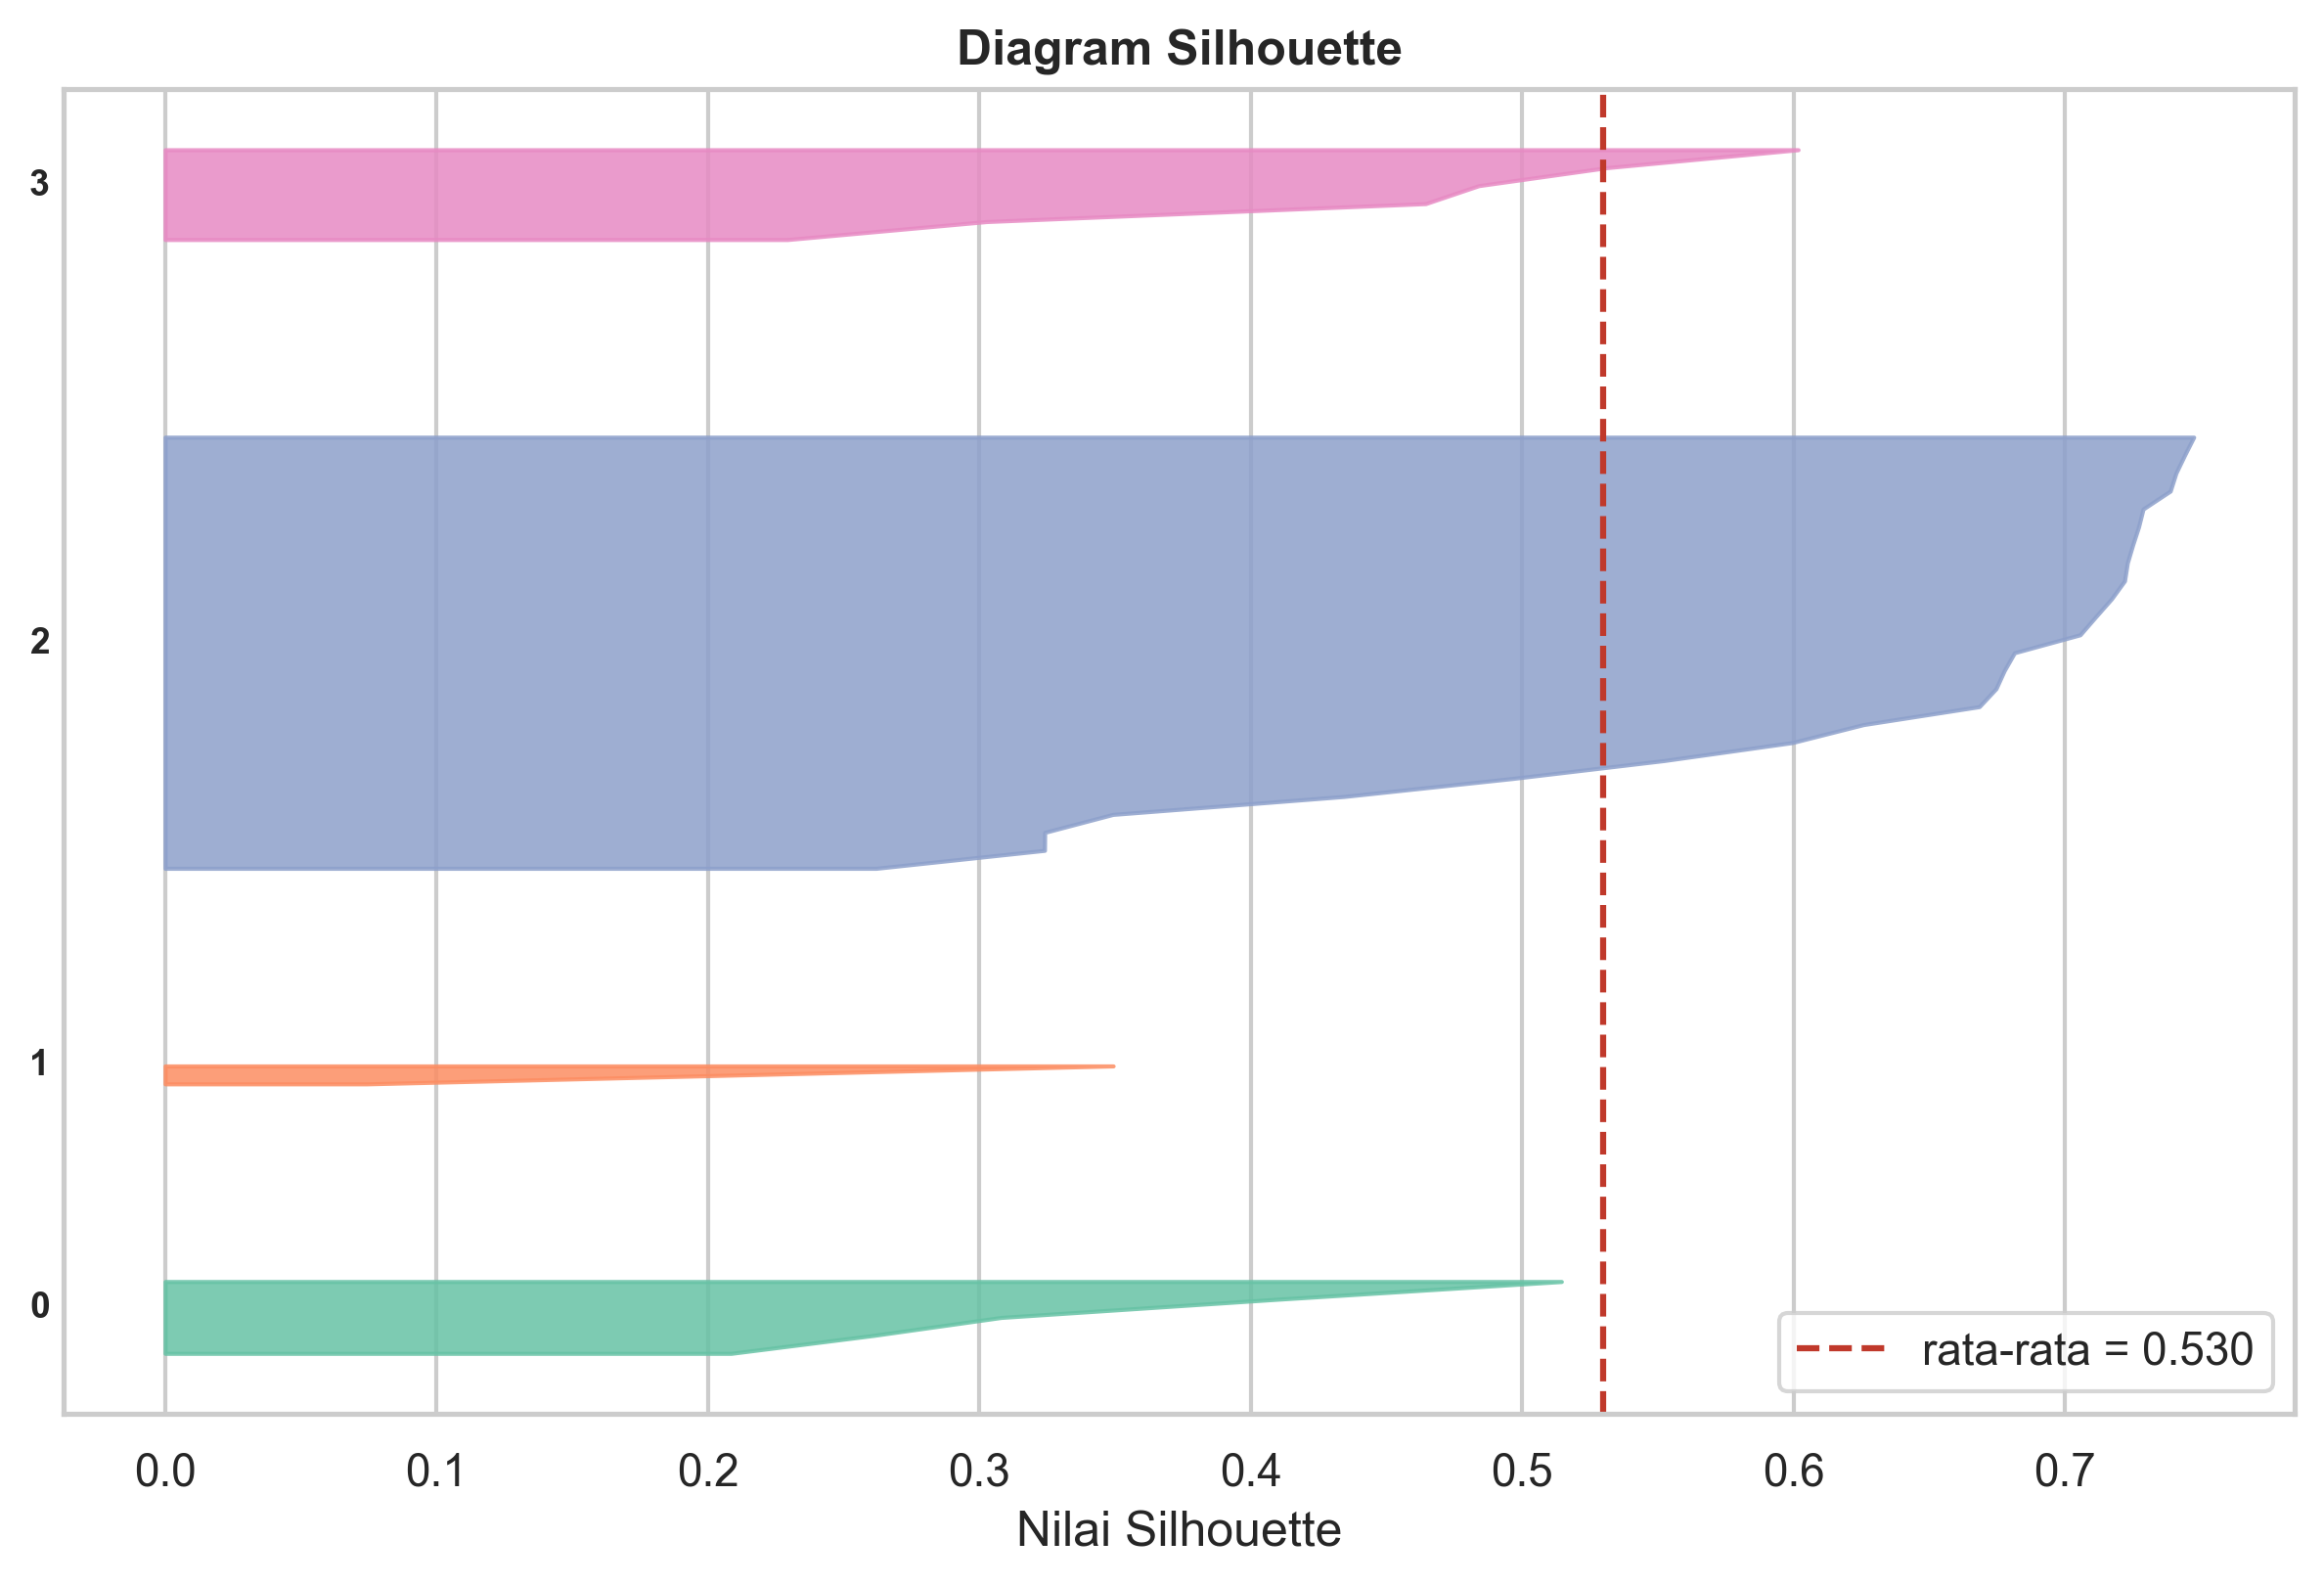

Silhouette negatif: tidak ada


In [13]:
sil = silhouette_samples(Z, label); rata = silhouette_score(Z, label)
fig, ax = plt.subplots(figsize=(8,5.5)); y0 = 10
for k in range(K_OPT):
    v = np.sort(sil[label==k]); y1 = y0 + len(v)
    ax.fill_betweenx(np.arange(y0,y1), 0, v, color=warna[k], alpha=.85)
    ax.text(-.05, y0+len(v)/2, str(k), va='center', fontsize=9, weight='bold'); y0 = y1+10
ax.axvline(rata, color='#C0392B', ls='--', label=f'rata-rata = {rata:.3f}')
ax.set(xlabel='Nilai Silhouette', ylabel='', title='Diagram Silhouette'); ax.set_yticks([])
ax.legend(); plt.tight_layout(); plt.show()
neg = df.loc[sil < 0, 'Provinsi'].tolist()
print('Silhouette negatif:', neg if neg else 'tidak ada')

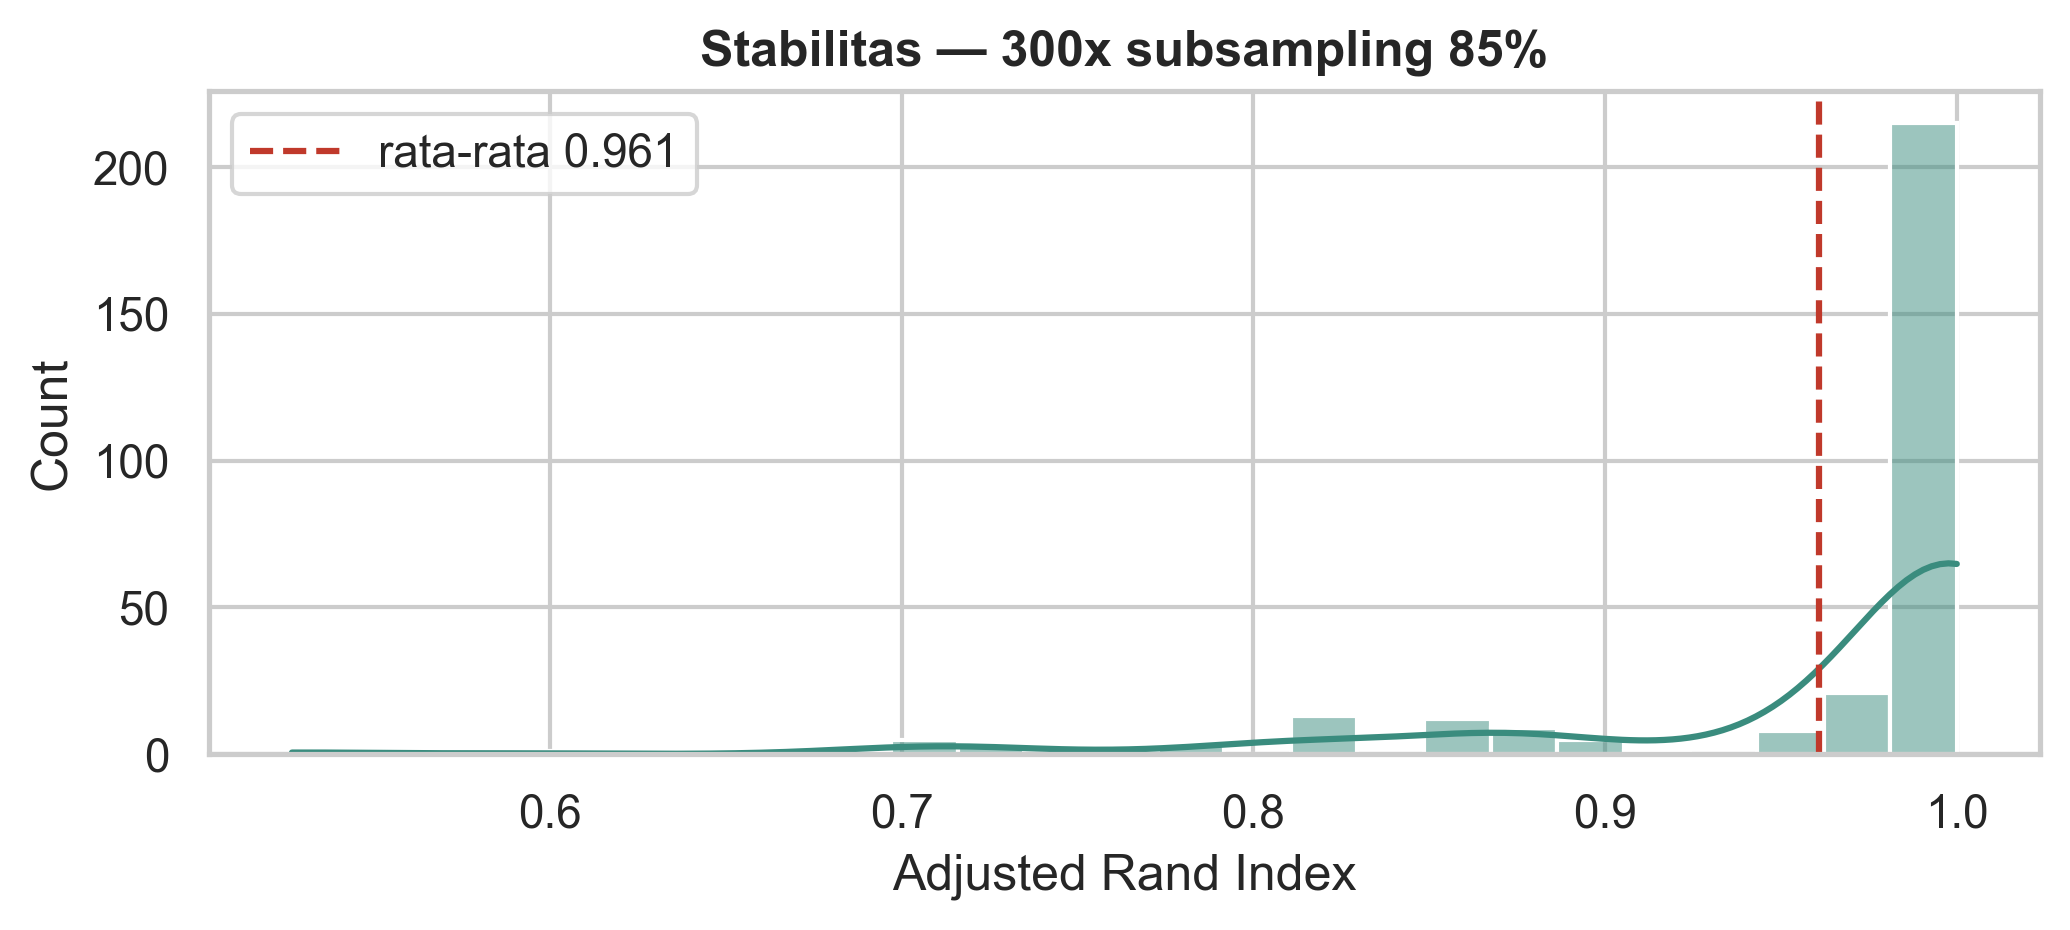

ARI 0.961 +/- 0.082 | minimum 0.527
Tafsir: >0,75 sangat stabil | 0,50-0,75 cukup | <0,50 rapuh


In [14]:
N_BOOT, FRAC = 300, .85
rng = np.random.default_rng(RANDOM_STATE); ari = []
for _ in range(N_BOOT):
    idx = rng.choice(len(Z), int(len(Z)*FRAC), replace=False)
    lab = bangun('KMeans', K_OPT, Z[idx])
    ari.append(adjusted_rand_score(label[idx], lab))
ari = np.array(ari)
plt.figure(figsize=(7,3.2)); sns.histplot(ari, bins=25, kde=True, color='#3A8C7E')
plt.axvline(ari.mean(), color='#C0392B', ls='--', label=f'rata-rata {ari.mean():.3f}')
plt.xlabel('Adjusted Rand Index'); plt.title(f'Stabilitas — {N_BOOT}x subsampling {FRAC:.0%}')
plt.legend(); plt.tight_layout(); plt.show()
print(f'ARI {ari.mean():.3f} +/- {ari.std():.3f} | minimum {ari.min():.3f}')
print('Tafsir: >0,75 sangat stabil | 0,50-0,75 cukup | <0,50 rapuh')

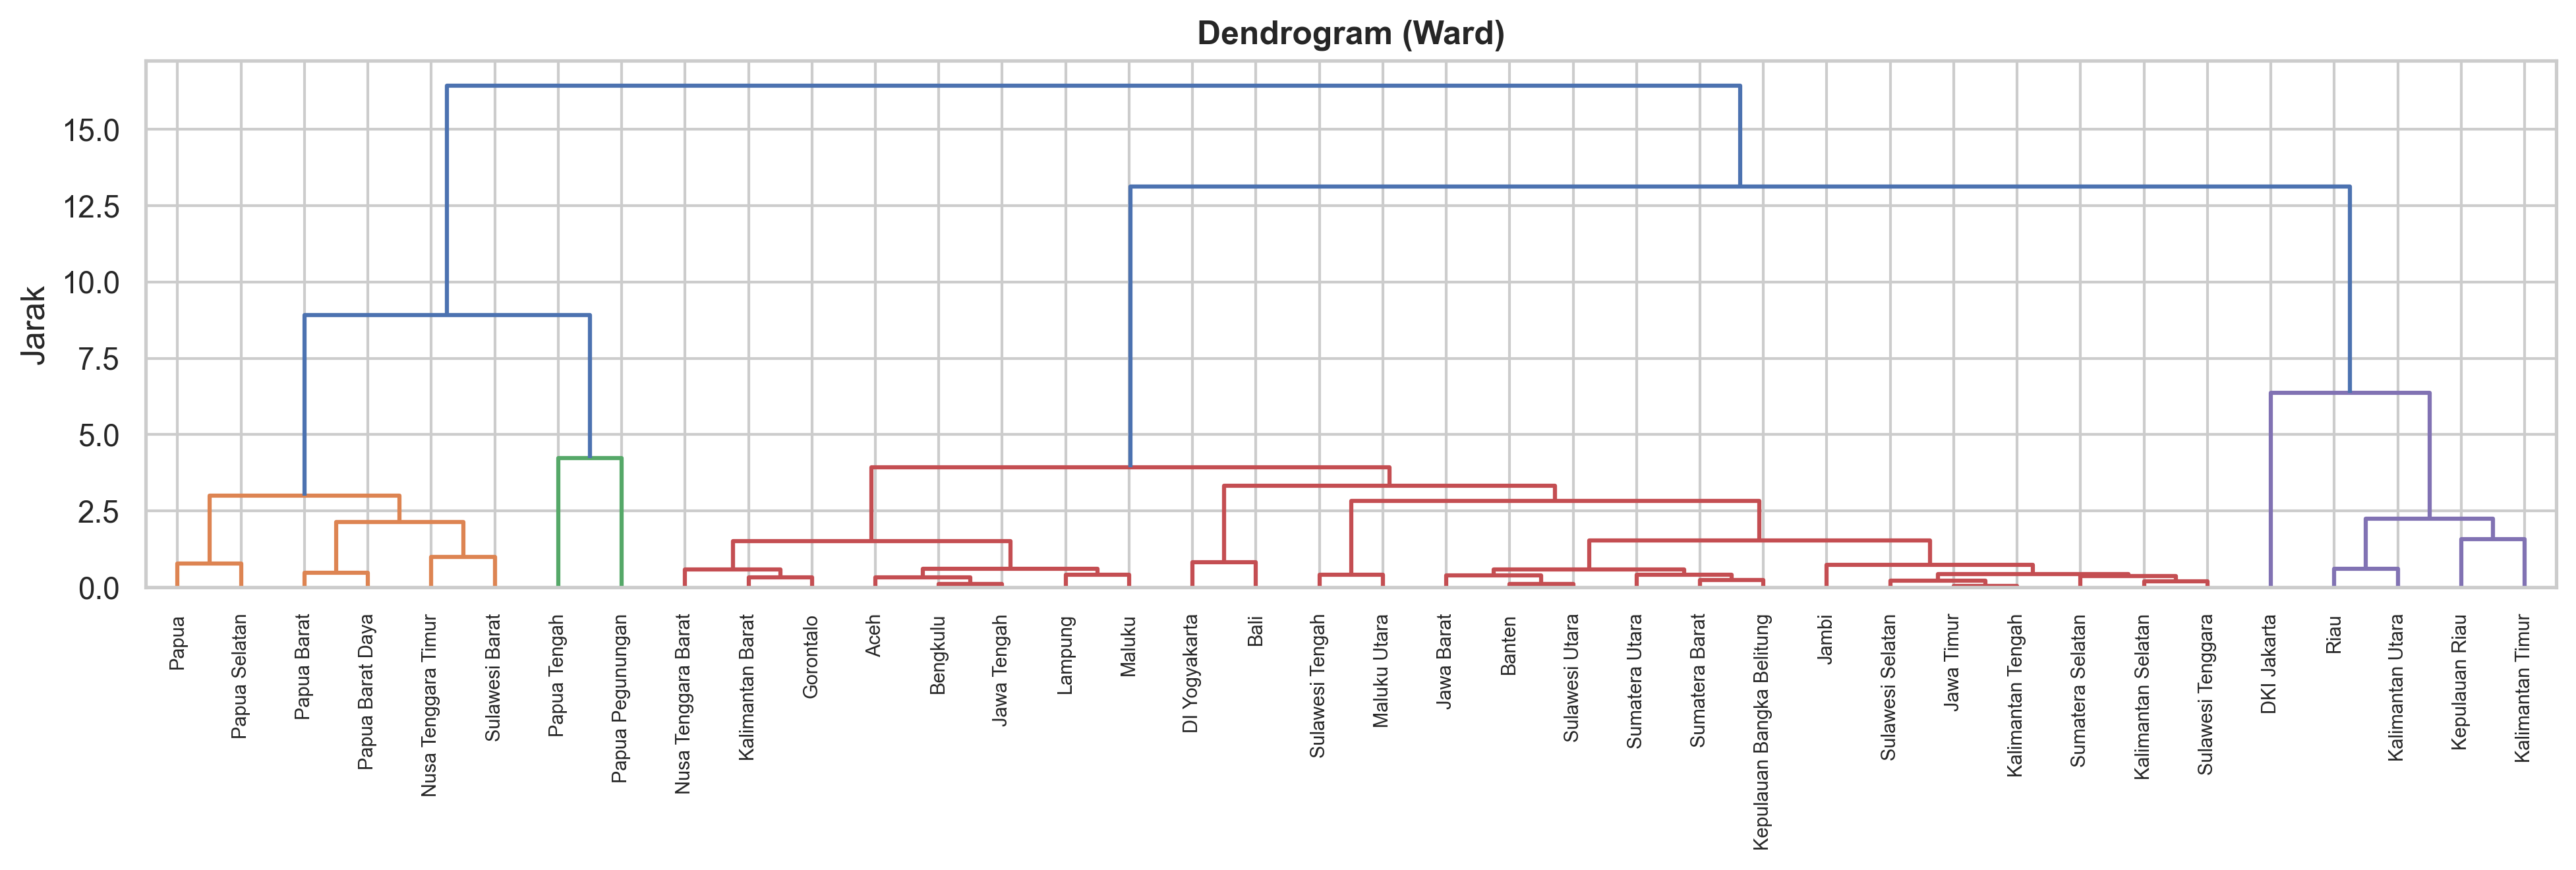

Kesepakatan antaralgoritma (ARI):


,KMeans,Ward,GMM,Average
KMeans,1.000,1.000,0.623,0.244
Ward,1.000,1.000,0.623,0.244
GMM,0.623,0.623,1.000,0.277
Average,0.244,0.244,0.277,1.000


In [15]:
L = linkage(Z, method='ward')
plt.figure(figsize=(13,4.5))
dendrogram(L, labels=df['Provinsi'].values, leaf_rotation=90, leaf_font_size=7,
           color_threshold=L[-(K_OPT-1),2])
plt.title('Dendrogram (Ward)'); plt.ylabel('Jarak'); plt.tight_layout(); plt.show()

banding_algo = {a: bangun(a, K_OPT, Z) for a in ['KMeans','Ward','GMM','Average']}
mat = pd.DataFrame({a: [adjusted_rand_score(banding_algo[a], banding_algo[b])
                        for b in banding_algo] for a in banding_algo}, index=list(banding_algo))
print('Kesepakatan antaralgoritma (ARI):'); display(mat.round(3))

## 7. Indeks Komposit Kerentanan Akses Digital

Skor tinggi berarti lebih rentan. IPM, RLS, PDRB per kapita, dan kepemilikan ponsel dibalik arahnya;
TPT dipakai apa adanya. Bobot diturunkan dari muatan komponen utama pertama.

In [16]:
ARAH = {'hp_seluler_2024':-1, 'rls_2024':-1, 'ipm_2024':-1, 'pdrb_kapita_2024':-1, 'tpt_2024':+1}
mm = lambda s: (s - s.min())/(s.max() - s.min())
norm = pd.DataFrame({c: (mm(np.log1p(df[c]) if c=='pdrb_kapita_2024' else df[c]) if ARAH[c]>0
                         else 1 - mm(np.log1p(df[c]) if c=='pdrb_kapita_2024' else df[c]))
                     for c in FEATURES})
w1 = np.abs(P2.components_[0]); BOBOT = pd.Series(w1/w1.sum(), index=FEATURES)
print('Bobot dari PC1:'); print(BOBOT.round(4).to_string())

df['indeks_kerentanan'] = (norm*BOBOT).sum(axis=1)
df['peringkat'] = df['indeks_kerentanan'].rank(ascending=False).astype(int)
q = df['indeks_kerentanan'].quantile([.25,.5,.75]).values
df['kategori'] = pd.cut(df['indeks_kerentanan'], [-np.inf,*q,np.inf],
                        labels=['Rendah','Sedang','Tinggi','Sangat Tinggi'])
display(df.sort_values('peringkat')[['peringkat','Provinsi','indeks_kerentanan',
                                     'kategori','nama_klaster']].head(10).round(4))

Bobot dari PC1:
hp_seluler_2024     0.2967
rls_2024            0.1714
ipm_2024            0.2712
pdrb_kapita_2024    0.1962
tpt_2024            0.0644


,peringkat,Provinsi,indeks_kerentanan,kategori,nama_klaster
36,1,Papua Pegunungan,0.9356,Sangat Tinggi,Tertinggal Ekstrem
35,2,Papua Tengah,0.6701,Sangat Tinggi,Tertinggal Ekstrem
37,3,Papua Selatan,0.6136,Sangat Tinggi,Tertinggal Sedang
34,4,Papua,0.5891,Sangat Tinggi,Tertinggal Sedang
18,5,Nusa Tenggara Timur,0.5764,Sangat Tinggi,Tertinggal Sedang
33,6,Papua Barat Daya,0.5036,Sangat Tinggi,Tertinggal Sedang
29,7,Sulawesi Barat,0.4894,Sangat Tinggi,Tertinggal Sedang
32,8,Papua Barat,0.4807,Sangat Tinggi,Tertinggal Sedang
19,9,Kalimantan Barat,0.4620,Sangat Tinggi,Berkembang Menengah
30,10,Maluku,0.4559,Sangat Tinggi,Berkembang Menengah


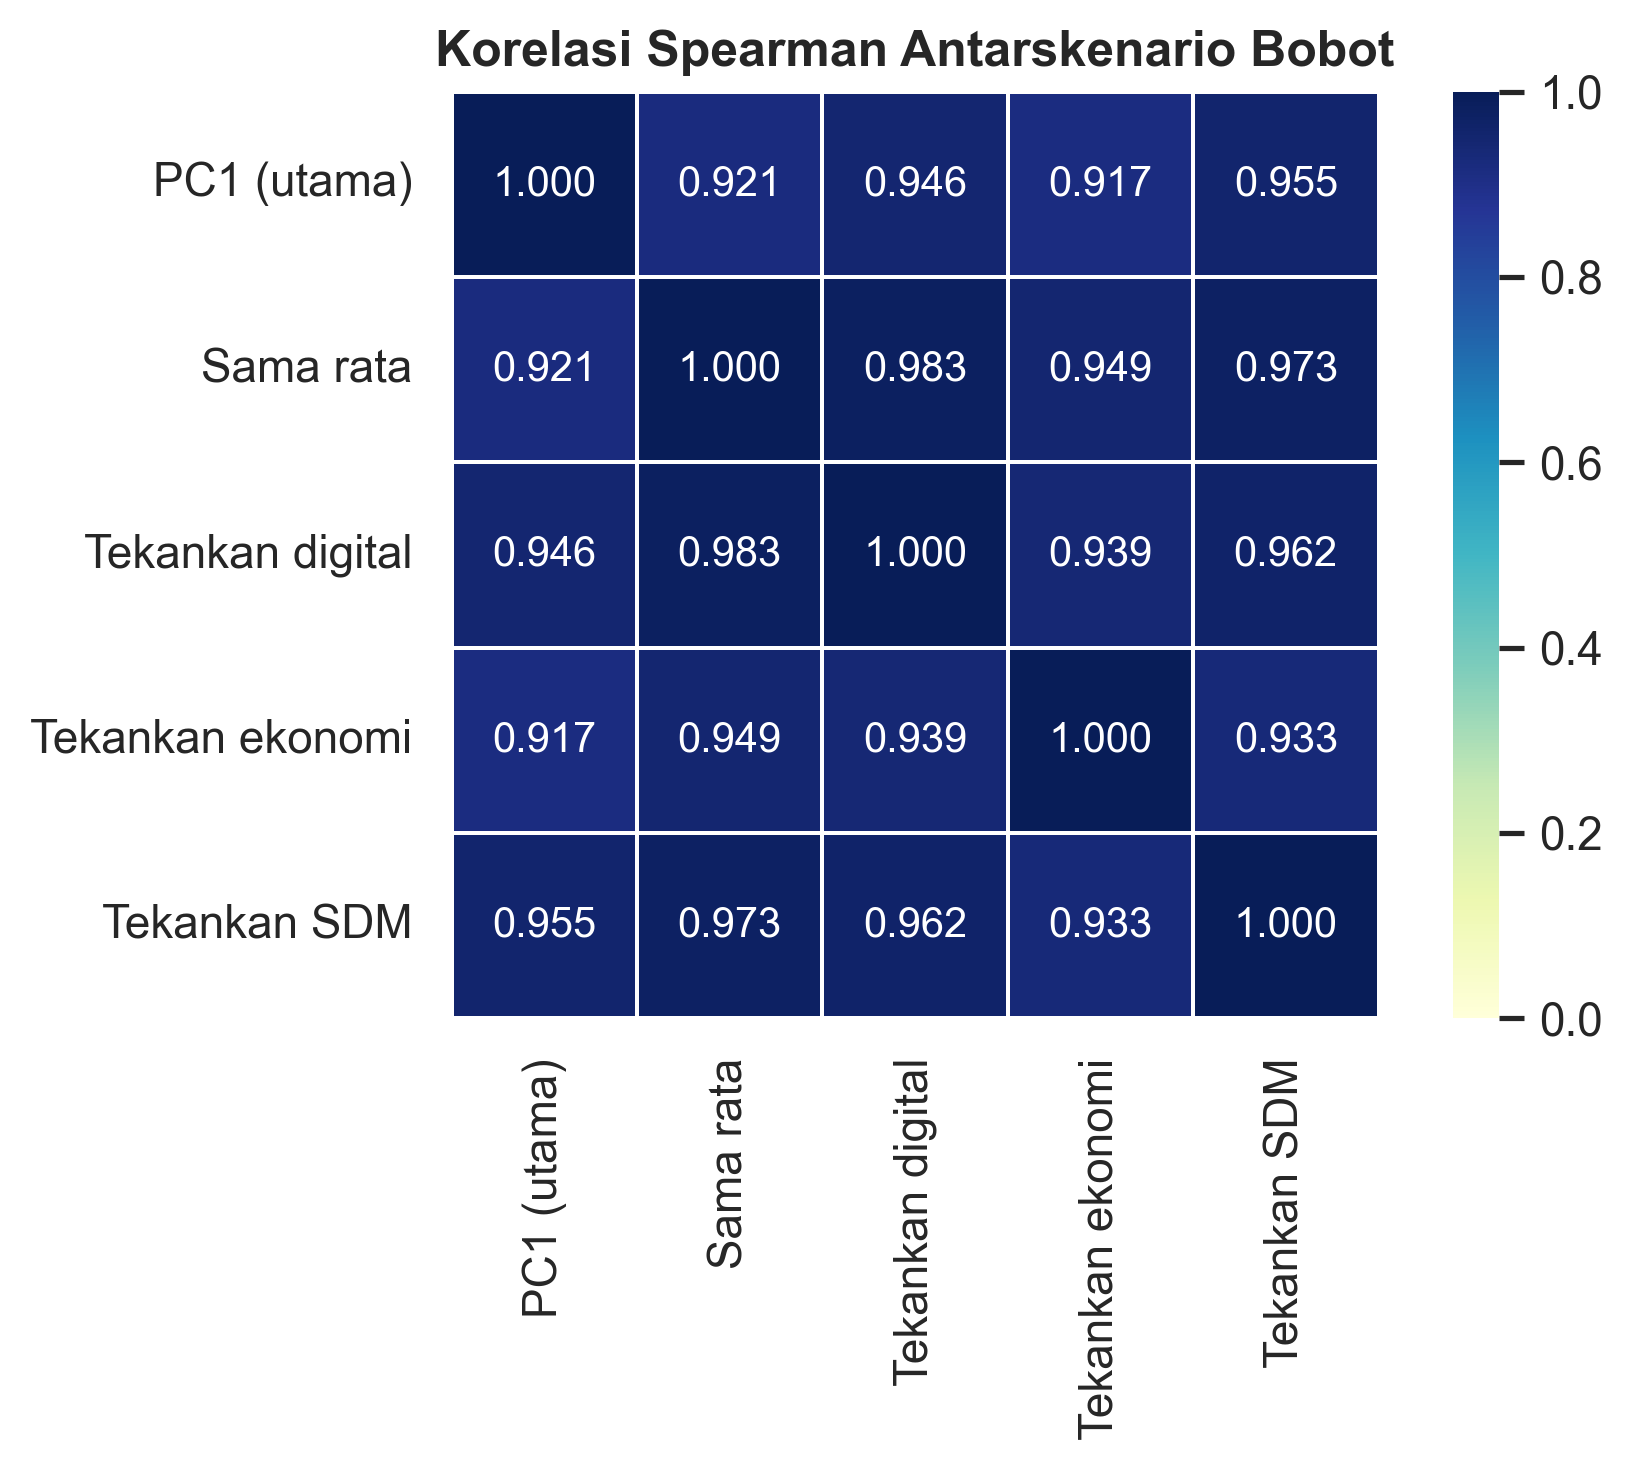

Rata-rata korelasi antarskenario: 0.9478


In [17]:
SKENARIO = {'PC1 (utama)': BOBOT,
            'Sama rata'   : pd.Series(1/5, index=FEATURES),
            'Tekankan digital': pd.Series([.40,.15,.15,.15,.15], index=FEATURES),
            'Tekankan ekonomi': pd.Series([.15,.15,.15,.40,.15], index=FEATURES),
            'Tekankan SDM'    : pd.Series([.15,.30,.25,.15,.15], index=FEATURES)}
pk = pd.DataFrame({'Provinsi': df['Provinsi']})
for n, b in SKENARIO.items():
    pk[n] = (norm*(b/b.sum())).sum(axis=1).rank(ascending=False).astype(int)
kor = pk.drop(columns='Provinsi').corr('spearman')
plt.figure(figsize=(6.5,5))
sns.heatmap(kor, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1, square=True, linewidths=.5)
plt.title('Korelasi Spearman Antarskenario Bobot'); plt.tight_layout(); plt.show()
print(f'Rata-rata korelasi antarskenario: {kor.values[np.triu_indices_from(kor,1)].mean():.4f}')

## 8. Bobot Spasial

Provinsi Indonesia terpisah laut sehingga bobot ketetanggaan menghasilkan wilayah terisolasi.
Digunakan k-nearest neighbours atas sentroid, dengan k dipilih berdasarkan kekuatan
ketergantungan spasial yang terdeteksi pada residual OLS.

In [18]:
from libpysal.weights import KNN, lag_spatial
from spreg import OLS, ML_Lag, ML_Error
import esda
from esda.moran import Moran, Moran_Local

koord = df[['lon','lat']].values
df['pdrb_log'] = np.log1p(df['pdrb_kapita_2024'])
y = df[[Y_COL]].values
XN = ['rls_2024','ipm_2024','pdrb_log','tpt_2024']
X  = df[XN].values

diag = []
for k in range(3, 9):
    wk = KNN.from_array(koord, k=k); wk.transform = 'r'
    o = OLS(y, X, w=wk, spat_diag=True, moran=True)
    diag.append({'k': k, 'Moran z residual': round(o.moran_res[1],3),
                 'p Moran': round(o.moran_res[2],4),
                 'p LM lag': round(o.lm_lag[1],4), 'p LM error': round(o.lm_error[1],4)})
display(pd.DataFrame(diag).set_index('k'))

K_TETANGGA = int(pd.DataFrame(diag).set_index('k')['p Moran'].idxmin())
w = KNN.from_array(koord, k=K_TETANGGA); w.transform = 'r'
print(f'k terpilih = {K_TETANGGA} | wilayah terisolasi: {len(w.islands)}')

,Moran z residual,p Moran,p LM lag,p LM error
k,,,,
3,0.904,0.3657,0.0550,0.7967
4,1.381,0.1673,0.0712,0.5470
5,1.104,0.2696,0.2248,0.7967
6,1.787,0.0739,0.2781,0.4570
7,2.008,0.0446,0.4072,0.4144
8,1.946,0.0517,0.4316,0.4772


k terpilih = 7 | wilayah terisolasi: 0


## 9. Autokorelasi Spasial

In [19]:
baris = []
for c in FEATURES + ['indeks_kerentanan']:
    mi = Moran(df[c].values, w, permutations=999)
    baris.append({'variabel': LABEL.get(c,'Indeks Kerentanan'), "Moran's I": round(mi.I,4),
                  'z': round(mi.z_sim,3), 'p': round(mi.p_sim,4),
                  'pola': 'mengelompok' if (mi.p_sim<.05 and mi.I>mi.EI)
                          else ('menyebar' if mi.p_sim<.05 else 'acak')})
moran_tabel = pd.DataFrame(baris); display(moran_tabel)

,variabel,Moran's I,z,p,pola
0,Kepemilikan Ponsel (%),0.4501,6.913,0.001,mengelompok
1,Rata-rata Lama Sekolah (thn),0.2286,3.702,0.004,mengelompok
2,IPM,0.4872,7.244,0.001,mengelompok
3,PDRB per Kapita (ribu Rp),-0.0697,-0.638,0.274,acak
4,TPT (%),0.1214,1.879,0.055,acak
5,Indeks Kerentanan,0.3402,5.496,0.001,mengelompok


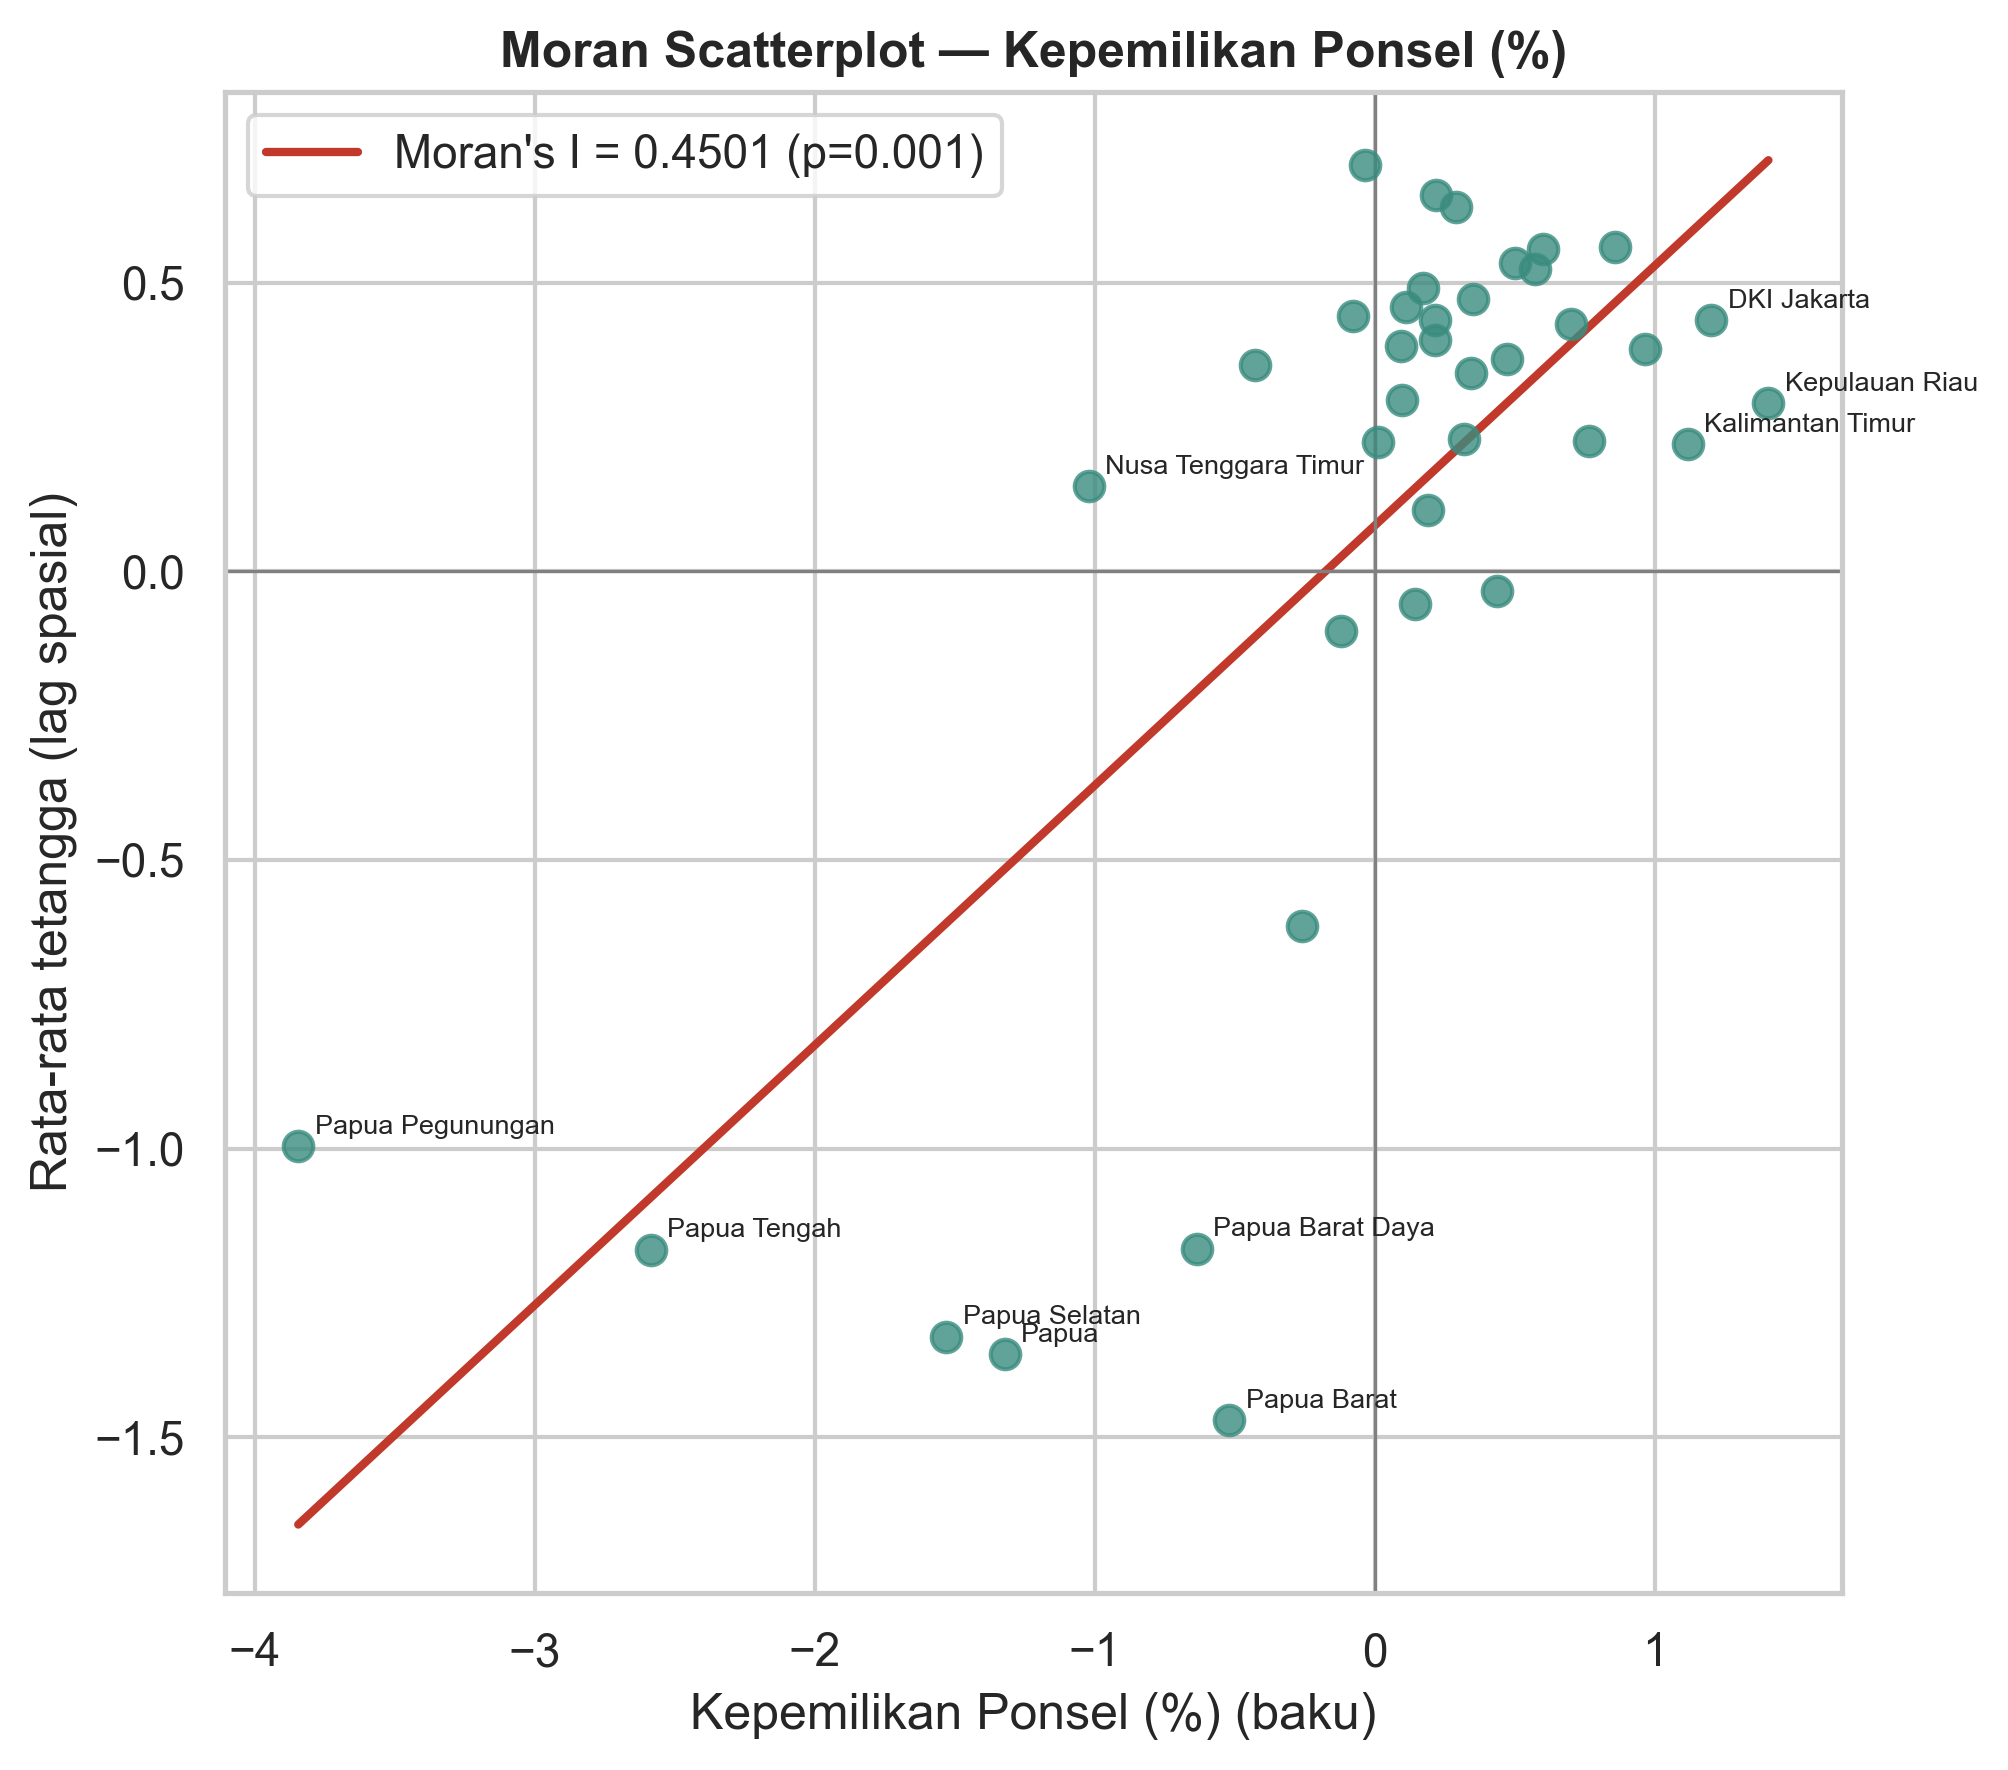

In [20]:
mi_y = Moran(df[Y_COL].values, w, permutations=999)
yz = (df[Y_COL]-df[Y_COL].mean())/df[Y_COL].std()
lz = pd.Series(lag_spatial(w, yz.values))
fig, ax = plt.subplots(figsize=(6.8,6))
ax.scatter(yz, lz, s=50, c='#3A8C7E', alpha=.8, zorder=3)
b_, a_ = np.polyfit(yz, lz, 1); xx = np.linspace(yz.min(), yz.max(), 50)
ax.plot(xx, a_+b_*xx, color='#C0392B', lw=2, label=f"Moran's I = {mi_y.I:.4f} (p={mi_y.p_sim:.3f})")
ax.axhline(0, color='grey', lw=.8); ax.axvline(0, color='grey', lw=.8)
for i,p in enumerate(df['Provinsi']):
    if abs(yz[i])>1 or abs(lz[i])>1:
        ax.annotate(p, (yz[i], lz[i]), fontsize=6.5, textcoords='offset points', xytext=(4,3))
ax.set(xlabel=f'{LABEL[Y_COL]} (baku)', ylabel='Rata-rata tetangga (lag spasial)',
       title=f'Moran Scatterplot — {LABEL[Y_COL]}')
ax.legend(); plt.tight_layout()
fig.savefig('output_svg/02_moran_scatterplot.svg', format='svg', bbox_inches='tight'); plt.show()

In [21]:
lisa = Moran_Local(df[Y_COL].values, w, permutations=999, seed=RANDOM_STATE)
KUAD = {1:'High-High', 2:'Low-High', 3:'Low-Low', 4:'High-Low'}
df['lisa_q'] = [KUAD[q] for q in lisa.q]
df['lisa_p'] = lisa.p_sim
df['lisa'] = np.where(lisa.p_sim < .05, df['lisa_q'], 'Tidak signifikan')
print(df['lisa'].value_counts().to_string(), '\n')
for kat in ['High-High','Low-Low','Low-High','High-Low']:
    a = df.loc[df.lisa==kat,'Provinsi'].tolist()
    if a: print(f'{kat:12s}: {", ".join(a)}')

lisa
Tidak signifikan    24
High-High            7
Low-Low              6
Low-High             1 

High-High   : Lampung, Kepulauan Bangka Belitung, Jawa Barat, Jawa Tengah, DI Yogyakarta, Jawa Timur, Banten
Low-Low     : Papua Barat, Papua Barat Daya, Papua, Papua Tengah, Papua Pegunungan, Papua Selatan
Low-High    : Kalimantan Barat


## 10. Pemodelan Spasial

Enam spesifikasi dibandingkan: OLS, SLX (lag pada peubah penjelas), SAR (lag pada Y),
SEM (lag pada galat), SDM (Spatial Durbin), dan GWR (koefisien yang berubah menurut lokasi).

In [22]:
WX  = np.hstack([lag_spatial(w, X[:,i]).reshape(-1,1) for i in range(X.shape[1])])
XS  = np.hstack([X, WX]); XSN = XN + ['W_'+c for c in XN]

ols = OLS(y, X,  w=w, spat_diag=True, moran=True, name_y=LABEL[Y_COL], name_x=XN,
          name_w=f'KNN-{K_TETANGGA}', name_ds='38 Provinsi 2024')
slx = OLS(y, XS, w=w, spat_diag=True, name_y=LABEL[Y_COL], name_x=XSN)
sar = ML_Lag(y,   X,  w=w, name_y=LABEL[Y_COL], name_x=XN)
sem = ML_Error(y, X,  w=w, name_y=LABEL[Y_COL], name_x=XN)
sdm = ML_Lag(y,   XS, w=w, name_y=LABEL[Y_COL], name_x=XSN)

print('Diagnostik ketergantungan spasial pada residual OLS')
print(f"  Moran's I  : z={ols.moran_res[1]:.4f}  p={ols.moran_res[2]:.4f}")
print(f'  LM lag     : p={ols.lm_lag[1]:.4f}   | Robust LM lag   : p={ols.rlm_lag[1]:.4f}')
print(f'  LM error   : p={ols.lm_error[1]:.4f} | Robust LM error : p={ols.rlm_error[1]:.4f}')
arah = ('SAR' if ols.rlm_lag[1] < ols.rlm_error[1] else 'SEM')
print(f'\nPetunjuk uji LM mengarah ke: {arah}')

Diagnostik ketergantungan spasial pada residual OLS
  Moran's I  : z=2.0084  p=0.0446
  LM lag     : p=0.4072   | Robust LM lag   : p=0.5983
  LM error   : p=0.4144 | Robust LM error : p=0.6123

Petunjuk uji LM mengarah ke: SAR


In [23]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
Xz = (X - X.mean(0)) / X.std(0)
sel = Sel_BW(koord, y, Xz, fixed=False, kernel='bisquare')
BW = sel.search(criterion='AICc', bw_min=14, bw_max=len(df)-1)
gwr = GWR(koord, y, Xz, BW, fixed=False, kernel='bisquare').fit()
print(f'GWR bandwidth adaptif = {BW:.0f} tetangga | ENP = {gwr.ENP:.2f}')

GWR bandwidth adaptif = 36 tetangga | ENP = 8.43


In [24]:
n, kp = len(df), X.shape[1] + 1
aicc = lambda aic, p: aic + 2*p*(p+1)/(n-p-1)
banding = pd.DataFrame([
    {'Model':'OLS', 'AIC':ols.aic, 'AICc':aicc(ols.aic,kp),   'R2/pseudo-R2':ols.r2},
    {'Model':'SLX', 'AIC':slx.aic, 'AICc':aicc(slx.aic,kp+4), 'R2/pseudo-R2':slx.r2},
    {'Model':'SAR', 'AIC':sar.aic, 'AICc':aicc(sar.aic,kp+1), 'R2/pseudo-R2':sar.pr2},
    {'Model':'SEM', 'AIC':sem.aic, 'AICc':aicc(sem.aic,kp+1), 'R2/pseudo-R2':sem.pr2},
    {'Model':'SDM', 'AIC':sdm.aic, 'AICc':aicc(sdm.aic,kp+5), 'R2/pseudo-R2':sdm.pr2},
    {'Model':'GWR', 'AIC':np.nan,  'AICc':gwr.aicc,           'R2/pseudo-R2':gwr.R2},
]).round(3)
display(banding)
terbaik = banding.loc[banding['AICc'].idxmin(), 'Model']
print(f'Model terbaik menurut AICc: {terbaik}')
print(f"Perbaikan R2 terhadap OLS: {(banding.set_index('Model').loc['GWR','R2/pseudo-R2'] - ols.r2)*100:+.2f} poin persentase (GWR)")

,Model,AIC,AICc,R2/pseudo-R2
0,OLS,222.182,224.057,0.905
1,SLX,214.901,221.329,0.936
2,SAR,223.505,226.214,0.907
3,SEM,221.137,223.847,0.904
4,SDM,214.962,223.110,0.942
5,GWR,NaN,208.027,0.957


Model terbaik menurut AICc: GWR
Perbaikan R2 terhadap OLS: +5.20 poin persentase (GWR)


In [25]:
print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :38 Provinsi 2024
Weights matrix      :       KNN-7
Dependent Variable  :Kepemilikan Ponsel (%)                Number of Observations:          38
Mean dependent var  :     65.6497                Number of Variables   :           5
S.D. dependent var  :     12.9773                Degrees of Freedom    :          33
R-squared           :      0.9050
Adjusted R-squared  :      0.8935
Sum squared residual:     591.956                F-statistic           :     78.5935
Sigma-square        :      17.938                Prob(F-statistic)     :   2.161e-16
S.E. of regression  :       4.235                Log likelihood        :    -106.091
Sigma-square ML     :      15.578                Akaike info criterion :     222.182
S.E of regression ML:      3.9469                Schwarz criterion     :     230.369

----------------------------------------------

In [26]:
print(sem.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Kepemilikan Ponsel (%)                Number of Observations:          38
Mean dependent var  :     65.6497                Number of Variables   :           5
S.D. dependent var  :     12.9773                Degrees of Freedom    :          33
Pseudo R-squared    :      0.9036
Log likelihood      :   -105.5687
Sigma-square ML     :     14.8873                Akaike info criterion :     221.137
S.E of regression   :      3.8584                Schwarz criterion     :     229.325

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT       -97

In [27]:
print(gwr.summary)

<bound method GWRResults.summary of <mgwr.gwr.GWRResults object at 0x0000023F6BDF1550>>


In [28]:
lab_x = ['Intersep'] + XN
lok = pd.DataFrame(gwr.params, columns=lab_x)
lok['Provinsi'] = df['Provinsi'].values
tstat = pd.DataFrame(gwr.tvalues, columns=lab_x)
print('Sebaran koefisien lokal GWR:')
display(lok[XN].describe().T[['min','25%','50%','75%','max','std']].round(3))
for c in XN:
    sig = (np.abs(tstat[c]) > 1.96).mean()
    print(f'  {c:12s} signifikan di {sig:.0%} provinsi')
for c in XN:
    df['gwr_'+c] = lok[c].values

Sebaran koefisien lokal GWR:


,min,25%,50%,75%,max,std
rls_2024,-3.003,-2.691,-2.183,-0.522,0.476,1.275
ipm_2024,8.273,8.458,8.998,11.643,12.479,1.698
pdrb_log,0.538,0.992,1.977,2.408,2.776,0.724
tpt_2024,-0.124,0.299,0.444,0.507,0.722,0.228


  rls_2024     signifikan di 0% provinsi
  ipm_2024     signifikan di 100% provinsi
  pdrb_log     signifikan di 63% provinsi
  tpt_2024     signifikan di 0% provinsi


## 11. Peta

Seluruh peta disimpan sebagai **SVG vektor** di folder `output_svg/`, siap dibuka
di Figma, Illustrator, atau Inkscape untuk pewarnaan ulang tanpa kehilangan ketajaman.

In [29]:
TEAL  = LinearSegmentedColormap.from_list('teal',  ['#F2F7F5','#BFE0D8','#79BFB0','#3A8C7E','#1B4F45'])
EMBER = LinearSegmentedColormap.from_list('ember', ['#FFF6E8','#FFD79A','#F79A4C','#D9531E','#8C2408'])
TINTA, KABUT, GARIS, LATAR = '#1A1A1A', '#6B7280', '#FFFFFF', '#E8EAED'
JAWA = ['DKI Jakarta','Jawa Barat','Jawa Tengah','DI Yogyakarta','Jawa Timur','Banten','Bali']
GESER = {'Papua Tengah':(-30,26), 'Papua Pegunungan':(34,-6), 'Papua Selatan':(10,-22),
         'DKI Jakarta':(-46,20), 'Kepulauan Riau':(16,20), 'Kalimantan Utara':(34,14)}

if GADM_AKTIF:
    # Provinsi pemekaran digabung ke induknya; numerik dirata-rata,
    # kategori (klaster/LISA) memakai modus (nilai terbanyak) di antara pemekarannya.
    FORCE_KATEGORI = {'klaster', 'nama_klaster', 'lisa_q', 'lisa', 'kategori'}
    _num = [c for c in df.select_dtypes(include=[np.number]).columns if c not in FORCE_KATEGORI]
    _kat = [c for c in df.columns if c not in _num + ['Provinsi'] and c not in ('lat', 'lon')]

    _tmp = df.copy()
    _tmp['_geo_key'] = _tmp['Provinsi'].replace(GADM_MERGE)
    _agg = {c: 'mean' for c in _num}
    _agg.update({c: (lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]) for c in _kat})
    _dagg = _tmp.groupby('_geo_key').agg(_agg).reset_index().rename(columns={'_geo_key': 'Provinsi'})

    peta = geo.merge(_dagg, left_on='PROVINSI', right_on='Provinsi', how='left').to_crs(3857)
    print('Peta memakai batas GADM 34-provinsi. Nilai Papua/Papua Barat pada peta adalah '
          'rata-rata (numerik) atau modus (kategori) dari provinsi-provinsi pemekarannya — '
          'lihat df asli untuk nilai 38-provinsi yang tidak digabung.')
else:
    peta = geo.merge(df, left_on='PROVINSI', right_on='Provinsi', how='left').to_crs(3857)

def _rangka(fig, ax, gdf, judul, subjudul, sumber):
    ax.set_axis_off()
    b = gdf.total_bounds
    ax.set_xlim(b[0]-3.0e5, b[2]+9.0e5); ax.set_ylim(b[1]-1.35e6, b[3]+2.0e5)
    fig.text(.02,.955, judul, fontsize=17, fontweight='bold', color=TINTA)
    fig.text(.02,.905, subjudul, fontsize=10.5, color=KABUT)
    fig.text(.02,.035, sumber, fontsize=7.5, color=KABUT, style='italic')
    fig.text(.98,.035, 'IRIS Tempu . NSIC EPSILON 2026', fontsize=7.5,
             color=KABUT, ha='right', style='italic')

def _sisipan(ax, gdf, gambar, teks):
    iax = ax.inset_axes([.010,.005,.325,.245])
    gambar(iax)
    jb = gdf[gdf.PROVINSI.isin(JAWA)].total_bounds
    iax.set_xlim(jb[0]-6e4, jb[2]+6e4); iax.set_ylim(jb[1]-6e4, jb[3]+6e4)
    iax.set_xticks([]); iax.set_yticks([]); iax.set_facecolor('white')
    for s in iax.spines.values(): s.set_edgecolor('#C9CDD3'); s.set_linewidth(.8)
    iax.set_title('Jawa & Bali (perbesaran)', fontsize=7, color=KABUT, pad=3)
    for _, r in gdf[gdf.PROVINSI.isin(JAWA)].iterrows():
        c = r.geometry.representative_point()
        iax.annotate(teks(r), xy=(c.x,c.y), ha='center', va='center', fontsize=5.1, color=TINTA,
                     bbox=dict(boxstyle='round,pad=.16', fc='white', ec='#D0D5DB', lw=.4, alpha=.9))

def peta_numerik(gdf, kolom, judul, subjudul, cmap, sumber, nama_berkas,
                 satuan='', nama_legenda=None, k=5, n_label=4, terbalik=False):
    v = gdf[kolom].dropna()
    batas = [v.min()] + list(mapclassify.classify(v.values,'NaturalBreaks',k=k).bins)
    norm_b = BoundaryNorm(batas, cmap.N)
    fig = plt.figure(figsize=(15,7.2)); fig.patch.set_facecolor('#FCFCFC')
    ax = fig.add_axes([.02,.10,.96,.76])
    gdf.plot(ax=ax, color=LATAR, edgecolor=GARIS, lw=.5, zorder=1)
    gdf.plot(ax=ax, column=kolom, cmap=cmap, norm=norm_b, edgecolor=GARIS, lw=.55, zorder=2,
             missing_kwds={'color':LATAR,'hatch':'///','edgecolor':'#C9CDD3'})
    u = gdf.sort_values(kolom, ascending=terbalik)
    for _, r in pd.concat([u.head(n_label), u.tail(n_label)]).iterrows():
        if pd.isna(r[kolom]): continue
        c = r.geometry.representative_point()
        ax.annotate(f"{r['PROVINSI']}\n{r[kolom]:,.1f}{satuan}", xy=(c.x,c.y),
                    xytext=GESER.get(r['PROVINSI'],(0,0)), textcoords='offset points',
                    ha='center', va='center', fontsize=6.6, color=TINTA, zorder=5,
                    bbox=dict(boxstyle='round,pad=.28', fc='white', ec='#D0D5DB', lw=.5, alpha=.92))
    _sisipan(ax, gdf,
             lambda a: gdf.plot(ax=a, column=kolom, cmap=cmap, norm=norm_b, edgecolor=GARIS,
                                lw=.5, missing_kwds={'color':LATAR}),
             lambda r: f"{r['PROVINSI'][:13]}\n{r[kolom]:,.1f}")
    _rangka(fig, ax, gdf, judul, subjudul, sumber)
    kax = fig.add_axes([.375,.115,.245,.019])
    cb = mpl.colorbar.ColorbarBase(kax, cmap=cmap, norm=norm_b, orientation='horizontal',
                                   ticks=batas, spacing='proportional')
    cb.ax.set_xticklabels([f'{x:,.0f}' for x in batas], fontsize=7.2, color=KABUT)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, pad=2)
    kax.set_title(nama_legenda or LABEL.get(kolom, kolom), fontsize=7.6, color=KABUT, pad=5, loc='left')
    fig.savefig(f'output_svg/{nama_berkas}.svg', format='svg', bbox_inches='tight',
                facecolor=fig.get_facecolor())
    fig.savefig(f'output_svg/{nama_berkas}.png', dpi=170, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    return fig

def peta_kategori(gdf, kolom, judul, subjudul, warna_kat, sumber, nama_berkas):
    kats = [k for k in warna_kat if k in set(gdf[kolom].dropna())]
    cmap = ListedColormap([warna_kat[k] for k in kats])
    gdf = gdf.copy(); gdf['_k'] = pd.Categorical(gdf[kolom], categories=kats, ordered=True)
    fig = plt.figure(figsize=(15,7.2)); fig.patch.set_facecolor('#FCFCFC')
    ax = fig.add_axes([.02,.10,.96,.76])
    gdf.plot(ax=ax, color=LATAR, edgecolor=GARIS, lw=.5, zorder=1)
    gdf.plot(ax=ax, column='_k', cmap=cmap, edgecolor=GARIS, lw=.55, zorder=2,
             missing_kwds={'color':LATAR,'hatch':'///','edgecolor':'#C9CDD3'})
    _sisipan(ax, gdf,
             lambda a: gdf.plot(ax=a, column='_k', cmap=cmap, edgecolor=GARIS, lw=.5,
                                missing_kwds={'color':LATAR}),
             lambda r: f"{r['PROVINSI'][:13]}")
    _rangka(fig, ax, gdf, judul, subjudul, sumber)
    tangan = [plt.Rectangle((0,0),1,1, fc=warna_kat[k], ec='white') for k in kats]
    ax.legend(tangan, kats, loc='lower left', bbox_to_anchor=(.36,.02), frameon=False,
              fontsize=8.5, title='Kategori', title_fontsize=8, ncol=1)
    fig.savefig(f'output_svg/{nama_berkas}.svg', format='svg', bbox_inches='tight',
                facecolor=fig.get_facecolor())
    fig.savefig(f'output_svg/{nama_berkas}.png', dpi=170, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    return fig

print('Fungsi peta siap.')

Fungsi peta siap.


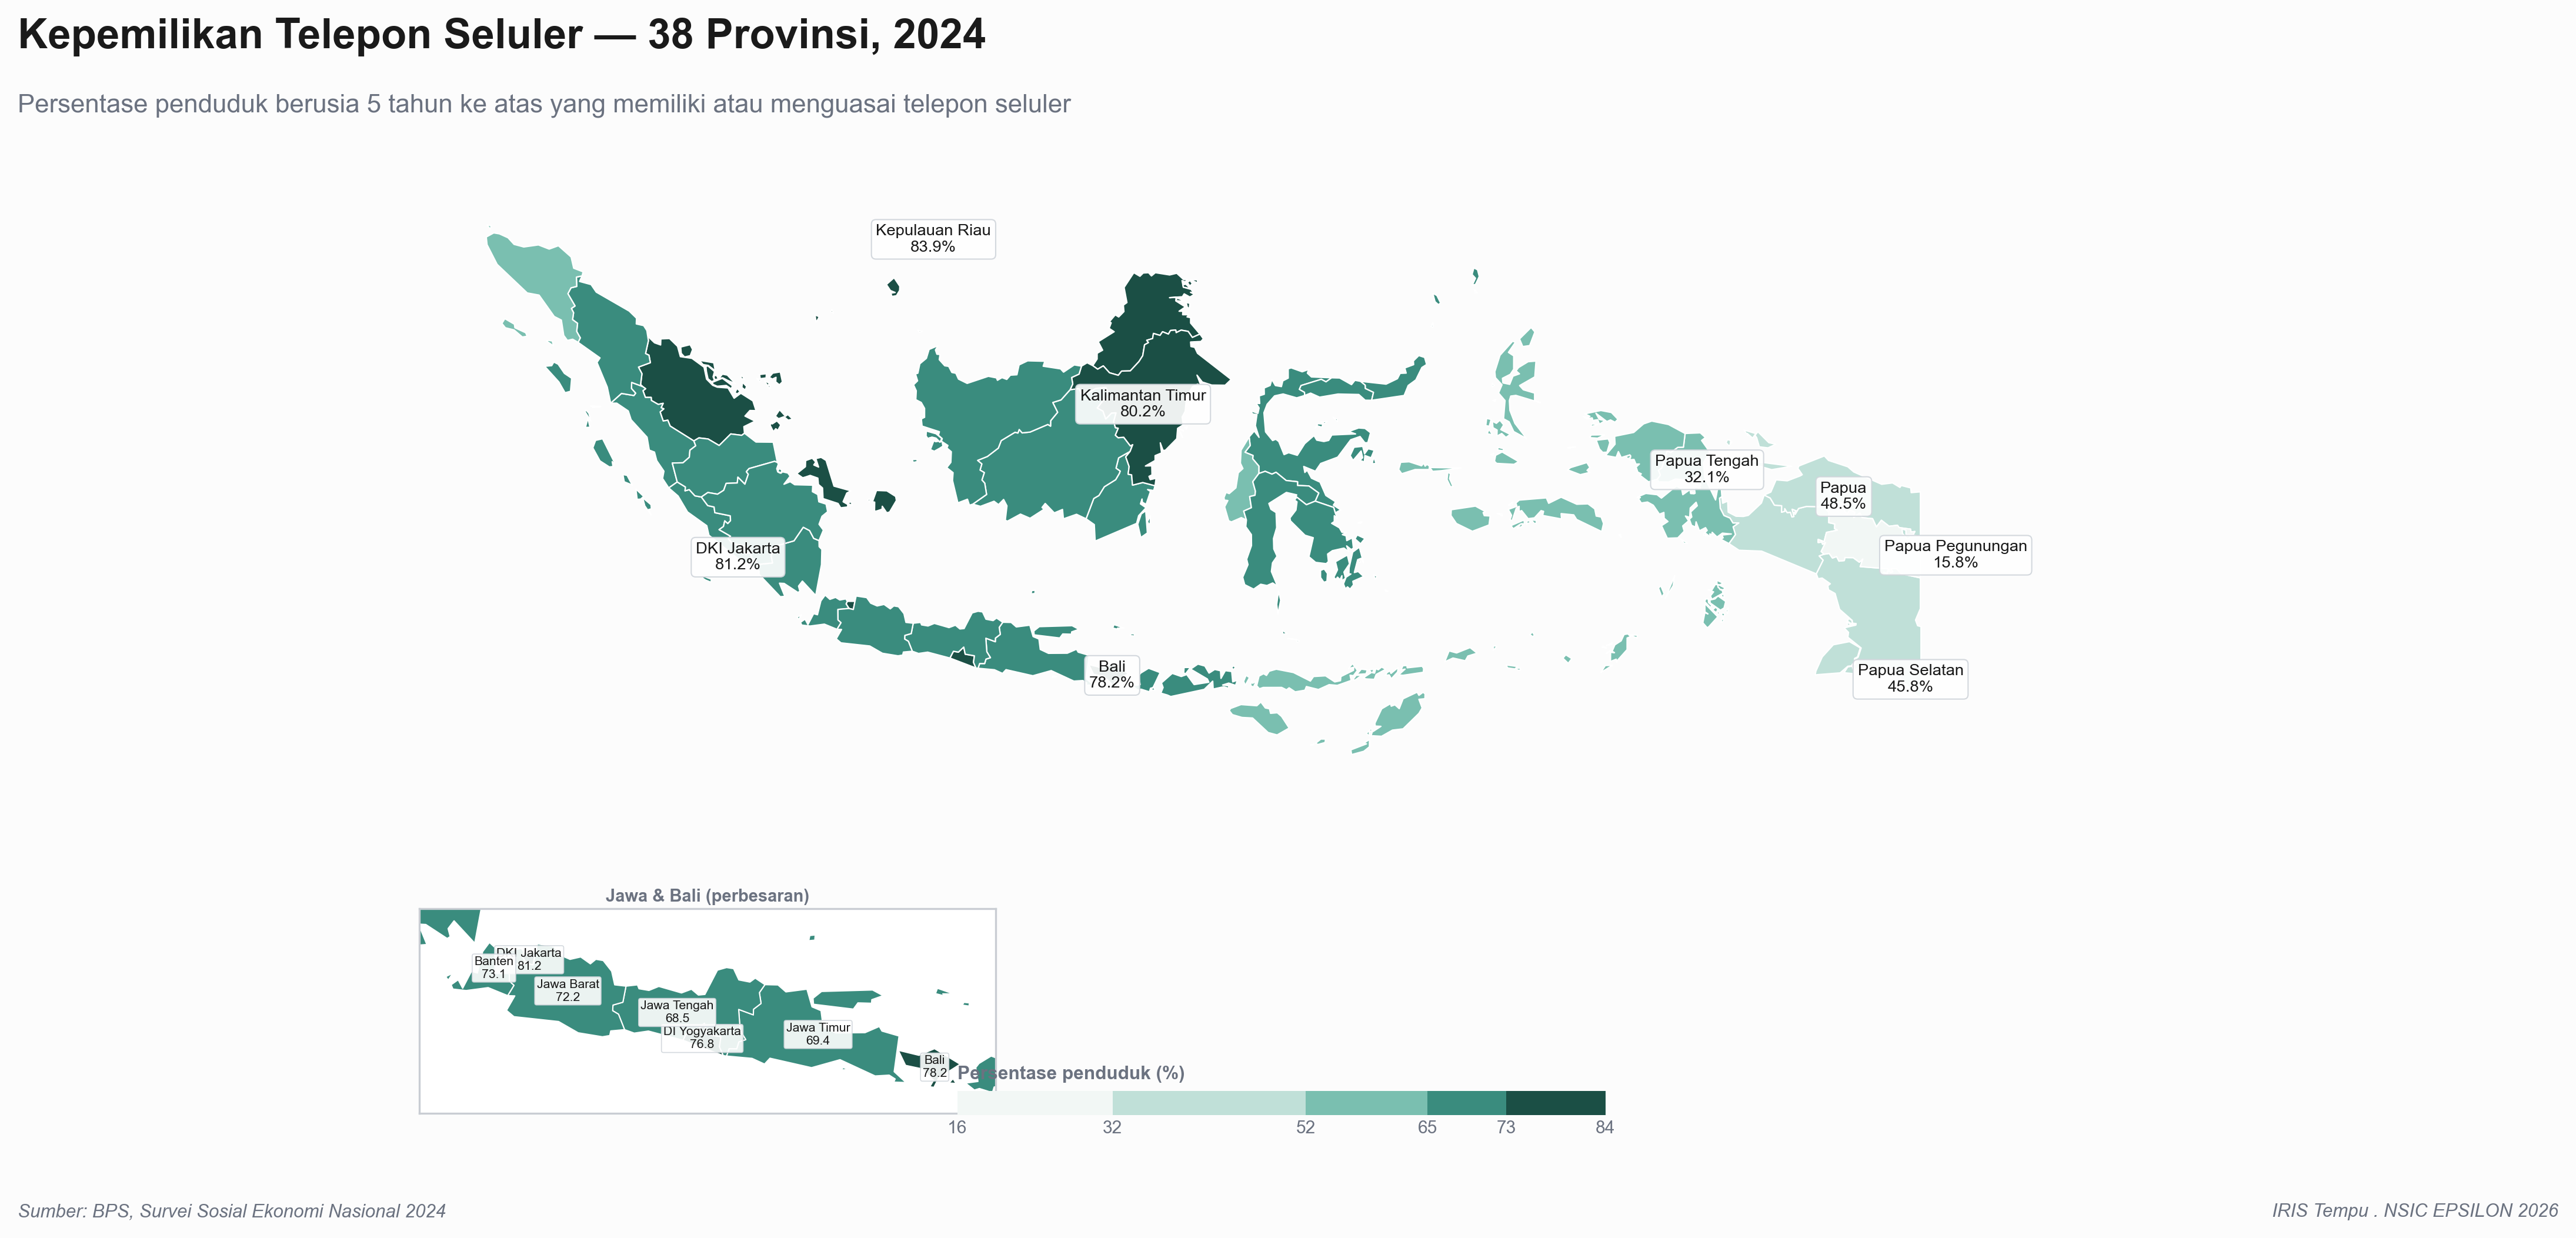

In [30]:
peta_numerik(peta, 'hp_seluler_2024',
    'Kepemilikan Telepon Seluler — 38 Provinsi, 2024',
    'Persentase penduduk berusia 5 tahun ke atas yang memiliki atau menguasai telepon seluler',
    TEAL, 'Sumber: BPS, Survei Sosial Ekonomi Nasional 2024', '03_peta_kepemilikan_ponsel',
    satuan='%', nama_legenda='Persentase penduduk (%)')
plt.show()

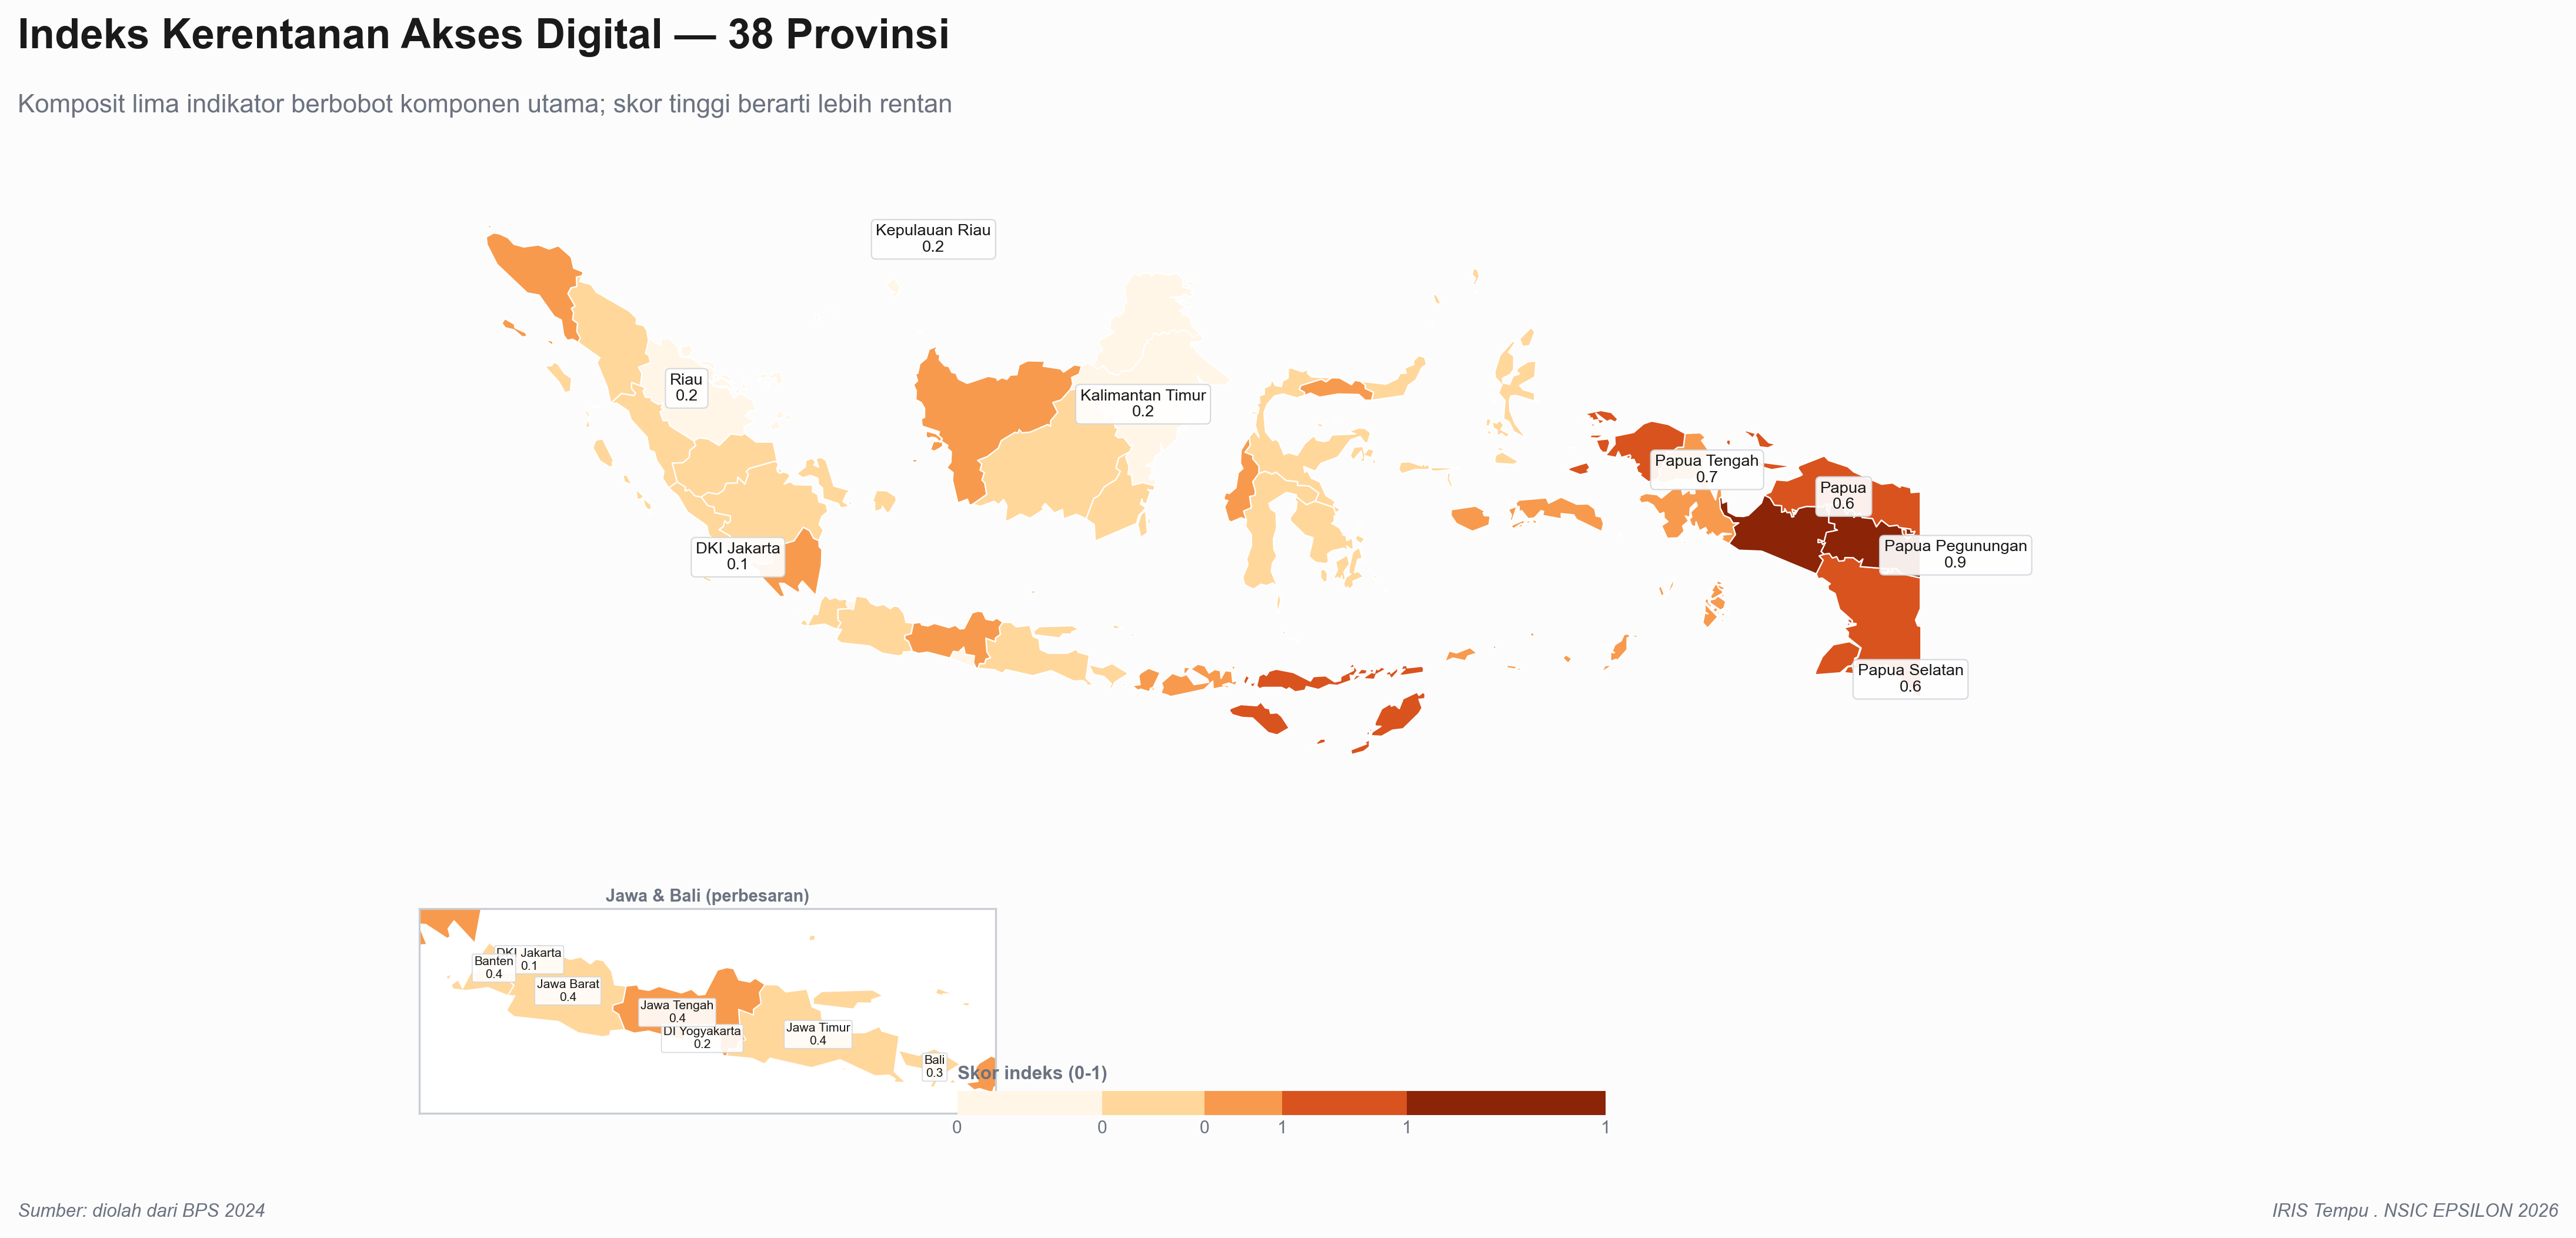

In [31]:
peta_numerik(peta, 'indeks_kerentanan',
    'Indeks Kerentanan Akses Digital — 38 Provinsi',
    'Komposit lima indikator berbobot komponen utama; skor tinggi berarti lebih rentan',
    EMBER, 'Sumber: diolah dari BPS 2024', '04_peta_indeks_kerentanan',
    nama_legenda='Skor indeks (0-1)', terbalik=True)
plt.show()

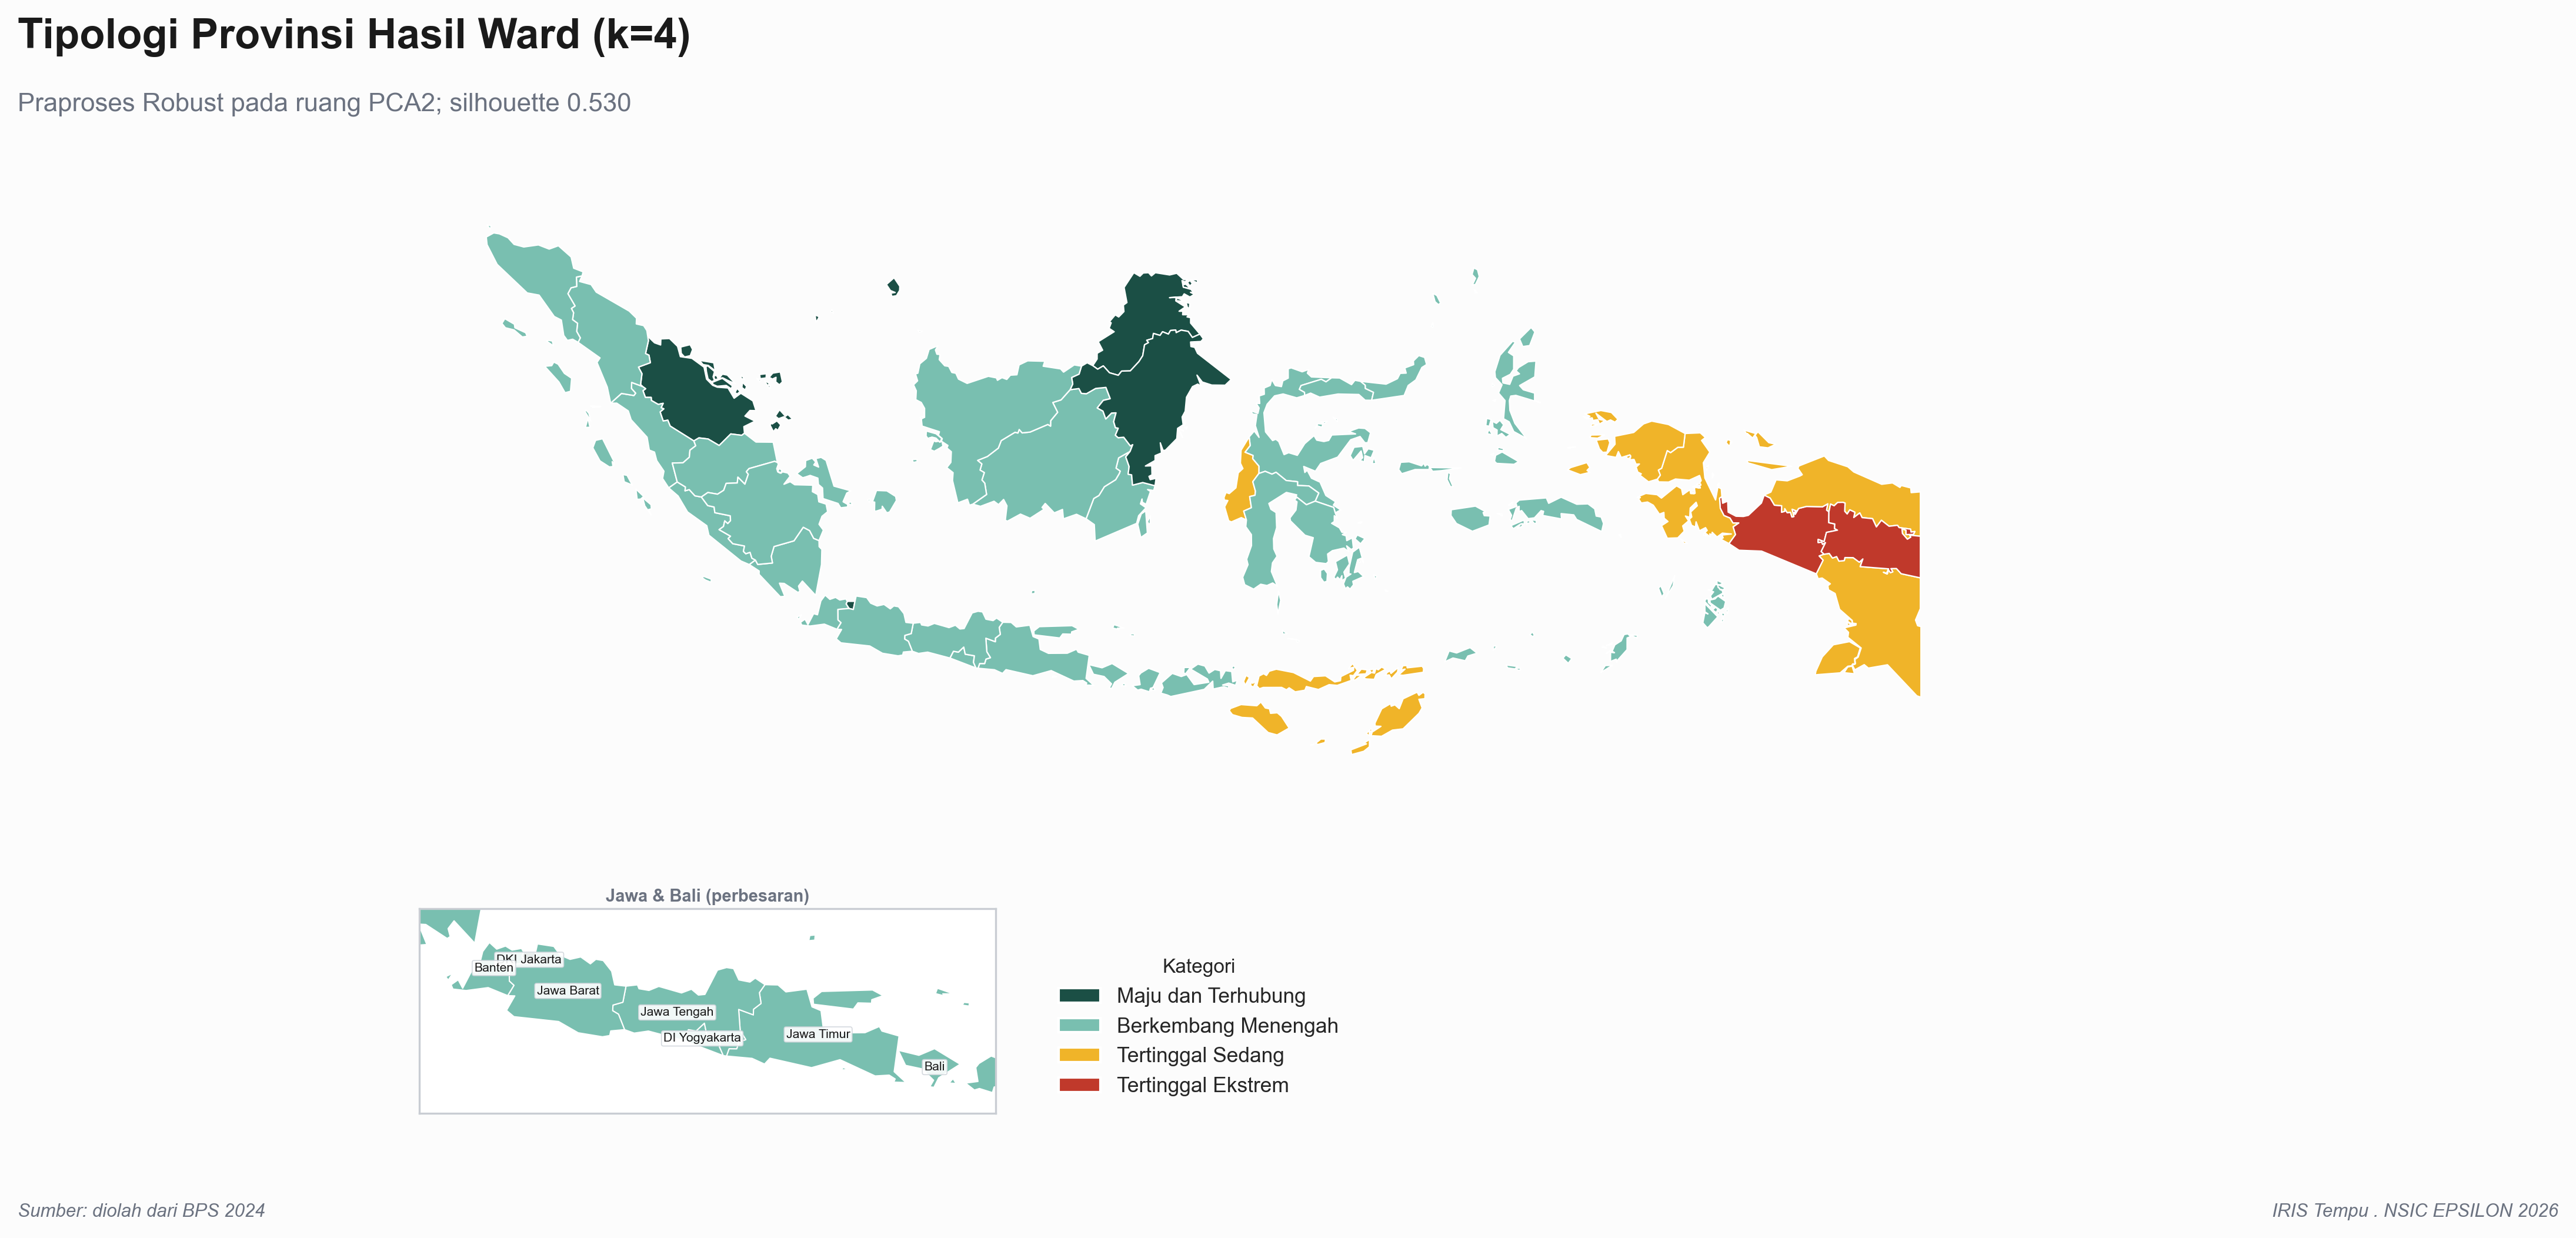

In [32]:
WARNA_KLASTER = {PETA_NAMA[k]: c for k, c in
                 zip(urut, ['#1B4F45','#79BFB0','#F0B429','#C0392B','#7F8C8D','#8E44AD'])}
peta_kategori(peta, 'nama_klaster',
    f'Tipologi Provinsi Hasil {ALGO_PILIH} (k={K_OPT})',
    f'Praproses {SKEMA_PILIH} pada ruang {RUANG_PILIH}; silhouette {juara.silhouette:.3f}',
    WARNA_KLASTER, 'Sumber: diolah dari BPS 2024', '05_peta_klaster')
plt.show()

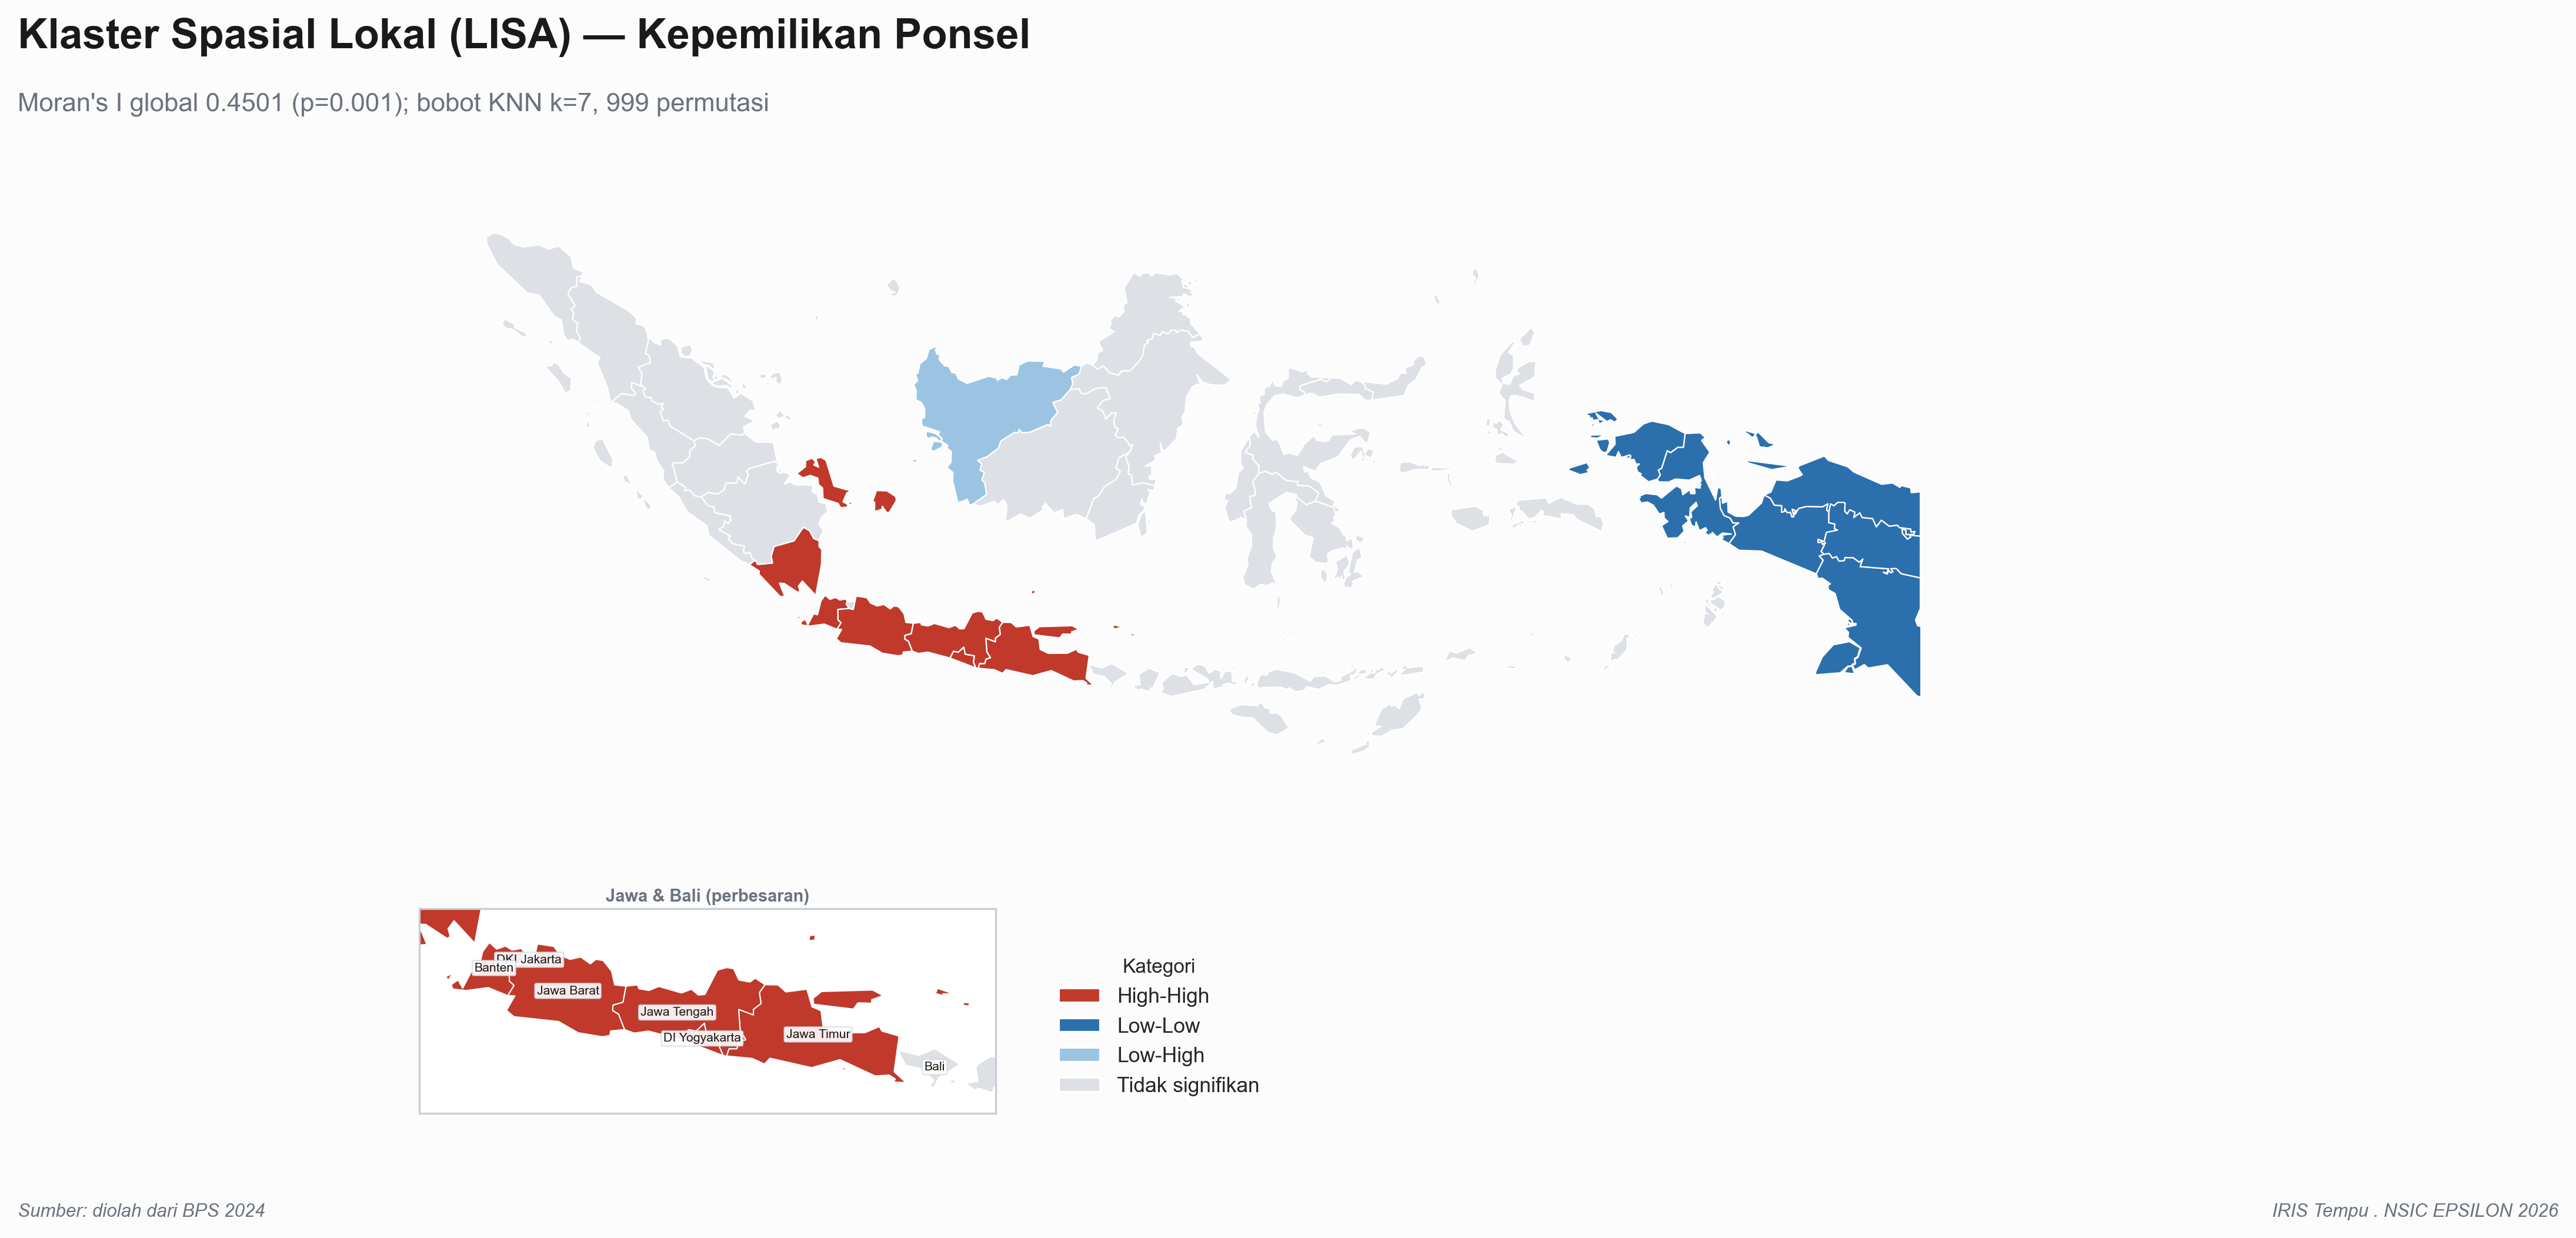

In [33]:
WARNA_LISA = {'High-High':'#C0392B', 'Low-Low':'#2C6FAD',
              'Low-High':'#9BC4E2', 'High-Low':'#E8A33D', 'Tidak signifikan':'#DDE1E6'}
peta_kategori(peta, 'lisa',
    "Klaster Spasial Lokal (LISA) — Kepemilikan Ponsel",
    f"Moran's I global {mi_y.I:.4f} (p={mi_y.p_sim:.3f}); bobot KNN k={K_TETANGGA}, 999 permutasi",
    WARNA_LISA, 'Sumber: diolah dari BPS 2024', '06_peta_lisa')
plt.show()

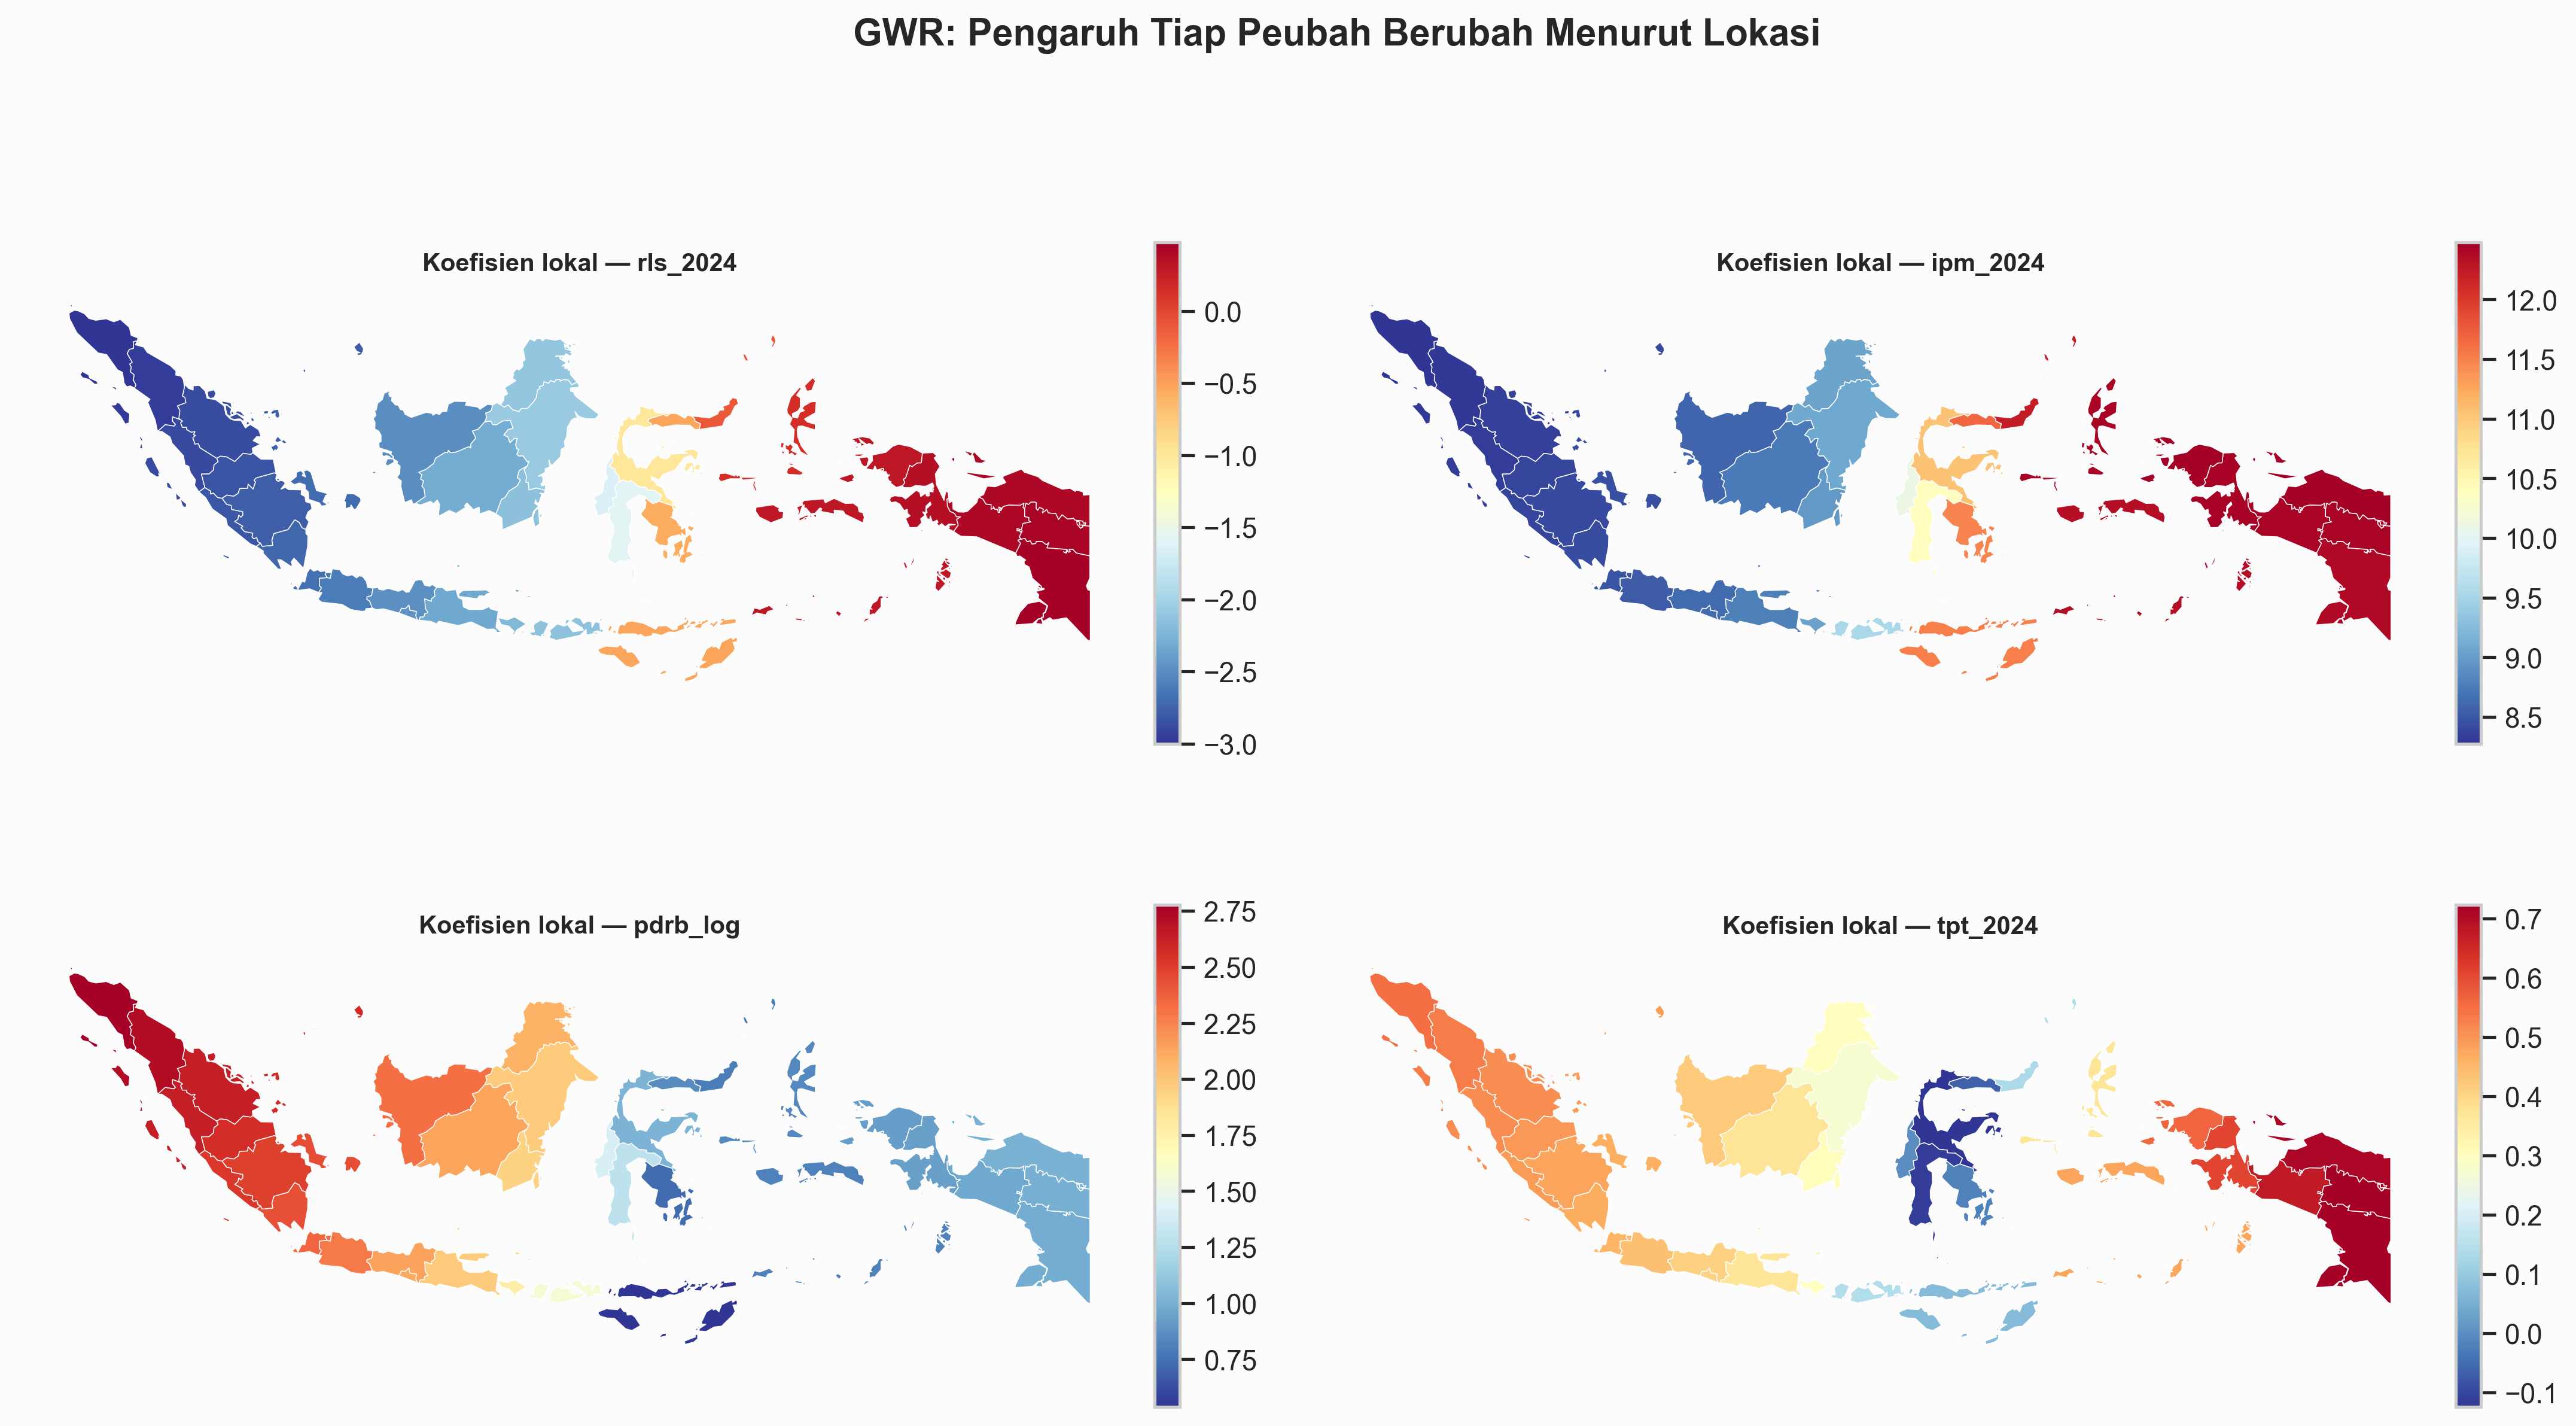

In [34]:
# Peta koefisien lokal GWR — memperlihatkan bahwa pengaruh tiap peubah berbeda antarwilayah
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.patch.set_facecolor('#FCFCFC')
for ax, c in zip(axes.ravel(), XN):
    peta.plot(ax=ax, column='gwr_'+c, cmap='RdYlBu_r', edgecolor='white', lw=.35,
              legend=True, legend_kwds={'shrink':.6, 'pad':.01})
    ax.set_axis_off(); ax.set_title(f'Koefisien lokal — {c}', fontsize=10)
fig.suptitle('GWR: Pengaruh Tiap Peubah Berubah Menurut Lokasi', fontsize=15, fontweight='bold')
plt.tight_layout()
fig.savefig('output_svg/07_peta_gwr_koefisien.svg', format='svg', bbox_inches='tight',
            facecolor=fig.get_facecolor())
fig.savefig('output_svg/07_peta_gwr_koefisien.png', dpi=170, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 11B. Peta Klaster Polos untuk Kebutuhan Desain

Peta versi bersih: **warna saja**, tanpa judul, label, legenda, maupun catatan sumber.
Latar dibuat transparan sehingga bisa langsung ditumpuk di Figma, Illustrator, atau Canva.

Ubah `PALET_KLASTER` di bawah untuk mengganti warna tiap klaster. Kuncinya adalah nama klaster
yang dihasilkan Bagian 5; nilainya kode heksadesimal apa pun.

In [35]:
# ----------------------------------------------------------------------
# UBAH DI SINI — satu warna untuk tiap klaster
# ----------------------------------------------------------------------
PALET_KLASTER = {
    'Maju dan Terhubung' : '#1B4F45',
    'Berkembang Menengah': '#79BFB0',
    'Tertinggal Sedang'  : '#F0B429',
    'Tertinggal Ekstrem' : '#C0392B',
    'Klaster E'          : '#7F8C8D',
    'Klaster F'          : '#8E44AD',
}
WARNA_KOSONG = '#E8EAED'   # untuk provinsi tanpa data
# ----------------------------------------------------------------------

hilang = [n for n in df['nama_klaster'].dropna().unique() if n not in PALET_KLASTER]
if hilang:
    print('Belum diberi warna:', hilang)
else:
    print('Semua klaster sudah punya warna.')
for n in df['nama_klaster'].dropna().unique():
    print(f'  {n:22s} {PALET_KLASTER[n]}   n={int((df.nama_klaster==n).sum())}')

Semua klaster sudah punya warna.
  Berkembang Menengah    #79BFB0   n=25
  Maju dan Terhubung     #1B4F45   n=5
  Tertinggal Sedang      #F0B429   n=6
  Tertinggal Ekstrem     #C0392B   n=2


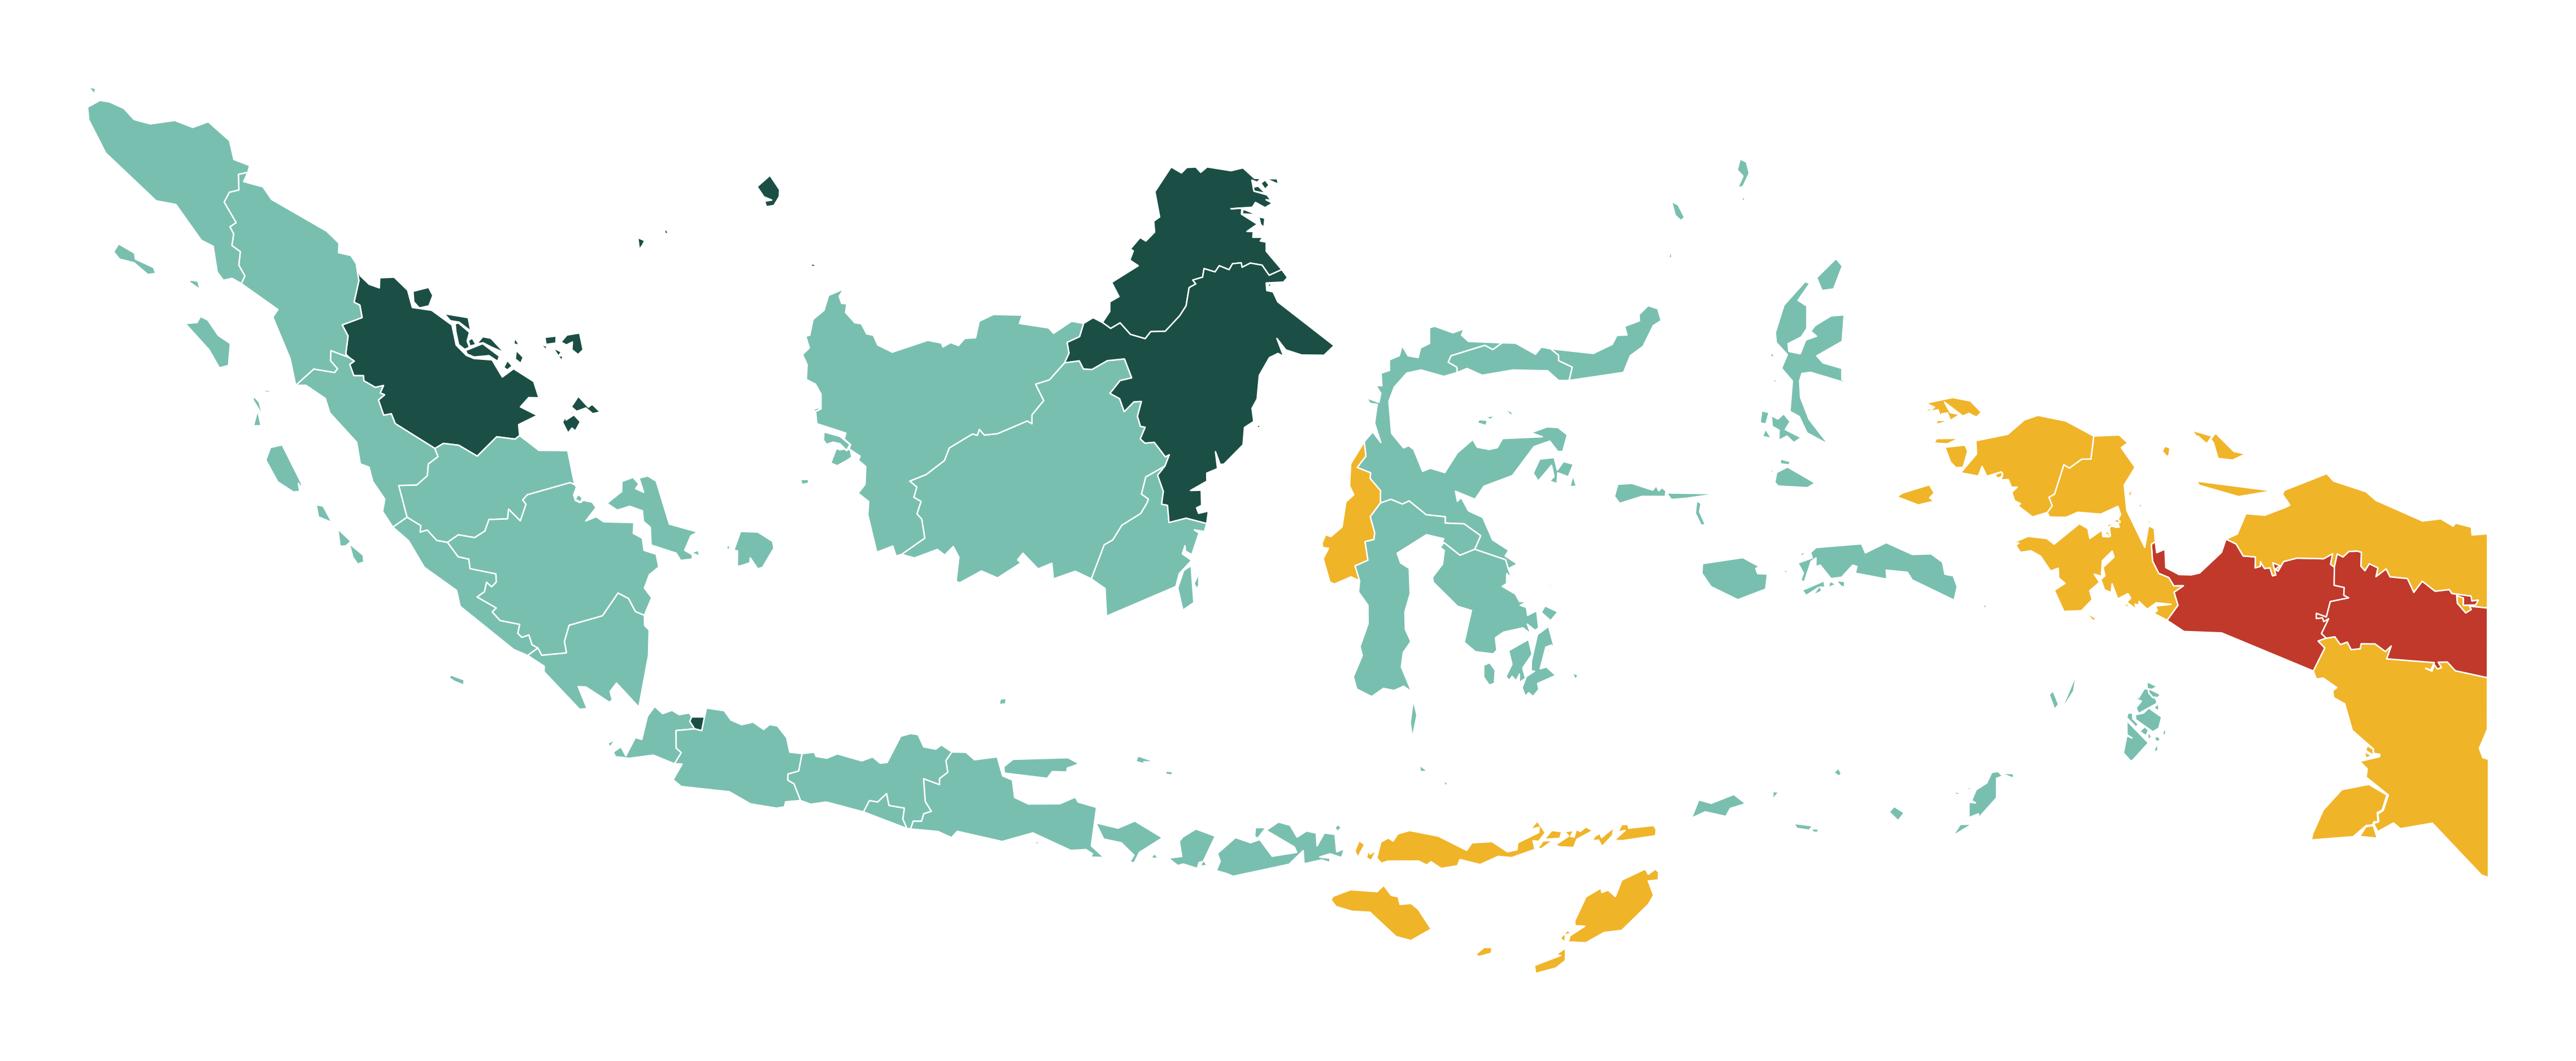

In [36]:
def peta_polos(gdf, kolom, palet, nama_berkas,
               garis='#FFFFFF', lebar_garis=0.6, warna_kosong=WARNA_KOSONG,
               latar=None, ukuran=(15, 7.2), sisipan_jawa=False, simpan_png=True):
    """Peta kategori tanpa teks apa pun. latar=None berarti transparan."""
    g2 = gdf.copy()
    g2['_warna'] = g2[kolom].map(palet).fillna(warna_kosong)

    fig = plt.figure(figsize=ukuran)
    if latar:
        fig.patch.set_facecolor(latar)
    else:
        fig.patch.set_alpha(0.0)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.patch.set_alpha(0.0)

    g2.plot(ax=ax, color=g2['_warna'], edgecolor=garis, linewidth=lebar_garis)
    ax.set_axis_off()
    b = g2.total_bounds
    ax.set_xlim(b[0] - 1.5e5, b[2] + 1.5e5)
    ax.set_ylim(b[1] - (1.05e6 if sisipan_jawa else 1.5e5), b[3] + 1.5e5)

    if sisipan_jawa:
        iax = ax.inset_axes([0.012, 0.01, 0.30, 0.24])
        g2.plot(ax=iax, color=g2['_warna'], edgecolor=garis, linewidth=lebar_garis)
        jb = g2[g2.PROVINSI.isin(JAWA)].total_bounds
        iax.set_xlim(jb[0] - 6e4, jb[2] + 6e4); iax.set_ylim(jb[1] - 6e4, jb[3] + 6e4)
        iax.set_xticks([]); iax.set_yticks([]); iax.patch.set_alpha(0.0)
        for sp in iax.spines.values():
            sp.set_visible(False)

    fig.savefig(f'output_svg/{nama_berkas}.svg', format='svg',
                bbox_inches='tight', pad_inches=0, transparent=(latar is None),
                facecolor=fig.get_facecolor() if latar else 'none')
    if simpan_png:
        fig.savefig(f'output_svg/{nama_berkas}.png', dpi=200,
                    bbox_inches='tight', pad_inches=0, transparent=(latar is None))
    return fig

peta_polos(peta, 'nama_klaster', PALET_KLASTER, '08_klaster_polos')
plt.show()

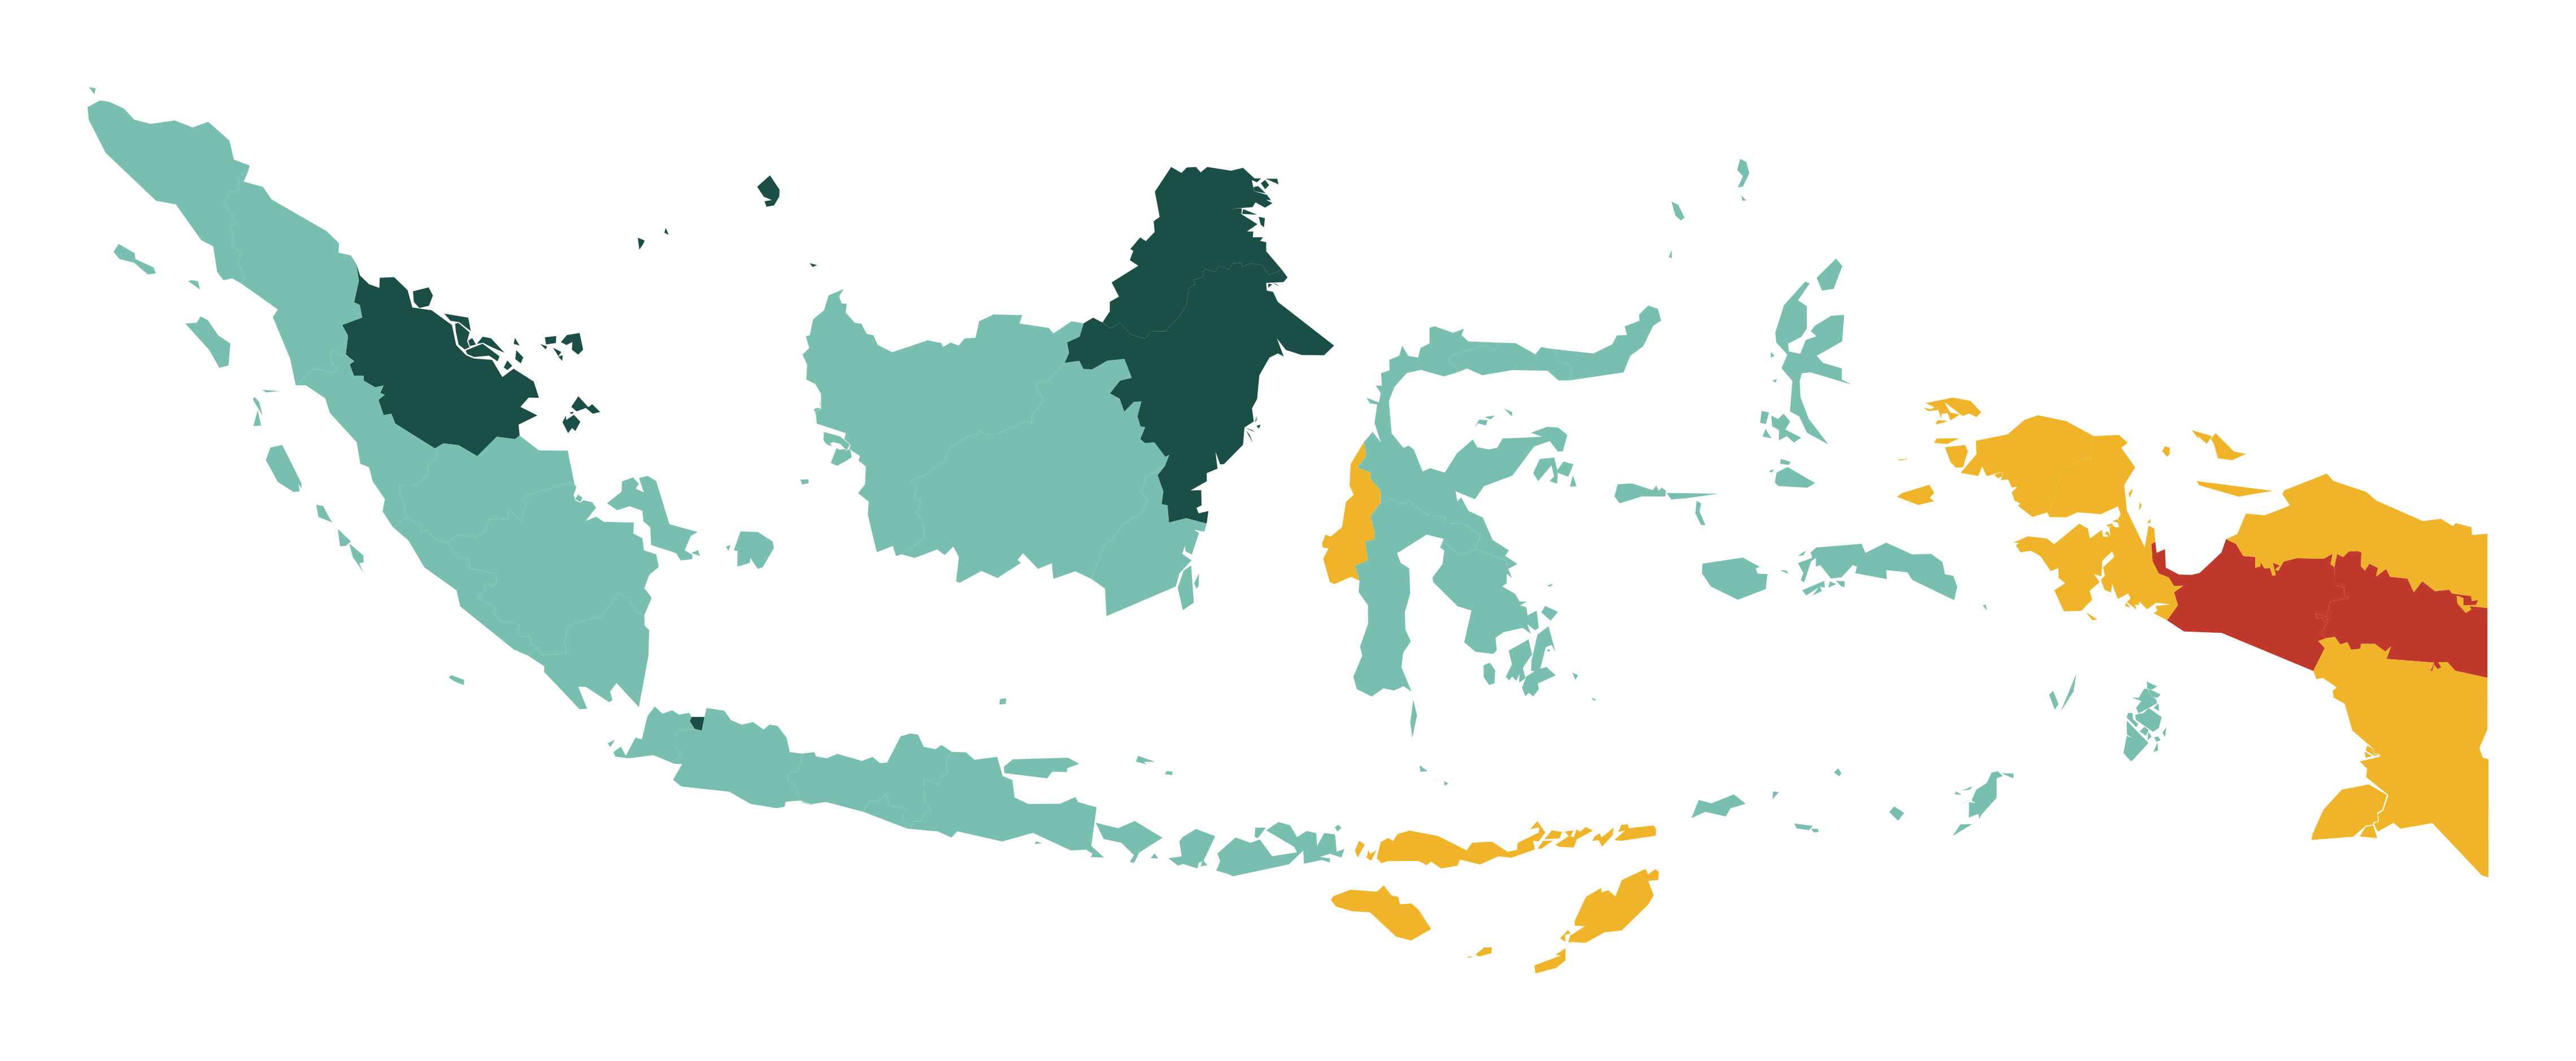

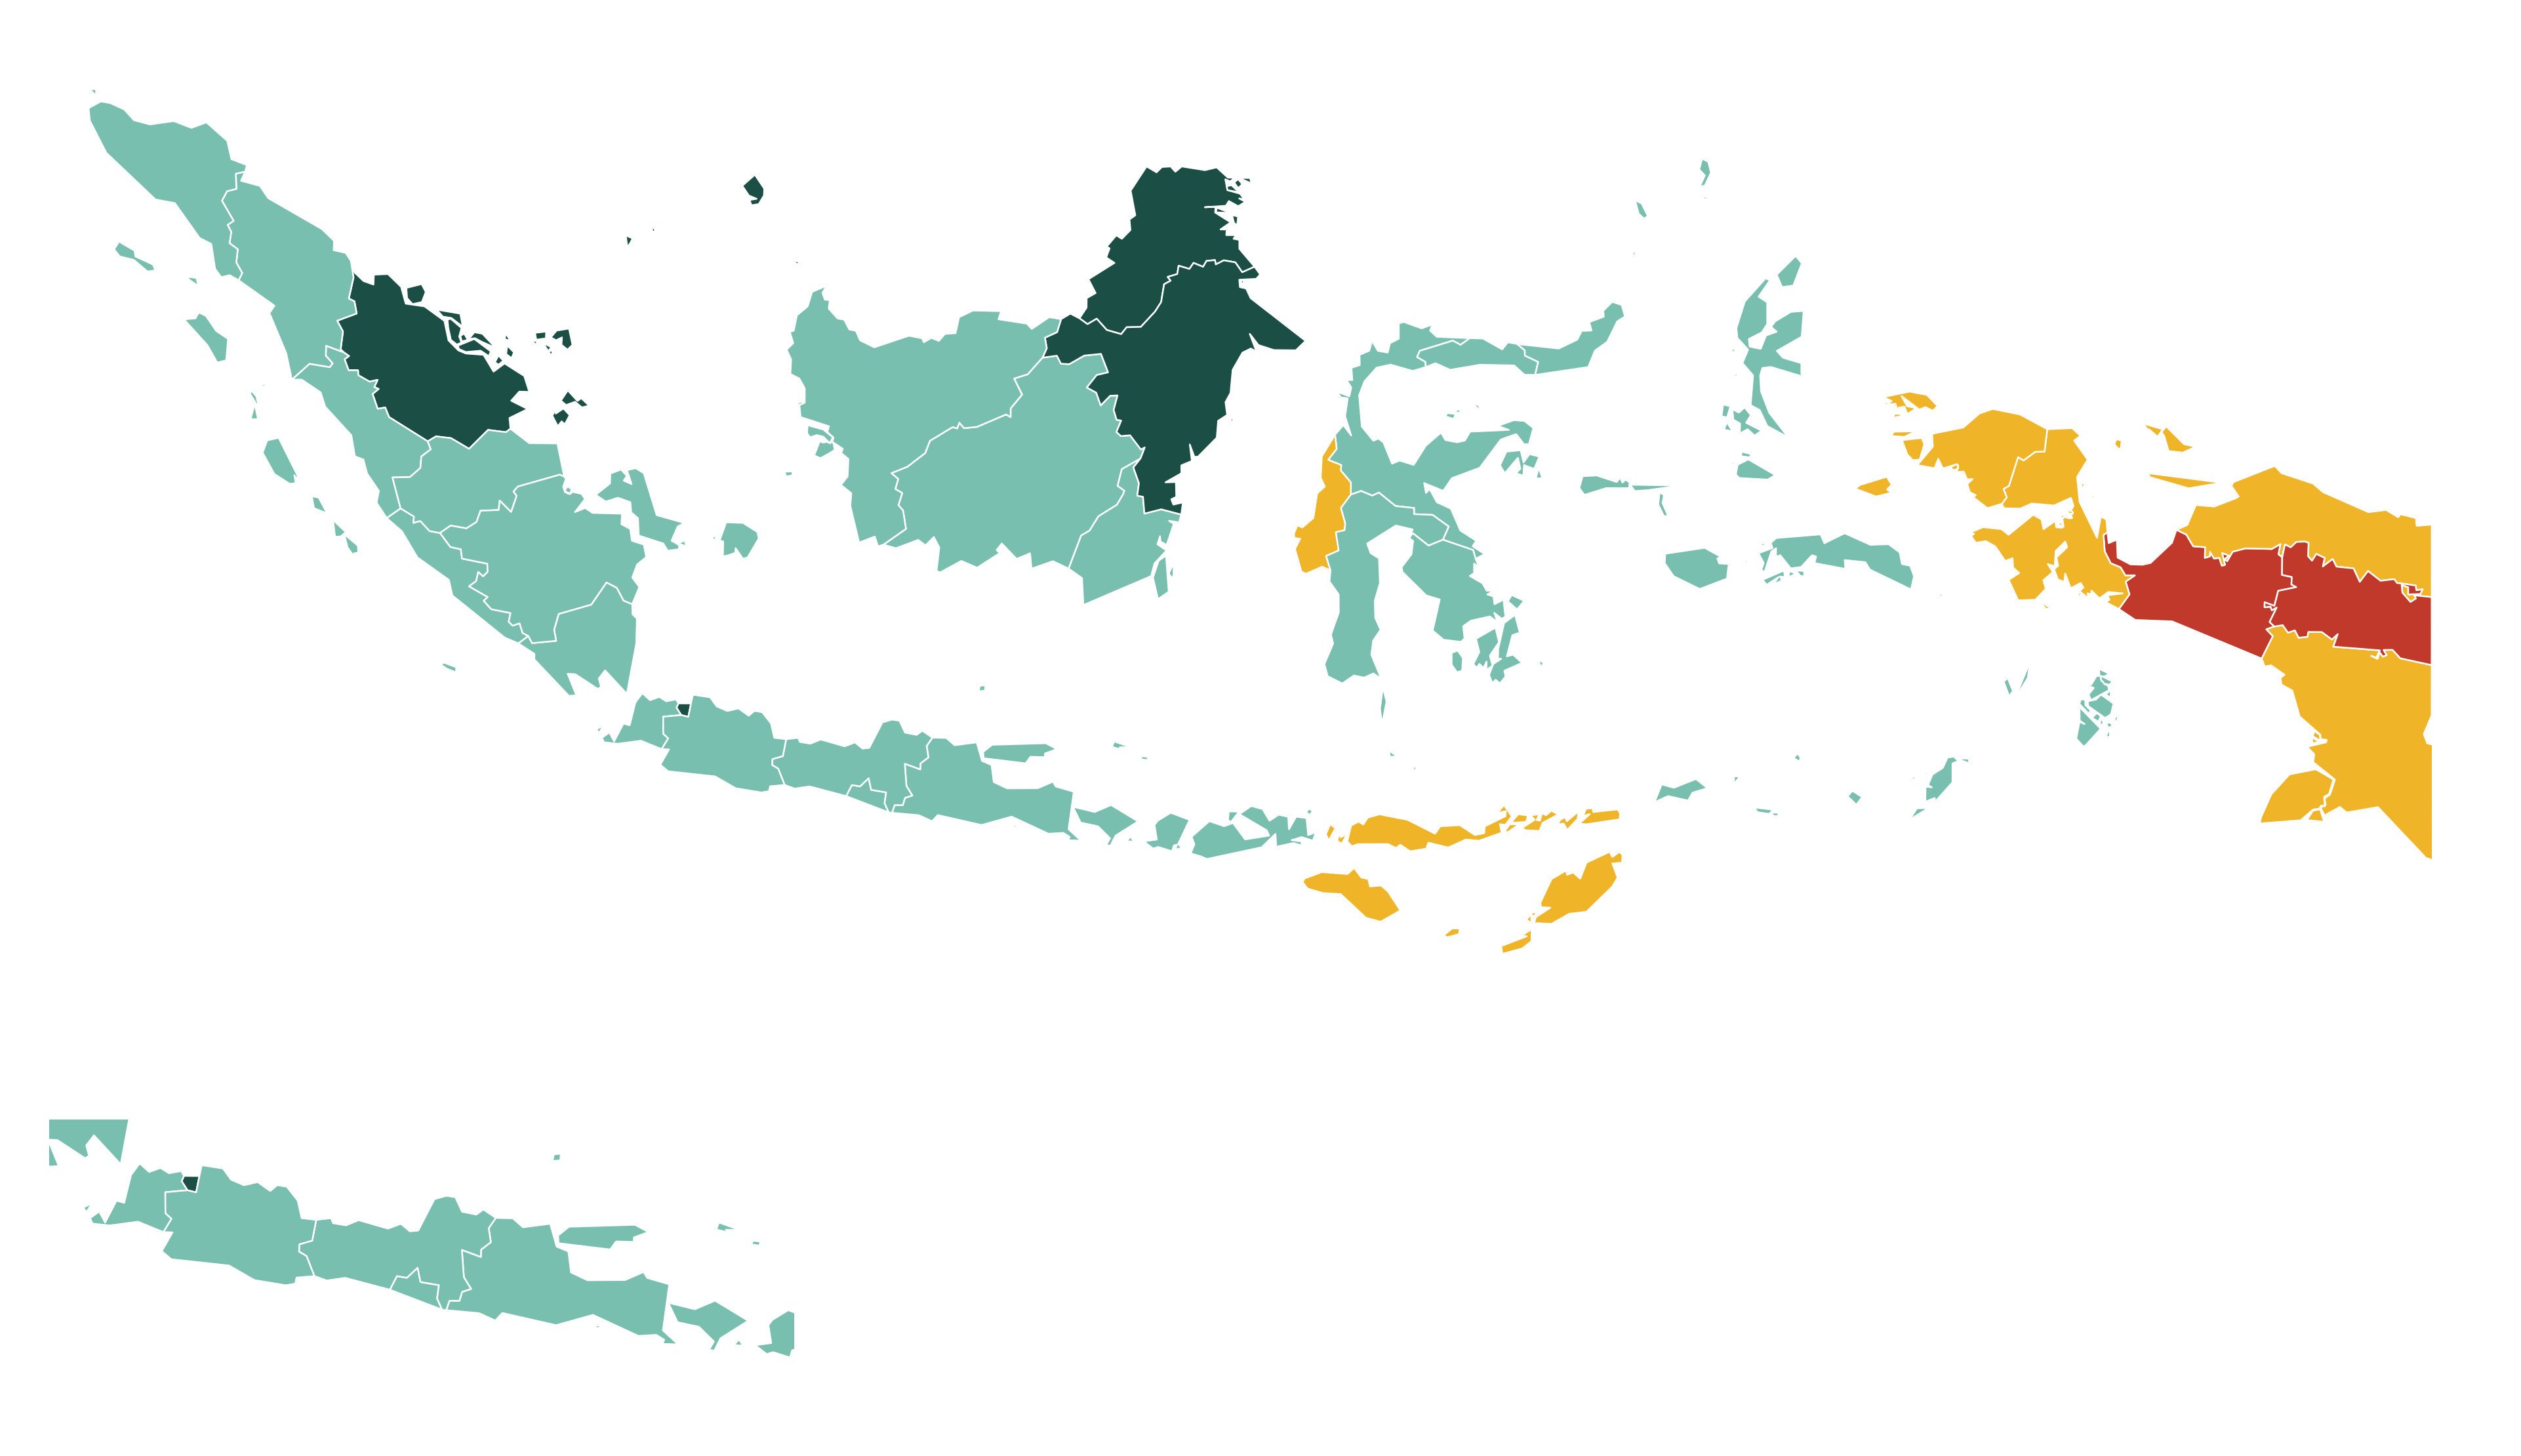

In [37]:
# Varian tanpa garis pembatas — bidang warna menyatu, cocok untuk latar infografis
peta_polos(peta, 'nama_klaster', PALET_KLASTER, '09_klaster_polos_tanpa_garis',
           garis='none', lebar_garis=0)
plt.show()

# Varian dengan sisipan Jawa-Bali, tetap tanpa teks
peta_polos(peta, 'nama_klaster', PALET_KLASTER, '10_klaster_polos_sisipan',
           sisipan_jawa=True)
plt.show()

In [38]:
# Satu berkas SVG per klaster — hanya klaster tersebut yang berwarna, sisanya transparan.
# Berguna untuk animasi bertahap atau penumpukan lapisan di Figma.
def lapisan_klaster(gdf, kolom, palet, awalan='11_lapisan', warna_sisa='none'):
    berkas = []
    for i, nama in enumerate(df['nama_klaster'].dropna().unique(), 1):
        pal = {k: (palet[k] if k == nama else warna_sisa) for k in palet}
        aman = (nama.lower().replace(' ', '_').replace('dan_', '')
                    .replace('&', '').replace('__', '_'))
        nb = f'{awalan}_{i}_{aman}'
        peta_polos(gdf, kolom, pal, nb, warna_kosong='none', simpan_png=False)
        plt.close()
        berkas.append(nb + '.svg')
    return berkas

for f in lapisan_klaster(peta, 'nama_klaster', PALET_KLASTER):
    print('  output_svg/' + f)

  output_svg/11_lapisan_1_berkembang_menengah.svg
  output_svg/11_lapisan_2_maju_terhubung.svg
  output_svg/11_lapisan_3_tertinggal_sedang.svg
  output_svg/11_lapisan_4_tertinggal_ekstrem.svg


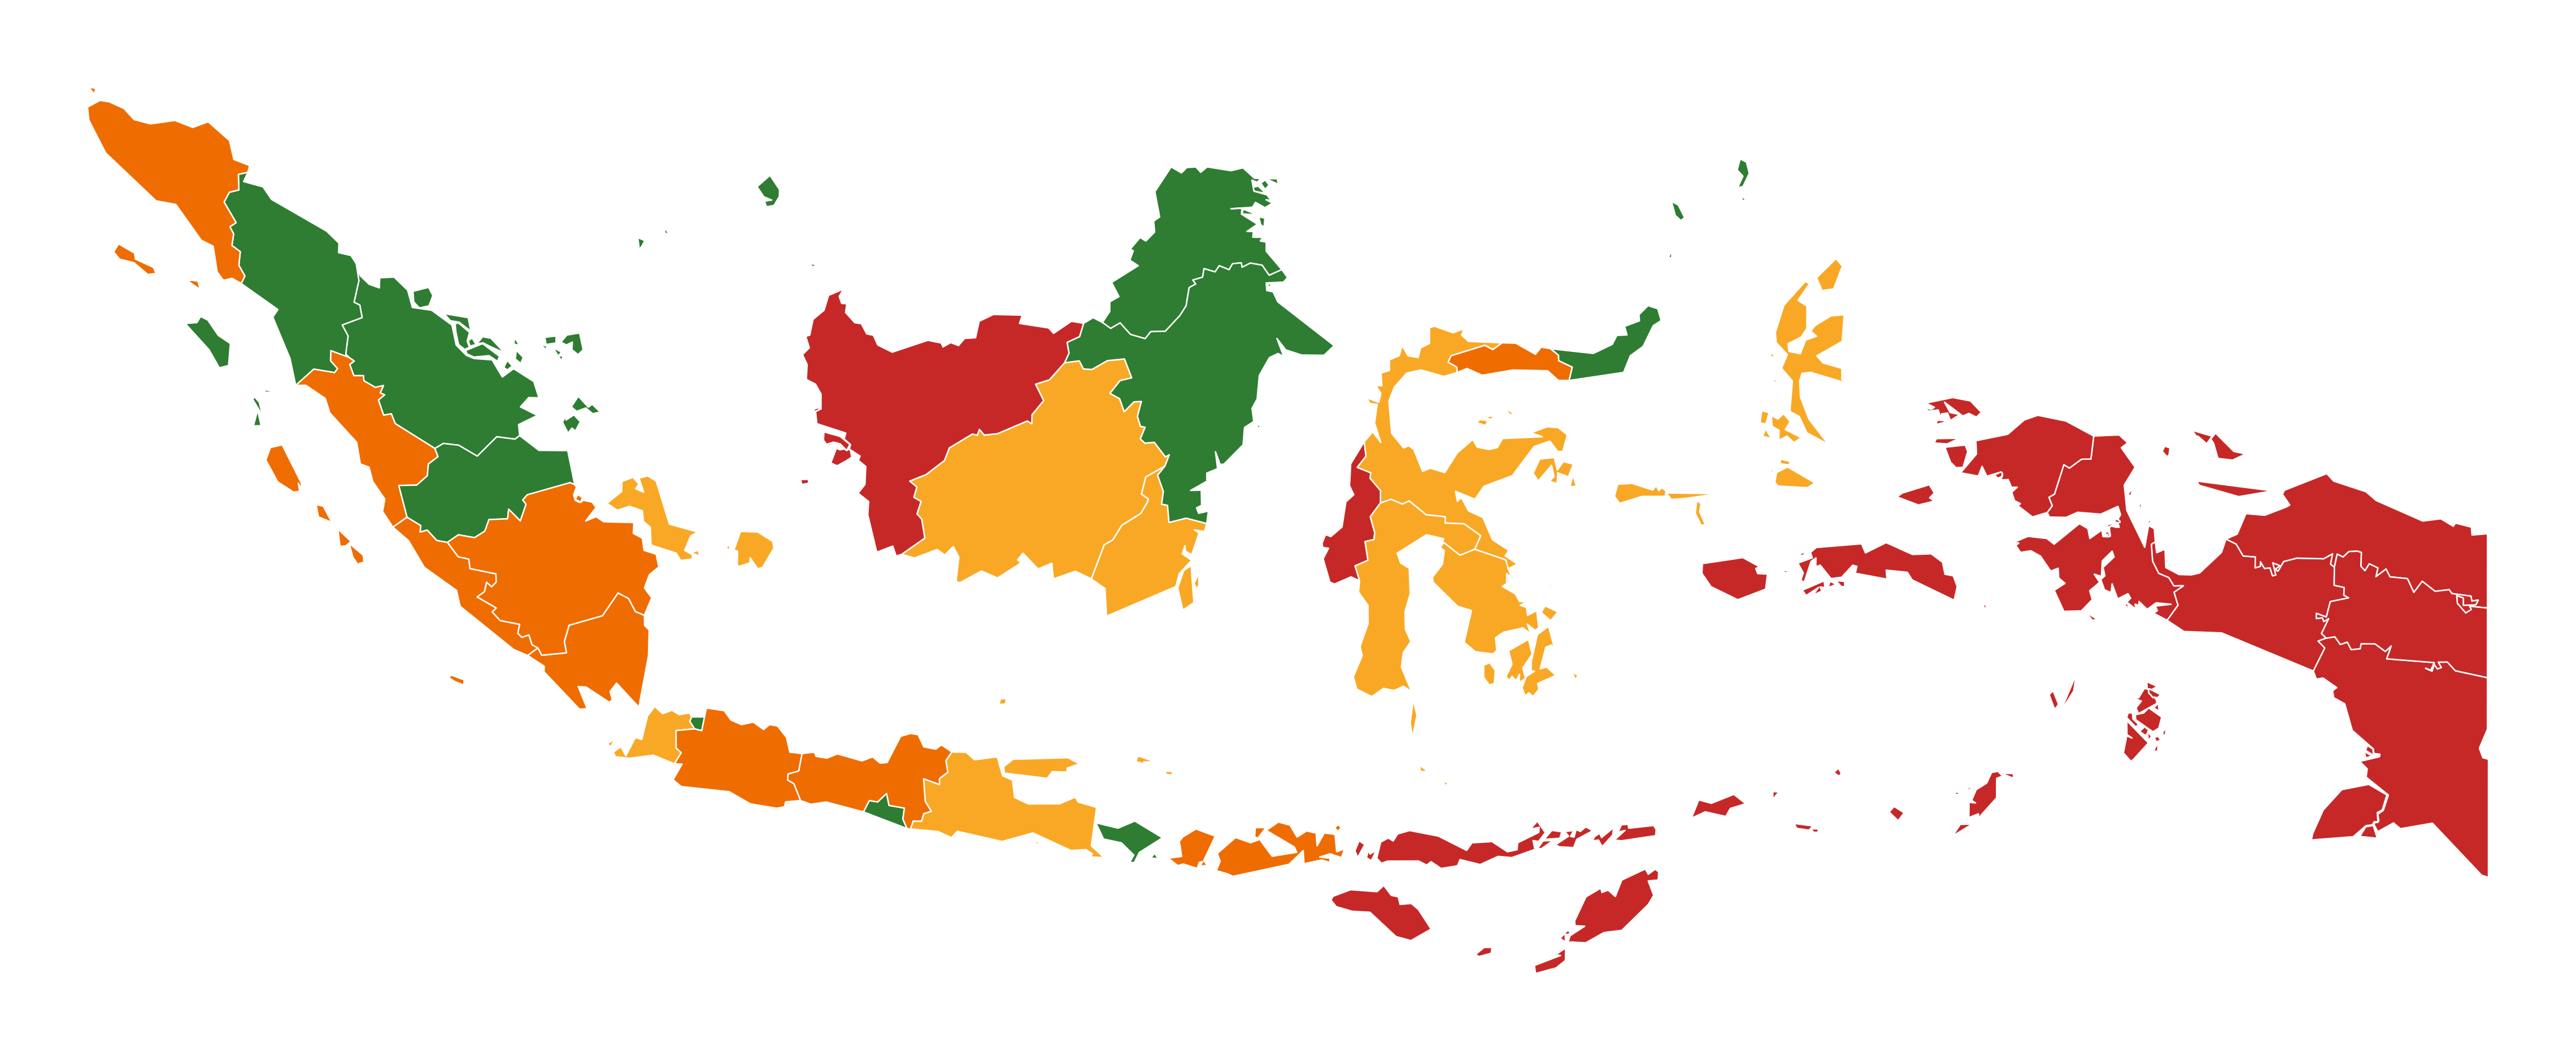

In [39]:
# Peta polos juga bisa dipakai untuk kategori lain, misalnya tingkat kerentanan
PALET_KATEGORI = {'Rendah':'#2E7D32', 'Sedang':'#F9A825',
                  'Tinggi':'#EF6C00', 'Sangat Tinggi':'#C62828'}
peta['kategori_str'] = peta['kategori'].astype(str)
peta_polos(peta, 'kategori_str', PALET_KATEGORI, '12_kategori_kerentanan_polos')
plt.show()

## 11C. Visualisasi Master — Peta Klaster Polos (Satu Chunk Siap Pakai)

Chunk tunggal dan mandiri: hanya bergantung pada `peta` (GeoDataFrame) dan `nama_klaster`
yang sudah dihasilkan di atas. Tidak memanggil fungsi bantu dari bagian lain, sehingga bisa
disalin ke berkas terpisah dan tetap berjalan.

Ubah **hanya** kamus `PALET_MASTER` di baris paling atas untuk mengganti warna tiap klaster.
Kunci kamus adalah nama klaster; nilainya kode heksadesimal apa pun.

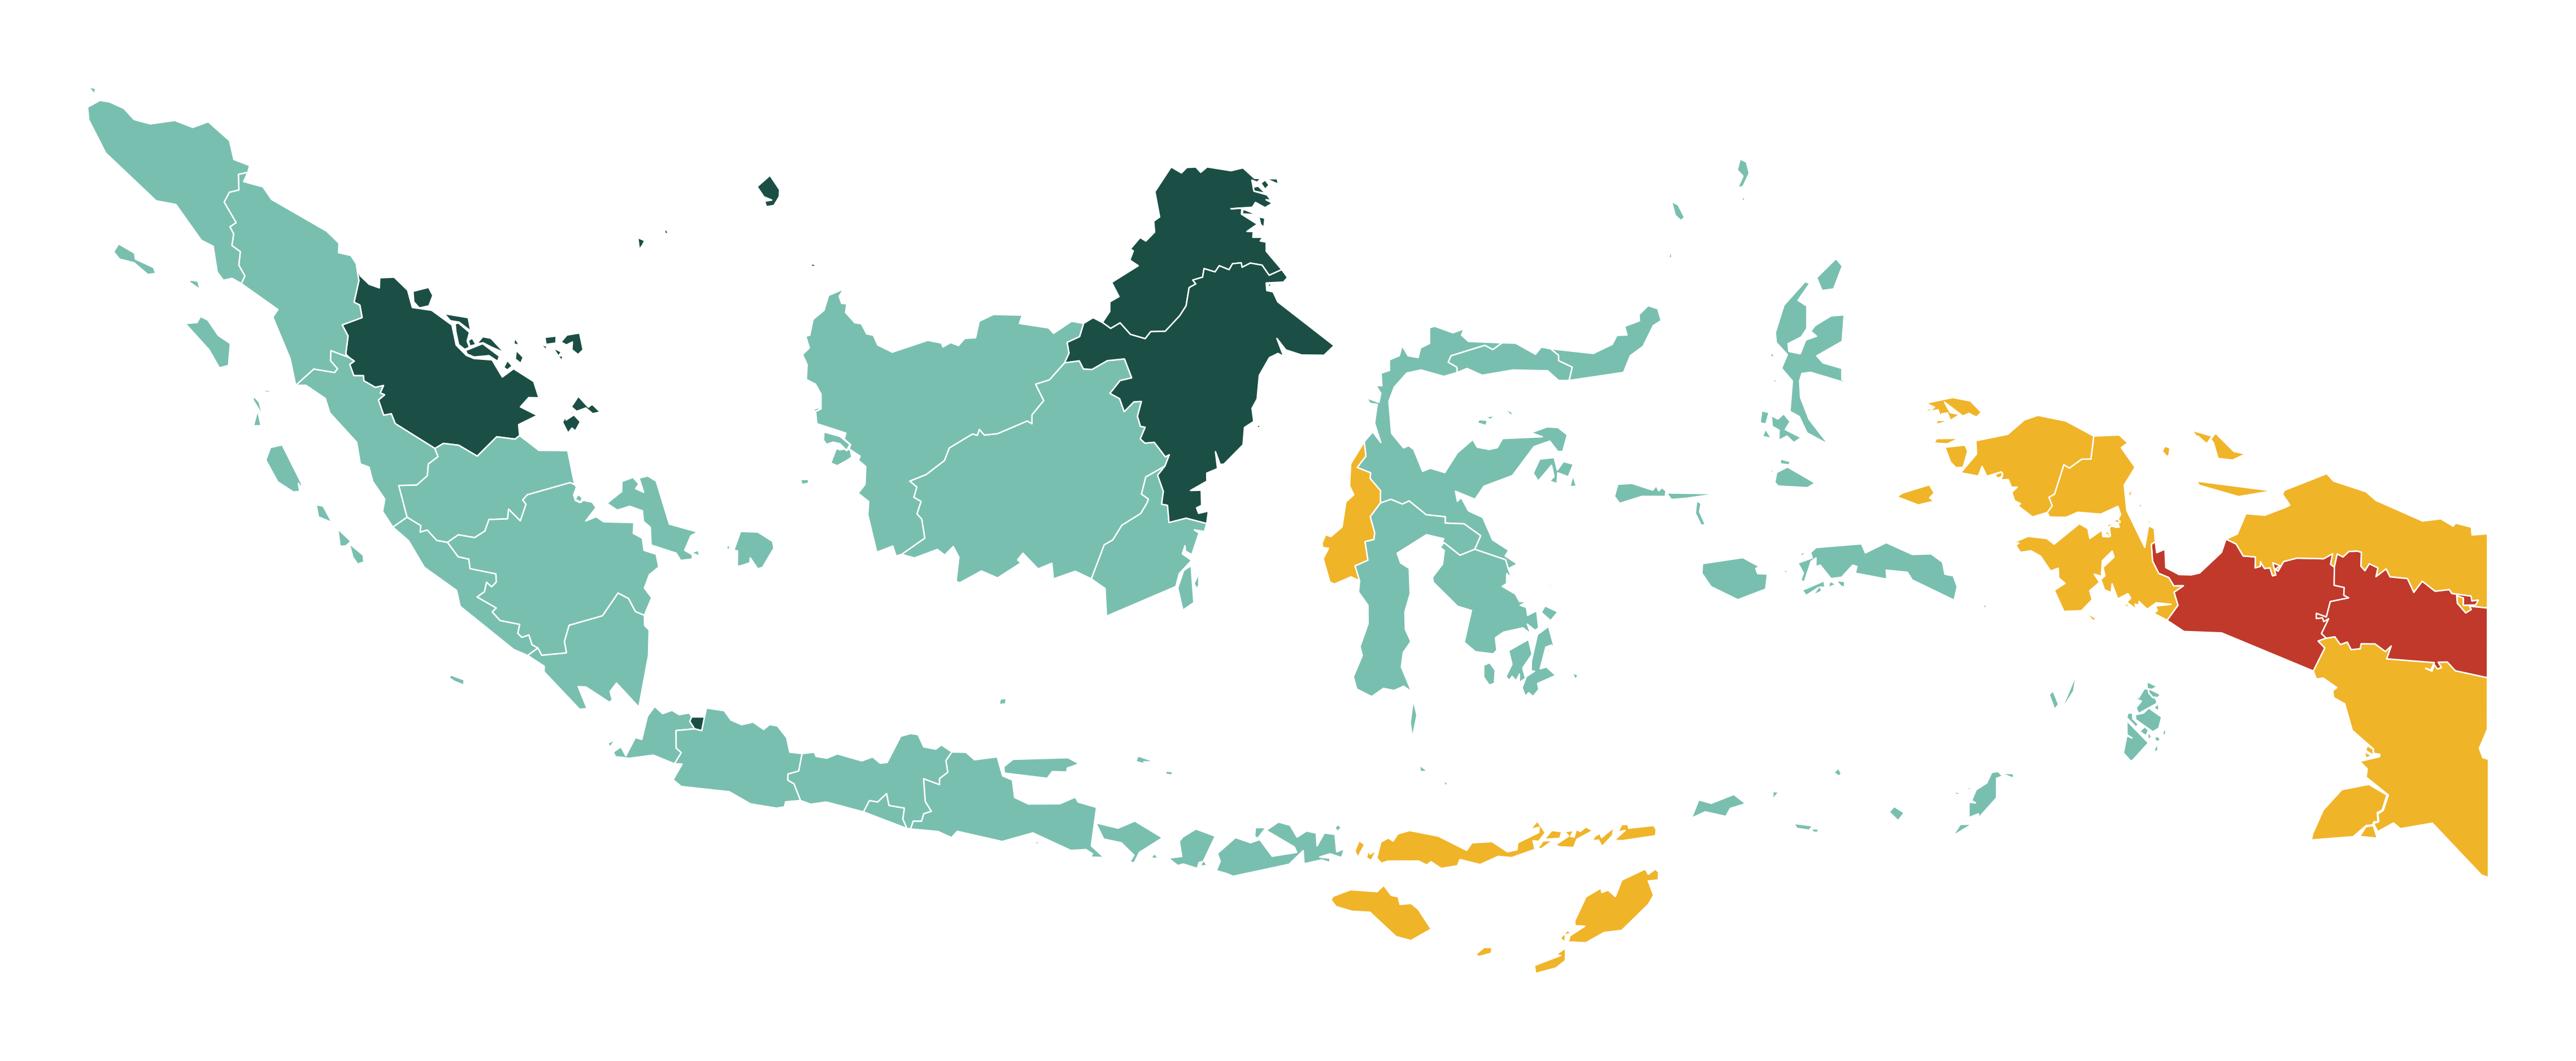

Tersimpan: output_svg/00_visualisasi_master_klaster.svg dan .png

Peta legenda warna (untuk dicocokkan manual di software desain):
  #1B4F45  Maju dan Terhubung  (n=5 provinsi)
  #79BFB0  Berkembang Menengah  (n=25 provinsi)
  #F0B429  Tertinggal Sedang  (n=6 provinsi)
  #C0392B  Tertinggal Ekstrem  (n=2 provinsi)


In [40]:
# ============================================================================
# VISUALISASI MASTER — PETA KLASTER POLOS
# Ubah warna di PALET_MASTER, jalankan chunk ini, selesai.
# ============================================================================

PALET_MASTER = {
    'Maju dan Terhubung' : '#1B4F45',
    'Berkembang Menengah': '#79BFB0',
    'Tertinggal Sedang'  : '#F0B429',
    'Tertinggal Ekstrem' : '#C0392B',
    'Klaster E'          : '#7F8C8D',
    'Klaster F'          : '#8E44AD',
}
WARNA_KOSONG_MASTER = '#E8EAED'   # provinsi tanpa data klaster
GARIS_MASTER        = '#FFFFFF'  # warna garis batas provinsi; 'none' untuk tanpa garis
LEBAR_GARIS_MASTER  = 0.6
LATAR_MASTER        = None        # None = transparan; atau isi kode warna, mis. '#0F172A'
BERKAS_MASTER       = 'output_svg/00_visualisasi_master_klaster'

# --- validasi: pastikan semua klaster yang muncul di data sudah punya warna ---
_klaster_ada = set(peta['nama_klaster'].dropna().unique())
_belum = _klaster_ada - set(PALET_MASTER)
if _belum:
    print('PERINGATAN — klaster berikut belum diberi warna dan akan memakai WARNA_KOSONG_MASTER:')
    print(' ', _belum)

# --- plot ---
_gm = peta.copy()
_gm['_warna_master'] = _gm['nama_klaster'].map(PALET_MASTER).fillna(WARNA_KOSONG_MASTER)

_fig = plt.figure(figsize=(15, 7.2))
if LATAR_MASTER:
    _fig.patch.set_facecolor(LATAR_MASTER)
else:
    _fig.patch.set_alpha(0.0)
_ax = _fig.add_axes([0, 0, 1, 1])
_ax.patch.set_alpha(0.0)

_gm.plot(ax=_ax, color=_gm['_warna_master'], edgecolor=GARIS_MASTER, linewidth=LEBAR_GARIS_MASTER)
_ax.set_axis_off()
_b = _gm.total_bounds
_ax.set_xlim(_b[0] - 1.5e5, _b[2] + 1.5e5)
_ax.set_ylim(_b[1] - 1.5e5, _b[3] + 1.5e5)

_fig.savefig(f'{BERKAS_MASTER}.svg', format='svg', bbox_inches='tight', pad_inches=0,
             transparent=(LATAR_MASTER is None),
             facecolor=_fig.get_facecolor() if LATAR_MASTER else 'none')
_fig.savefig(f'{BERKAS_MASTER}.png', dpi=300, bbox_inches='tight', pad_inches=0,
             transparent=(LATAR_MASTER is None))
plt.show()

print(f'Tersimpan: {BERKAS_MASTER}.svg dan .png')
print('\nPeta legenda warna (untuk dicocokkan manual di software desain):')
for _nama, _kode in PALET_MASTER.items():
    if _nama in _klaster_ada:
        print(f'  {_kode}  {_nama}  (n={int((peta.nama_klaster==_nama).sum())} provinsi)')

## 12. Ekspor

In [41]:
kolom = (['Provinsi'] + FEATURES + ['klaster','nama_klaster','indeks_kerentanan','peringkat',
          'kategori','lisa_q','lisa_p','lisa','lat','lon'] + ['gwr_'+c for c in XN])
df[kolom].to_csv('hasil_analisis_jala.csv', index=False)
moran_tabel.to_csv('hasil_moran.csv', index=False)
banding.to_csv('hasil_perbandingan_model.csv', index=False)
grid.head(30).to_csv('hasil_grid_klaster.csv', index=False)

print('Berkas tersimpan:')
for f in sorted(os.listdir('output_svg')):
    print('  output_svg/' + f)
for f in ['hasil_analisis_jala.csv','hasil_moran.csv','hasil_perbandingan_model.csv',
          'hasil_grid_klaster.csv']:
    print('  ' + f)

Berkas tersimpan:
  output_svg/00_visualisasi_master_klaster.png
  output_svg/00_visualisasi_master_klaster.svg
  output_svg/01_sebaran_klaster.svg
  output_svg/02_moran_scatterplot.svg
  output_svg/03_peta_kepemilikan_ponsel.png
  output_svg/03_peta_kepemilikan_ponsel.svg
  output_svg/04_peta_indeks_kerentanan.png
  output_svg/04_peta_indeks_kerentanan.svg
  output_svg/05_peta_klaster.png
  output_svg/05_peta_klaster.svg
  output_svg/06_peta_lisa.png
  output_svg/06_peta_lisa.svg
  output_svg/07_peta_gwr_koefisien.png
  output_svg/07_peta_gwr_koefisien.svg
  output_svg/08_klaster_polos.png
  output_svg/08_klaster_polos.svg
  output_svg/09_klaster_polos_tanpa_garis.png
  output_svg/09_klaster_polos_tanpa_garis.svg
  output_svg/10_klaster_polos_sisipan.png
  output_svg/10_klaster_polos_sisipan.svg
  output_svg/11_lapisan_1_berkembang_menengah.svg
  output_svg/11_lapisan_2_maju_terhubung.svg
  output_svg/11_lapisan_3_tertinggal_sedang.svg
  output_svg/11_lapisan_4_tertinggal_ekstrem.svg


## 13. Ringkasan untuk Naskah Infografis

In [42]:
# Ringkasan dibangun otomatis dari variabel yang sudah dihitung di atas —
# tinggal disalin ke naskah, tidak perlu diisi manual.

print('1) KONFIGURASI KLASTER TERPILIH')
print(f'   {SKEMA_PILIH} | ruang {RUANG_PILIH} | algoritma {ALGO_PILIH} | k={K_OPT}')
print(f'   silhouette={juara.silhouette:.3f}  davies_bouldin={juara.davies_bouldin:.3f}  '
      f'calinski={juara.calinski:.1f}')
if len(dasar):
    _baseline = dasar.iloc[0]
    print(f'   Perbaikan silhouette vs konfigurasi awam (log+Standard|PCA2|KMeans|k=4): '
          f'{(juara.silhouette/_baseline.silhouette-1)*100:+.1f}%')
print(f'   Stabilitas bootstrap (ARI, {N_BOOT}x): {ari.mean():.3f} +/- {ari.std():.3f}')

print('\n2) PROVINSI PALING RENTAN (indeks komposit)')
top5 = df.sort_values('peringkat').head(5)
for _, r in top5.iterrows():
    pemicu = norm.loc[r.name, FEATURES].mul(BOBOT).sort_values(ascending=False).index[0]
    print(f'   #{r.peringkat:>2d}  {r.Provinsi:<22s} indeks={r.indeks_kerentanan:.3f}  '
          f'klaster: {r.nama_klaster}  pemicu utama: {LABEL[pemicu]}')

print(f"\n3) MORAN'S I — {LABEL[Y_COL]}")
print(f"   I={mi_y.I:.4f}  z={mi_y.z_sim:.3f}  p={mi_y.p_sim:.4f}  "
      f"({'signifikan, mengelompok secara spasial' if mi_y.p_sim<.05 and mi_y.I>mi_y.EI else 'tidak signifikan'})")
print('   -> ' + ('Kerentanan/kepemilikan mengelompok wilayah, sehingga intervensi berbasis '
      'kawasan lebih efisien daripada program yang disebar merata.' if mi_y.p_sim<.05
      else 'Tidak ditemukan pengelompokan spasial yang signifikan pada taraf 5%.'))

print('\n4) KANTONG LISA')
for kat in ['High-High','Low-Low','Low-High','High-Low']:
    a = df.loc[df.lisa==kat,'Provinsi'].tolist()
    print(f'   {kat:12s} (n={len(a):>2d}): ' + (', '.join(a) if a else '-'))

print('\n5) MODEL SPASIAL TERBAIK (AICc)')
print(f'   Model terpilih: {terbaik}')
display(banding.set_index('Model'))
if terbaik in ('SEM',):
    print('   Koefisien signifikan (p<0.05) pada model SEM — lihat ringkasan lengkap Bagian 10.')

print('\n6) KETAHANAN BOBOT INDEKS (Spearman antarskenario)')
print(f'   Rata-rata korelasi peringkat antarskenario bobot: '
      f'{kor.values[np.triu_indices_from(kor,1)].mean():.4f} '
      f'({"hasil tergolong tidak rapuh terhadap pilihan bobot" if kor.values[np.triu_indices_from(kor,1)].mean() > 0.8 else "peka terhadap pilihan bobot, perlu kehati-hatian"})')

print('\nKETERBATASAN YANG PERLU DINYATAKAN TERBUKA')
print('  - RLS adalah komponen penyusun IPM sehingga keduanya berkorelasi struktural;')
print('    ditangani lewat VIF dan model pembanding tanpa IPM (Bagian 2 dan 10).')
print('  - Data lintas-seksi satu titik waktu tidak dapat menyimpulkan hubungan sebab-akibat.')
print('  - Dengan 38 unit, model dengan banyak parameter (SDM, GWR) rawan overfitting;')
print('    AICc dipakai justru untuk menghukum hal itu.')
print('  - Sentroid dihitung dari poligon; provinsi kepulauan memiliki sentroid yang')
print('    tidak selalu mewakili pusat penduduk.')

1) KONFIGURASI KLASTER TERPILIH
   Robust | ruang PCA2 | algoritma Ward | k=4
   silhouette=0.530  davies_bouldin=0.611  calinski=47.5
   Perbaikan silhouette vs konfigurasi awam (log+Standard|PCA2|KMeans|k=4): +32.2%
   Stabilitas bootstrap (ARI, 300x): 0.961 +/- 0.082

2) PROVINSI PALING RENTAN (indeks komposit)
   # 1  Papua Pegunungan       indeks=0.936  klaster: Tertinggal Ekstrem  pemicu utama: Kepemilikan Ponsel (%)
   # 2  Papua Tengah           indeks=0.670  klaster: Tertinggal Ekstrem  pemicu utama: IPM
   # 3  Papua Selatan          indeks=0.614  klaster: Tertinggal Sedang  pemicu utama: IPM
   # 4  Papua                  indeks=0.589  klaster: Tertinggal Sedang  pemicu utama: IPM
   # 5  Nusa Tenggara Timur    indeks=0.576  klaster: Tertinggal Sedang  pemicu utama: PDRB per Kapita (ribu Rp)

3) MORAN'S I — Kepemilikan Ponsel (%)
   I=0.4501  z=6.940  p=0.0010  (signifikan, mengelompok secara spasial)
   -> Kerentanan/kepemilikan mengelompok wilayah, sehingga intervensi berb

,AIC,AICc,R2/pseudo-R2
Model,,,
OLS,222.182,224.057,0.905
SLX,214.901,221.329,0.936
SAR,223.505,226.214,0.907
SEM,221.137,223.847,0.904
SDM,214.962,223.110,0.942
GWR,NaN,208.027,0.957



6) KETAHANAN BOBOT INDEKS (Spearman antarskenario)
   Rata-rata korelasi peringkat antarskenario bobot: 0.9478 (hasil tergolong tidak rapuh terhadap pilihan bobot)

KETERBATASAN YANG PERLU DINYATAKAN TERBUKA
  - RLS adalah komponen penyusun IPM sehingga keduanya berkorelasi struktural;
    ditangani lewat VIF dan model pembanding tanpa IPM (Bagian 2 dan 10).
  - Data lintas-seksi satu titik waktu tidak dapat menyimpulkan hubungan sebab-akibat.
  - Dengan 38 unit, model dengan banyak parameter (SDM, GWR) rawan overfitting;
    AICc dipakai justru untuk menghukum hal itu.
  - Sentroid dihitung dari poligon; provinsi kepulauan memiliki sentroid yang
    tidak selalu mewakili pusat penduduk.
